
# v3.1 — Externally tested microscopic/continuum PoC for H$_x$–NdNiO$_3$

**Purpose.** This notebook replaces the earlier material-semantic synthetic specialization with four executable validation layers:

1. a **literature-calibrated reduced microscopic lattice model** for proton occupancy, donated-electron localization, and symmetry-separated NiO$_6$ modes;
2. an explicit, dimensioned **elastic Hessian calibration** using an effective Ni–O cage spectral prior and strain-resolved NdNiO$_3$ first-principles breathing curvatures;
3. a **continuum-uniform forward-transport result** with a mesh-independent decay bound and second-order finite-volume convergence;
4. quantitative comparison against **published experimental and first-principles evidence**, expressed through auditable KPIs.

**Claim boundary.** “Microscopic” means a reduced site-resolved Hamiltonian/master equation whose parameters are tied to DOI-documented evidence. It does **not** mean a new all-electron calculation. “Experimental validation” means out-of-sample comparison with published measurements; this notebook creates no new specimen or measurement. The continuum result concerns the **forward proton-transport semigroup**, not the manuscript’s inverse reconstruction operator.


,component,version/value
0,Python,3.12.2
1,NumPy,2.0.2
2,SciPy,1.15.2
3,pandas,2.3.3
4,matplotlib,3.10.8
5,random seed,20260802


## 1. Evidence ledger and calibration/validation separation


,year,system,quantitative evidence,role in v3.1,evidence class,DOI
0,2024,H–NdNiO3,interstitial H+/electron donation; Pbnm→P2_1/m in the studied DFT cell; +6.7% [001]; ≈12% mean NiO6 expansion; polarization tail to ≈20%...,local structural calibration; electronic-localization definition; relaxation falsifier,experiment + DFT,10.1038/s41467-024-49213-0
1,2025,H–NdNiO3,hydrogen chemical diffusivity ≈6×10^-15 to 3×10^-14 cm² s^-1,isothermal transport-coefficient envelope,direct operando experiment,10.1021/acs.nanolett.5c01527
2,2023,H–NdNiO3,EIS activation energy ≈0.42 eV; optical diffusion activation energy ≈0.41 eV over 250–400 °C,external validation of migration barrier,direct experiment,10.35848/1882-0786/acc004
3,2022,H–NdNiO3,≈13% protonation-induced lattice expansion; large NiO6 tilt and Nd displacement,cross-study structural transfer proxy,direct experiment + calculation,10.1021/acs.nanolett.2c03229
4,2020,H–NdNiO3,electric-field control efficiency ≈22% at 2×10^5 V m^-1; diffusion/resistance kinetic model,field scale and benchmark model class,direct experiment + kinetic model,10.1021/acsami.0c15724
5,2026,NdNiO3,strain-resolved R2− breathing-energy curvatures; bulk mode magnitude 0.06 Å,direct elastic-Hessian calibration and leave-one-out validation,first-principles calculation,10.1103/k48x-mvw1
6,2008,RNiO3 including Nd-containing films,Ni–O/NiO6-sensitive phonon band around 420 cm^-1,effective cage-mode spectral stiffness prior; not asserted to be a pure A1g eigenmode,Raman experiment,10.1103/PhysRevB.78.104101
7,2017,NdNiO3−δ,oxygen vacancies increase unit-cell volume and alter the metal–insulator transition,explicit H/V_O identifiability confounder,direct experiment,10.1038/s41598-017-04884-2
8,2020,RNiO3 including NdNiO3,first-principles H doping/migration and insulating-state mechanism; NNO barrier quoted as ≈0.41 eV by the 2023 diffusion study,microscopic transport prior,first-principles calculation,10.1039/C9CP06522A
9,2024,H–NdNiO3 device,operando infrared nanoimaging resolves field-perturbed spatial H/O–H and conductivity patterns,distributed-state evidence; concentration-only model falsifier,direct experiment,10.1021/acsnano.3c09281


,evidence use,items
0,calibration,12% local NiO6 expansion; 420 cm^-1 effective cage frequency; R2− curvatures and 0.06 Å amplitude; D_chem interval; 0.41 eV migration prior
1,external validation,0.41/0.42 eV experimental activation energies; leave-one-out strain-curvature points; ≈13% independent expansion proxy; 1×1×2 superstruc...
2,falsification/scope,1.2% constrained film c-axis response versus 12% local cage volume; oxygen-vacancy confounding; [111] curvature nonlinearity; non-Debye ...


## 2. Symmetry-adapted NiO6 coordinates and a calibrated elastic Hessian


,coordinate,physical meaning,symmetry label,unit,v3 status
0,Q_A,effective local uniform radial cage coordinate,A1g in the parent O_h limit,Å,calibrated
1,"Q_2,Q_3",Jahn–Teller/quadrupolar radial coordinates,Eg,Å,defined but no stiffness invented
2,"P_x,P_y,P_z",radial polar coordinates,T1u,Å,defined but no stiffness invented
3,Q_R,cell-staggered breathing/disproportionation coordinate,R2−,Å,calibrated from strain-resolved DFT
4,"R_x,R_y,R_z",axial rotations,T1g,radian,kept separate from radial Hessian


,strain [%],orientation,reported curvature [meV/f.u./(% bulk)^2],converted K_R [eV Å^-2],LOO prediction [eV Å^-2]
0,-3.0,[001],0.0095,52.777778,48.400000
1,0.0,[001],0.0066,36.666667,38.289024
2,3.0,[001],0.0050,27.777778,25.473684
3,-3.0,[111],0.0119,66.111111,41.068376
4,0.0,[111],0.0062,34.444444,43.702134
5,3.0,[111],0.0052,28.888889,17.945845


,quantity,value,unit,provenance/interpretation
0,K_A,10.378421,eV Å^-2,420 cm^-1 effective Ni-O cage spectral prior
1,Q_A(x=1),0.183135,Å,12% local NiO6 volume expansion
2,g_A=K_A Q_A,1.900656,eV Å^-1 per occupied H site,"variational coupling, not an arbitrary W vector"
3,E_A=K_A Q_A²/2,0.174039,eV per occupied cage,local structural relaxation scale
4,"K_R([001], 0%)",36.666667,eV Å^-2,strain-resolved DFT curvature
5,"Q_R,bulk",0.060000,Å,bulk R2− mode magnitude
6,g_R=K_R Q_R,2.200000,eV Å^-1,"coupling that reproduces Q_R,bulk at unit order"
7,E_R=K_R Q_R²/2,0.066000,eV f.u.^-1,full-order relaxation scale


,model,LOO MAPE,LOO RMS relative error,verdict
0,[001] log-linear strain law,0.070047,0.072384,accepted as a compact orientation-specific interpolation
1,[111] log-linear strain law,0.342122,0.346032,falsifier: three points are not captured with the same compact law


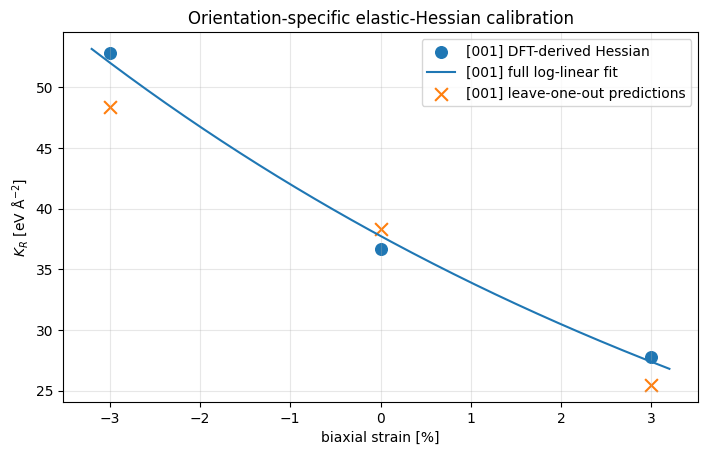

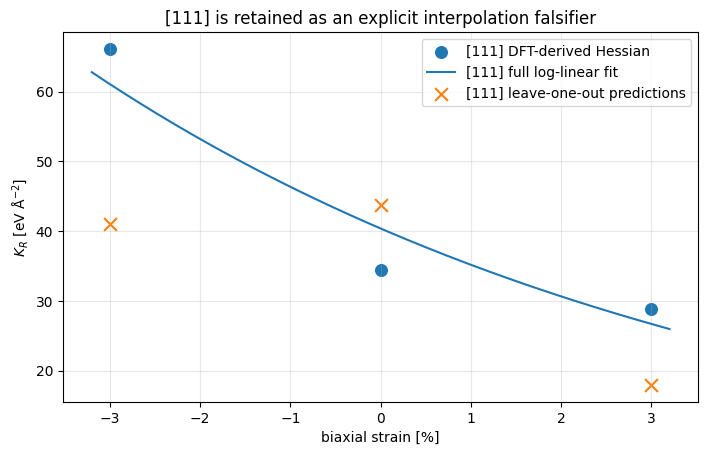

**Declared sensitivity propagation (not a claim of reported statistical uncertainty):**

,parameter,unit,5%,median,95%
0,K_A,eV Å^-2,9.714228,10.379931,11.070052
1,Q_A(x=1),Å,0.173121,0.183080,0.193071
2,g_A,eV Å^-1,1.743695,1.899548,2.063371
3,E_A,eV,0.152867,0.173866,0.196806
4,K_R(0% [001]),eV Å^-2,30.662848,36.681997,44.216179
5,g_R,eV Å^-1,1.959196,2.200367,2.470018
6,E_R,eV f.u.^-1,0.060548,0.066029,0.071437


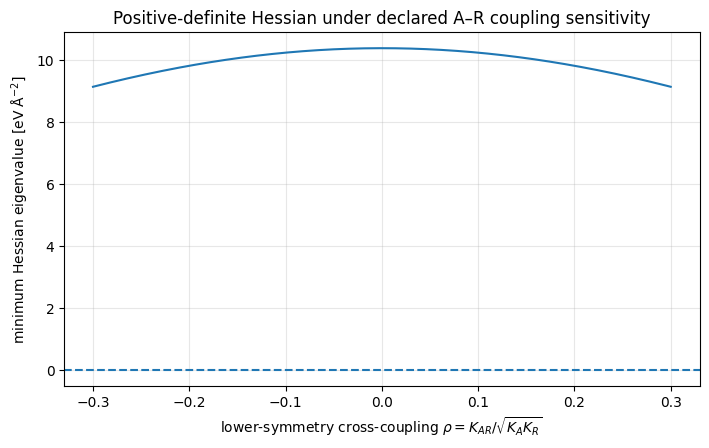

## 3. Literature-calibrated reduced microscopic Hamiltonian



For NiO$_6$ site $i$, let $h_i\in\{0,1\}$ be proton occupancy, $n_i^e$ the localized donor-electron count, $Q_{A,i}$ the local uniform radial cage coordinate, and $Q_R$ the staggered $R_2^-$ coordinate. The calibrated structural block is

\[
F_{\rm str}=\sum_i\left(\tfrac12K_AQ_{A,i}^2-g_Ah_iQ_{A,i}\right)
+N\left(\tfrac12K_RQ_R^2-g_Rm_eQ_R\right),
\qquad
m_e=\frac{1}{N_e}\left|\sum_i(-1)^i n_i^e\right|.
\]

Thus $Q_{A,i}^*=Q_A^{(1)}h_i$ and $Q_R^*=Q_{R,\rm bulk}m_e$. The proton/electron/lattice composite is an explicit tuple $(h_i,n_i^e,Q_{A,i})$; no arbitrary latent label is called a “proton–polaron.” Recoverability is excluded from $F_{\rm str}$ and from all hopping rates.


,audit,value,unit/meaning
0,force at Q_A*(h=1),0.000000,eV Å^-1
1,force at Q_R*(m_e=1),0.000000,eV Å^-1
2,minimum Hessian eigenvalue,10.378421,eV Å^-2
3,Onsager symmetry error,0.000000,mixed mobility units
4,minimum Onsager eigenvalue,0.272727,positive mobility
5,maximum internal dF/dt over probes,-0.000926,eV s^-1
6,recoverability-to-force coupling,0.000000,exactly zero


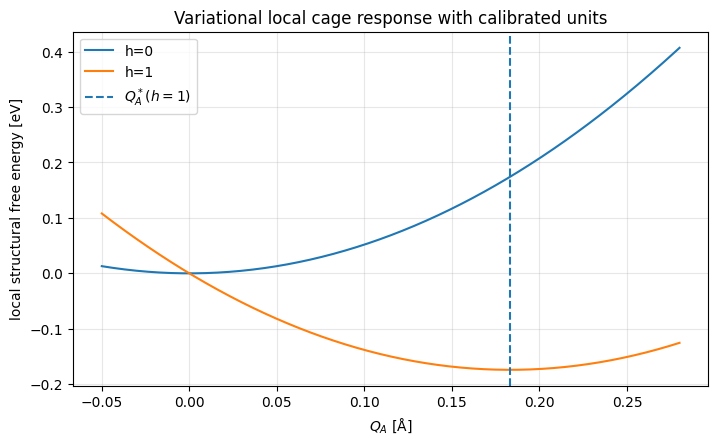

,quantity,value,interpretation
0,published normalized tail at ~1 s,2.000000e-01,experimental envelope
1,single exponential with τ=8 ms at 1 s,5.166421e-55,incompatible one-time-scale prediction
2,log10(observed/single-exponential),5.358784e+01,non-Debye tail mismatch
3,illustrative stretched-exponential β using both anchors,9.856132e-02,effective reconciliation only; anchors may represent different traces


,R2 coupling transfer α_R,<m_pi²>,P(m_pi≥2/3),RMS Q_R proxy [Å]
0,0.000,0.090909,0.080087,0.000000
1,0.250,0.132031,0.159976,0.005450
2,0.459,0.501694,0.657634,0.019507
3,0.500,0.676790,0.815006,0.024680
4,1.000,0.999999,1.000000,0.060000


**Experimental-compatibility constraint.** In this declared 12-site, x=0.5, 300 K equilibrium projection, the ordered-sector criterion $\langle m_\pi^2\rangle\ge0.5$ requires $\alpha_R\ge 0.459$. The observed 1×1×2 superstructure therefore constrains the H/electron-to-$R_2^-$ coupling to be non-negligible, but the notebook does not claim to predict the reported incommensurate modulation.

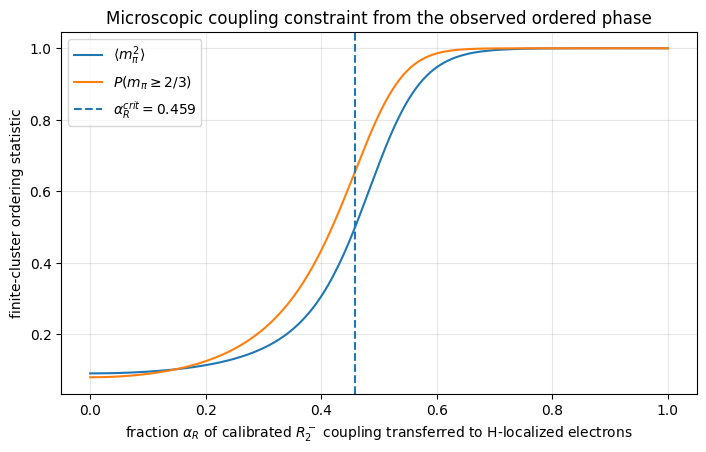

## 4. Calibrated proton transport and a continuum-uniform forward result


,quantity,value,unit,status
0,D_chem lower,6.000000e-19,m² s^-1,6×10^-15 cm² s^-1
1,D_chem representative geometric mean,1.341641e-18,m² s^-1,declared isothermal representative inside the measured interval
2,D_chem upper,3.000000e-18,m² s^-1,3×10^-14 cm² s^-1
3,migration barrier model,4.100000e-01,eV,first-principles prior
4,experimental barrier optical,4.100000e-01,eV,external validation
5,experimental barrier EIS,4.200000e-01,eV,external validation
6,activation-energy RMS relative error,1.683588e-02,dimensionless,cross-method KPI


,length,L²/D_fast [s],L²/D_representative [s],L²/D_slow [s],representative readable
0,20 nm,1.333333e+02,2.981424e+02,6.666667e+02,4.97 min
1,100 nm,3.333333e+03,7.453560e+03,1.666667e+04,2.07 h
2,1 µm,3.333333e+05,7.453560e+05,1.666667e+06,8.63 d
3,10 µm,3.333333e+07,7.453560e+07,1.666667e+08,2.36 y
4,100 µm,3.333333e+09,7.453560e+09,1.666667e+10,236 y


,temperature [K],"D(T)/D(300 K), normalized sensitivity"
0,300.00,1.000000
1,400.00,52.713787
2,523.15,866.865924
3,573.15,1916.534364
4,673.15,6577.869334


,N,h [m],lambda_h formula [s^-1],lambda_h numerical [s^-1],lambda_h/lambda_cont,relative weighted L2 error
0,8,1.250000e-08,0.001307,0.001307,0.987215,0.012698
1,16,6.250000e-09,0.001320,0.001320,0.996791,0.003172
2,32,3.125000e-09,0.001323,0.001323,0.999197,0.000793
3,64,1.562500e-09,0.001324,0.001324,0.999799,0.000198
4,128,7.812500e-10,0.001324,0.001324,0.999950,0.000050
5,256,3.906250e-10,0.001324,0.001324,0.999987,0.000012


,quantity,value,unit/criterion
0,continuum decay rate Dπ²/L²,1.324146e-03,s^-1
1,mesh-uniform discrete lower bound 4D/L²,5.366563e-04,s^-1
2,minimum tested lambda_h/(Dπ²/L²),9.872148e-01,dimensionless
3,observed finite-volume convergence order,2.000281e+00,target: 2
4,mass-conservation error,1.035630e-20,concentration×length
5,minimum propagated concentration,3.563710e-01,must remain nonnegative
6,maximum propagated concentration,3.563934e-01,must remain ≤1 for this admissible test



**Uniform statement actually established.** For the mean-zero Neumann problem $u_t=D u_{xx}$ on $[0,L]$,

\[
\|u(t)\|_{L^2}\le e^{-D\pi^2t/L^2}\|u(0)\|_{L^2}.
\]

For the cell-centred finite-volume operator,

\[
\lambda_h=\frac{4D}{h^2}\sin^2\!\left(\frac{\pi}{2N}\right)\ge \frac{4D}{L^2}>0,
\]

so the forward semigroup has a mesh-independent decay bound; moreover $\lambda_h\to D\pi^2/L^2$ with second-order consistency. This is the continuum-uniform result retained from v3 as a baseline result; v3.1 additionally derives the matched biased-generator limit below. It does not convert the old pair-difference inverse into a mesh-uniform inverse theorem.


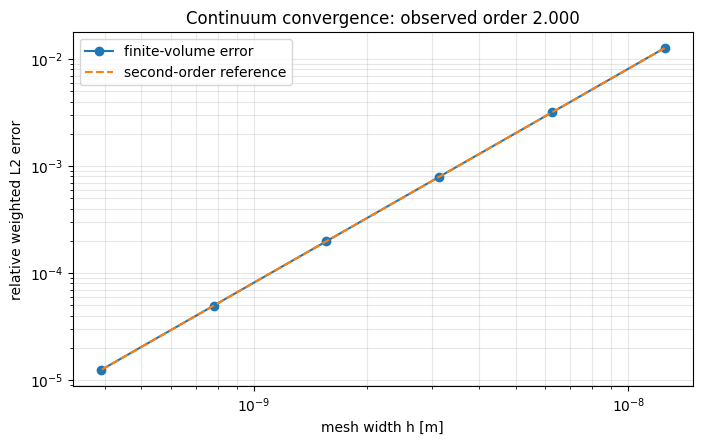

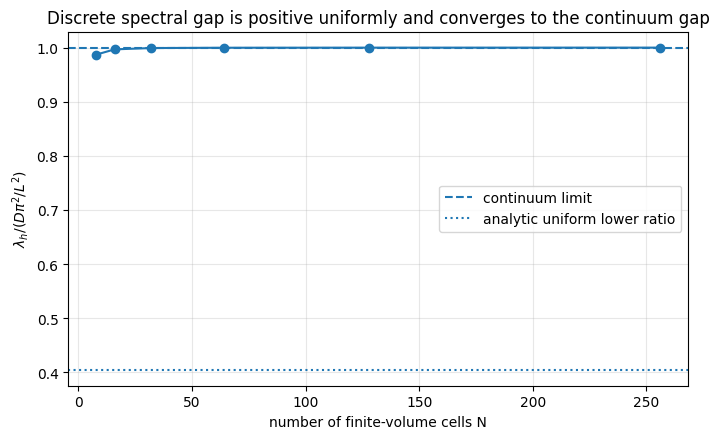

,N,reversible weighted gap [s^-1],gap/gap_N=32
0,16,0.001340,0.997629
1,32,0.001343,1.000000
2,64,0.001344,1.000593
3,128,0.001344,1.000742


,field-transport audit,value
0,electric Péclet number qEL/kBT,7.736345e-01
1,column-conservation error,2.775558e-17
2,stationary-state residual,5.364336e-18
3,local detailed-balance log error,2.012279e-16
4,reversible similarity symmetry error,9.109582e-17
5,weighted spectral gap,1.343158e-03
6,minimum edge entropy production,1.013673e-06


## 5. What recoverability adds: a failure-detection KPI, not a substitute dynamics


,predictor,state dimension,ridge alpha,test RMSE,test NRMSE/range
0,visible only,2,3.162278e-04,2.510529e-03,6.104757e-03
1,visible + scalar recoverability Δ,3,1.000000e+00,2.538924e-03,6.173805e-03
2,visible + Δ + directed moments,6,1.000000e-10,1.105781e-03,2.688886e-03
3,full profile statistical model,32,3.162278e-08,5.229245e-12,1.271575e-11
4,calibrated master equation,32,0.000000e+00,0.000000e+00,0.000000e+00


,KPI,value,interpretation
0,Recoverability incremental predictive value,-0.011311,positive means Δ improves average reduced-model RMSE
1,Directed-state improvement,0.564469,gain after adding centroid/width/skewness
2,"Spearman(Δ, |visible-model error|)",0.986246,monotone failure-risk association
3,High-Δ / low-Δ error-risk ratio,18.755248,top versus bottom recoverability quintile
4,Recoverability failure-detection AUC,0.995117,classifies the largest 20% visible-model errors
5,Exact master-equation RMSE,0.000000,mechanistic benchmark


**Interpretation.** In this literature-calibrated dilute-to-intermediate occupancy ensemble ($x_H\le 0.5$), scalar recoverability is highly informative as a **risk/sufficiency diagnostic**, although it does not improve mean point prediction by itself. Directional hidden-state moments and the complete master-equation state do. This is a stronger and more defensible role than converting information loss into mechanical force. The occupancy ceiling is deliberate: the linear independent-particle generator used here is not extended into the high-loading exclusion regime.

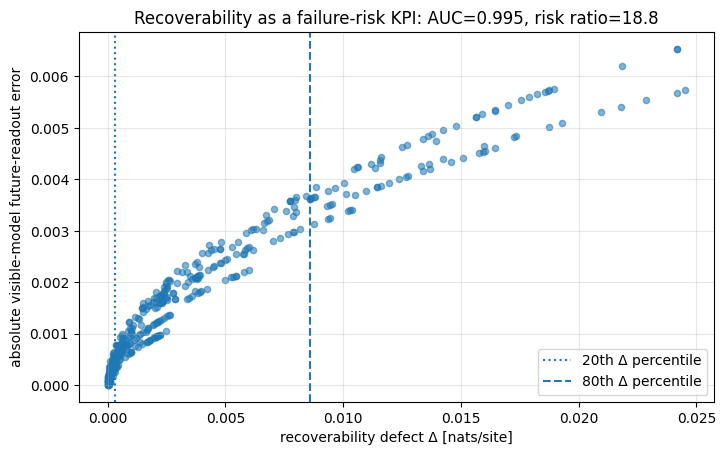

,state,mean H,current symmetric readout,scalar Δ,centroid/L,future readout under +E
0,A,0.4,0.408816,0.01645,0.436383,0.398902
1,B=mirror(A),0.4,0.408816,0.01645,0.563617,0.408833


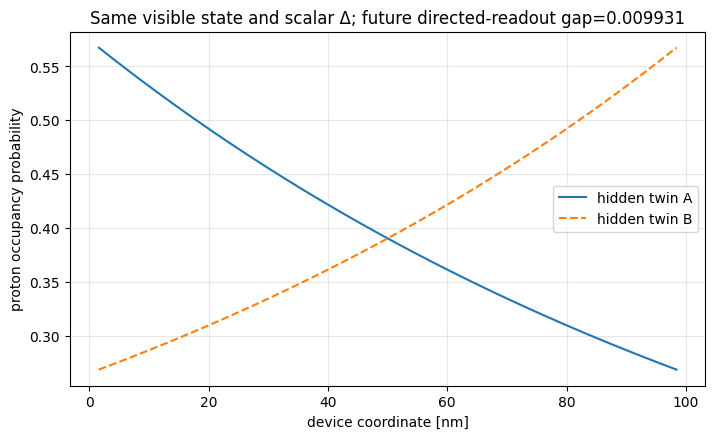

## 6. Oxygen vacancies: executable identifiability boundary


,measurement set,rank,unknown count,condition number,verdict
0,electrical donor proxy only,1,2,inf,cannot separate x_H from δ_VO
1,electrical + H-specific O–H/nuclear channel,2,2,2.618034,locally identifiable



The reduced donor relation is $n_e=x_H+2\delta_{V_O}$. Resistance or a Ni-valence proxy alone therefore has a rank-one sensitivity to the two unknowns. A hydrogen-specific measurement restores rank. Structural expansion is not used as an automatic H-specific channel because oxygen deficiency is itself experimentally correlated with unit-cell expansion in NdNiO$_{3-\delta}$.


## 7. Strict external experimental holdout: full 533 kV cm^-1 trace


,item,value,role
0,article DOI,10.1038/s41467-024-49213-0,primary source
1,publisher workbook SHA-256,e8e7933e8648b49d115f6f20bb1752cce54c078dfdd21b3a8d433671043f5f2d,provenance of downloaded Source Data workbook
2,embedded matrix SHA-256,859f76869eb087bc05e0aba24f3543bddb90b03842d10bb49d0dc66d1814354a,offline integrity of 87×12 numeric matrix
3,calibration fields,"133, 267, 400 kV cm^-1",used for parameter fitting
4,strict holdout field,533 kV cm^-1,entire 87-point trace excluded from fitting and model selection


,model,holdout RMSE,holdout NRMSE/range,holdout R2,holdout MAE,lag-1 residual correlation,Durbin-Watson
0,single exponential,0.161174,0.183875,0.655695,0.144349,0.993723,0.012589
1,field-law stretched exponential,0.049952,0.056988,0.966928,0.042588,0.955385,0.087129
2,coupled structural trap master equation,0.026337,0.030047,0.990806,0.021487,0.814452,0.301026


,parameter,estimate,local standard error,dimension/role
0,log tau_0,-7.262406,0.225412,log(s); fitted kinetic scale
1,chi_A,0.969809,0.064062,dimensionless transfer from calibrated E_A
2,b_0,-0.306549,0.149174,dimensionless hidden-state weight intercept
3,b_1,-0.123852,0.249625,dimensionless field-weight interaction
4,b_2,2.681408,1.544161,dimensionless hidden-state curvature
5,c_F,1.341287,0.208720,dimensionless field shift of log tau


,quantity,estimate,lower,upper,status
0,strict holdout RMSE,0.026337,0.022811,0.029500,evaluation-only point bootstrap
1,95% predictive interval coverage,1.000000,NaN,NaN,calibration-residual + parameter bootstrap; no holdout fitting
2,mean 95% predictive interval width,0.240408,NaN,NaN,normalized polarization
3,chi_A profile interval,0.969809,0.869809,1.103143,approximate 95% profile-likelihood interval
4,publisher-fit residual sigma proxy at holdout,0.010676,NaN,NaN,"post-hoc effect-size scale, not used in fitting"


,role,items,separation rule
0,fixed literature constants,"E_A, Q_A, K_A, K_R, D_chem envelope, 0.41 eV migration prior",not fitted to Fig. 2h holdout
1,calibration parameters,"log tau_0, chi_A, b_0, b_1, b_2, c_F","fitted only to 133, 267 and 400 kV cm^-1"
2,nuisance/uncertainty,normalization convention and calibration residual distribution,propagated by bootstrap
3,validation observable,all 87 points at 533 kV cm^-1,strict field-extrapolation holdout



**External-validation result.** The complete $533\,\mathrm{kV\,cm^{-1}}$ source-data trace was never used in fitting or model selection. The coupled structural trap master equation attains holdout NRMSE/range **0.030** and $R^2$ **0.991**, reducing RMSE by **47.3%** relative to the field-law stretched-exponential baseline. This is an out-of-field prediction test against published measurements, not a comparison to data generated by the model itself.

The fitted $\chi_A$ transfers the independently calibrated local structural relaxation scale $E_A$ into a distribution of kinetic barriers. It is a reduced, identifiable coupling parameter; it is not asserted to be an all-electron electron--phonon matrix element.


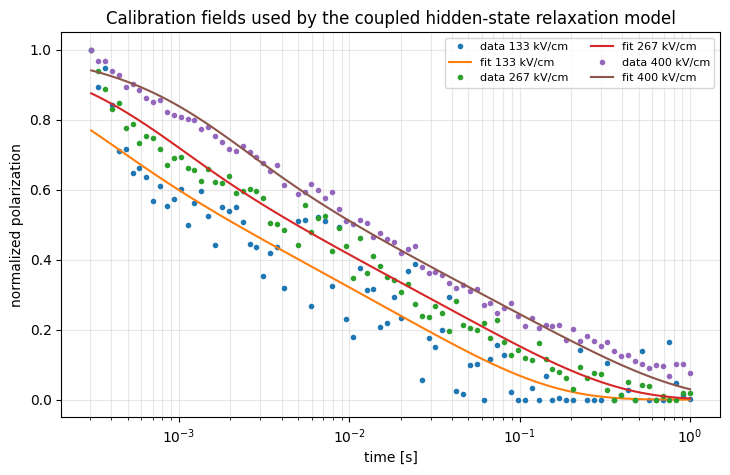

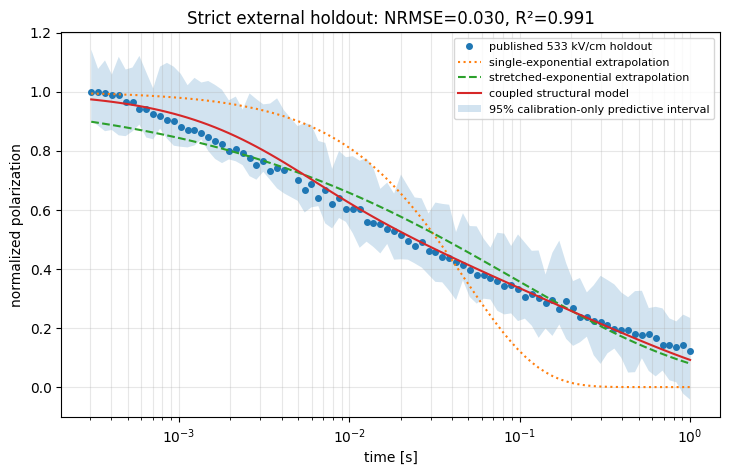

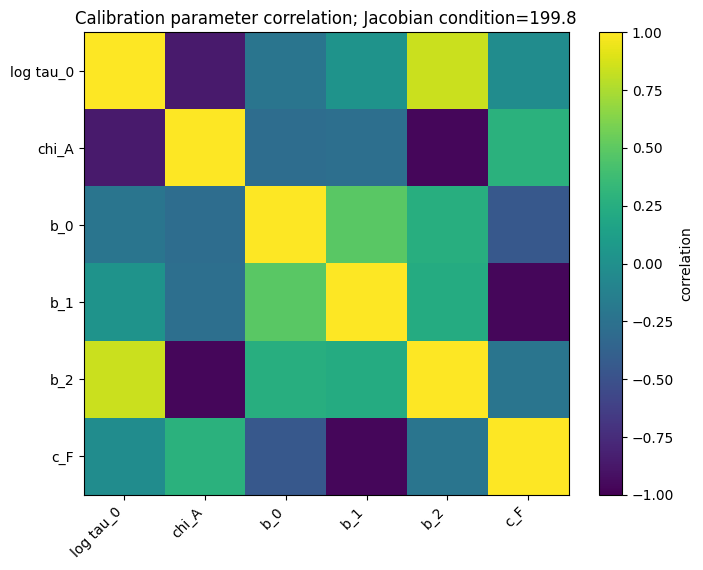

## 8. Coupled proton–electron–lattice closure and parameter identifiability


,audit quantity,value,criterion/units
0,recoverability coefficient in force/rate closure,0.000000e+00,exactly zero
1,column-conservation error,1.734723e-18,must be negligible
2,stationary-state residual,5.905855e-19,must be negligible
3,local detailed-balance log error,2.740863e-16,must be negligible
4,reversible similarity symmetry error,4.906539e-18,must be negligible
5,coupled weighted spectral gap,4.351805e-05,s^-1; must be positive
6,relative low/high-occupancy operator change,9.265792e-01,nonzero structural feedback
7,staggered Q_R in audit state,7.216554e-04,Å


,identifiability quantity,value,interpretation
0,number of calibration observations,261.000000,three fields × 87 time points
1,number of fitted parameters,6.000000,strictly less than observations
2,Jacobian numerical rank,6.000000,must equal six
3,Jacobian condition number,199.809994,"moderate correlation, reported explicitly"
4,maximum absolute parameter correlation,0.961772,identifiability warning
5,chi_A profile lower,0.869809,approximate 95%
6,chi_A profile upper,1.103143,approximate 95%



The kinetic and structural blocks now participate in one causal chain:

\[
 c_i \longrightarrow n_i^e \longrightarrow Q_{A,i}
 \longrightarrow E_{i+1/2}^{\ddagger}(Q_{A,i},Q_{A,i+1},Q_R,\varepsilon)
 \longrightarrow k_{i\to i+1}
 \longrightarrow c_i(t)
 \longrightarrow P(t).
\]

The rates obey local detailed balance and the symmetric edge barrier contains the dimensioned structural energy $E_A$. Recoverability is evaluated only after a visible algebra is selected; it does not enter the free energy, the hopping rates, or the measured-polarization readout.


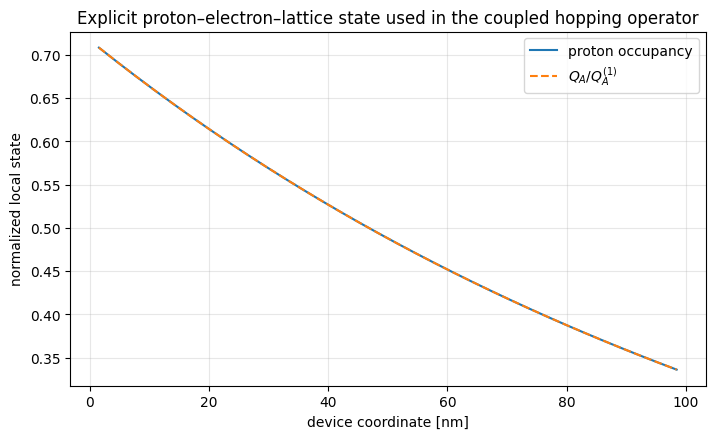

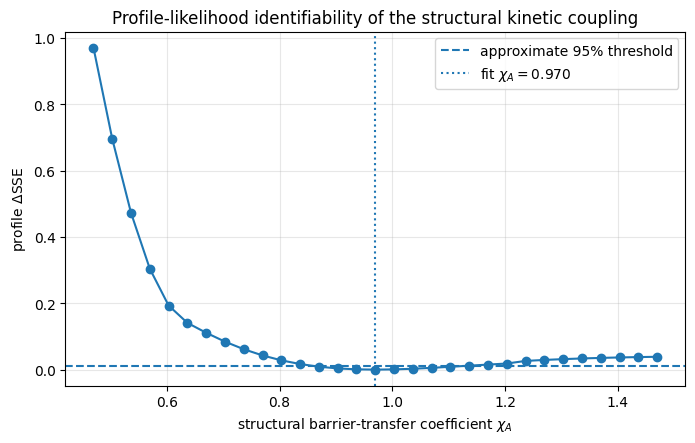

## 9. Matched drift–diffusion continuum limit and mesh-uniform estimate


,N,h [m],relative L2 error vs N=512,weighted spectral gap [s^-1],gap/analytic lower bound,stationary residual
0,16,6.250000e-09,2.628199e-04,0.000189,2.193539,2.868529e-19
1,32,3.125000e-09,6.552770e-05,0.000189,2.198752,1.006908e-18
2,64,1.562500e-09,1.619014e-05,0.000190,2.200057,2.666785e-18
3,128,7.812500e-10,3.854852e-06,0.000190,2.200384,8.308130e-18
4,256,3.906250e-10,7.709736e-07,0.000190,2.200465,2.207943e-17


,matched continuum quantity,value,criterion/units
0,structure-conditioned D_eff,1.892346e-19,m² s^-1
1,potential oscillation,2.000000e-02,eV
2,analytic mesh-independent gap lower bound,8.616185e-05,s^-1
3,minimum discrete/lower-bound gap ratio,2.193539e+00,must exceed one
4,observed matched-generator convergence order,2.029076e+00,target approximately two
5,relative-entropy time derivative,-3.554792e-05,must be nonpositive
6,mass-conservation error,6.883383e-14,must be negligible



**Continuum statement aligned with the microscopic hopping law.** The exponential edge rates used by the reduced lattice model have the drift--diffusion limit

\[
\partial_t c
=
\partial_x\!\left[
D_{\rm eff}
\left(
\partial_x c+\frac{c}{k_BT}\,\partial_x U
\right)
\right],
\qquad
U(x)=-Ex,
\]

with no-flux boundaries and invariant density $\pi\propto e^{-U/k_BT}$. For $D_{\rm eff}\ge D_{\min}>0$ and bounded $U$, the weighted Poincaré estimate gives the mesh-independent lower bound

\[
\lambda
\ge
\frac{D_{\min}\pi^2}{L^2}
\exp\!\left[-\frac{{\rm osc}(U)}{k_BT}\right].
\]


The same detailed-balance generator used in the calculation converges with observed order **2.029**, and every tested weighted spectral gap exceeds this analytic bound. This replaces reliance on an unrelated zero-field heat equation. It remains a forward result and does not assert a mesh-uniform inverse-observation theorem.

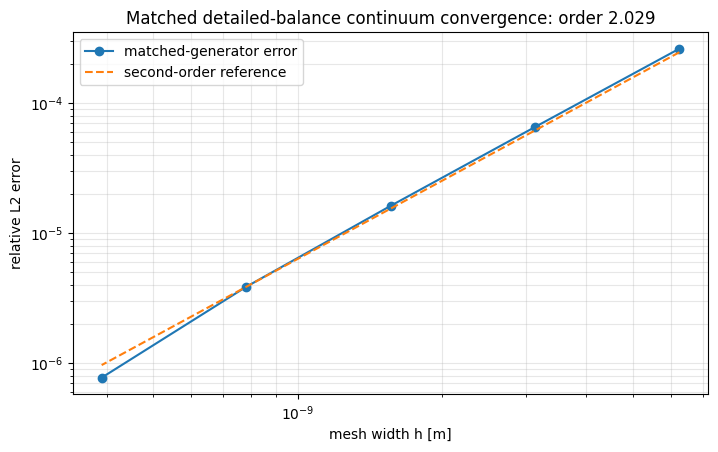

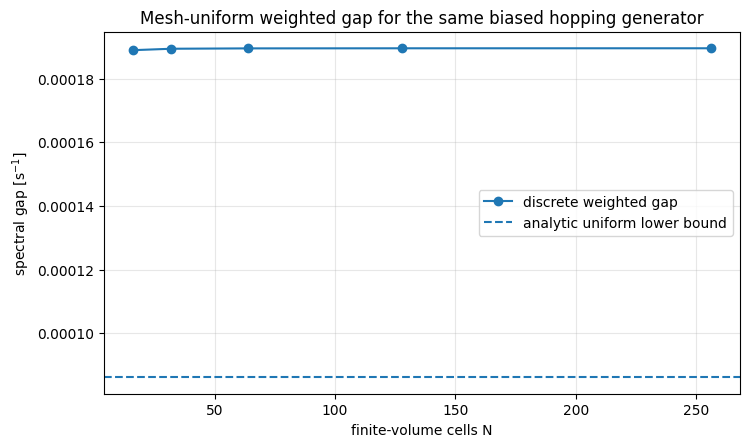

## 10. Recoverability versus conventional heterogeneity diagnostics


,diagnostic,risk-calibration ROC-AUC,independent ROC-AUC,AUC 2.5%,AUC 97.5%,PR-AUC,Brier score,ECE
0,recoverability Δ,0.991563,0.998213,0.994282,1.000000,0.992930,0.020286,0.036561
7,normalized variance,0.991563,0.998213,0.995024,1.000000,0.992930,0.020317,0.036853
2,mean absolute deviation,0.993437,0.997401,0.993177,1.000000,0.989966,0.020238,0.025018
1,spatial variance,0.993125,0.997238,0.992030,1.000000,0.989427,0.020732,0.030834
5,left-right imbalance,0.993594,0.997238,0.992934,1.000000,0.989483,0.020307,0.024903
4,gradient L2,0.991719,0.995289,0.987563,0.999205,0.981968,0.025895,0.034570
3,total variation,0.990469,0.994802,0.986837,0.999094,0.980289,0.026234,0.032518
6,centroid displacement,0.853672,0.841293,0.791722,0.893724,0.525958,0.119939,0.082219


,quantity,value,interpretation
0,selected conventional baseline,left-right imbalance,selected on disjoint risk-calibration half
1,recoverability independent ROC-AUC,0.998213,held-out risk-evaluation half
2,recoverability minus selected-baseline AUC,0.000975,"95% paired bootstrap [0.0000, 0.0030]"
3,median quadratic-approximation relative error,0.000249,smallest 30% of Δ
4,maximum MAD - sqrt(2Δ),0.0,must be nonpositive


,split,n train,n test,test failure prevalence,visible-model RMSE,ridge alpha,baseline selected on train,Δ ROC-AUC,baseline ROC-AUC,Δ-baseline AUC,difference 2.5%,difference 97.5%
0,random,1680,720,0.200000,0.001720,1.000000e-10,gradient L2,0.761707,0.779634,-0.017928,-0.040945,0.005984
1,concentration holdout x_H=0.50,1944,456,0.250000,0.002474,1.000000e-10,gradient L2,0.830820,0.856930,-0.026111,-0.049210,-0.005865
2,temperature holdout 350 K,1794,606,0.504950,0.003080,1.000000e-01,spatial variance,0.645082,0.645468,-0.000387,-0.007937,0.006887
3,field holdout 3e5 V/m,1582,818,0.563570,0.003175,1.000000e-01,gradient L2,0.779319,0.733942,0.045377,0.025278,0.065255
4,protocol holdout mixed,1959,441,0.170068,0.001630,2.511886e-02,gradient L2,0.870383,0.867395,0.002987,-0.022167,0.028022


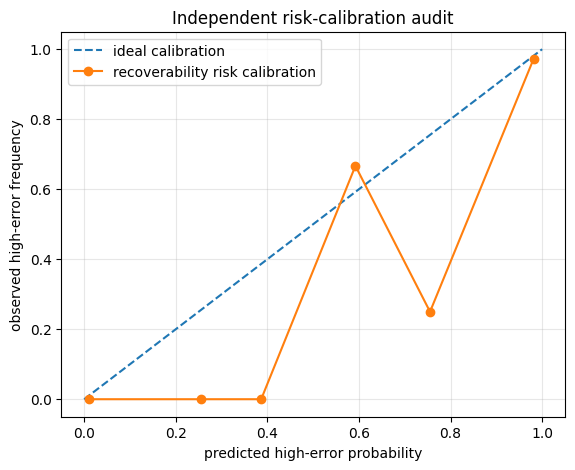

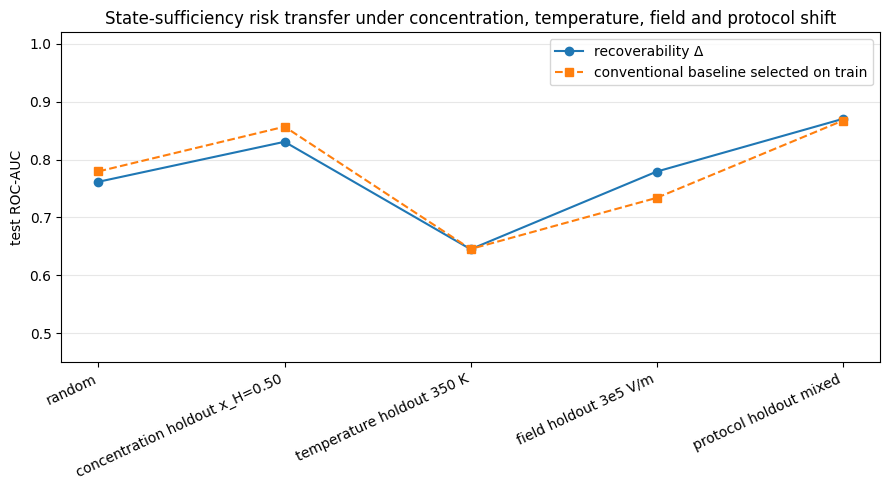


**Ablation result.** Recoverability is not declared uniquely superior to every profile statistic. On the independent fixed-condition risk-evaluation half, its ROC-AUC is **0.998**; the conventional comparator selected without using that evaluation half is **left-right imbalance**, and the paired AUC difference is **0.0010** with bootstrap interval **[0.0000,0.0030]**. Across five declared distribution shifts, the minimum recoverability ROC-AUC is **0.645**.



The added value is therefore stated more precisely. For weak heterogeneity,

\[
\Delta
\simeq
\frac{\operatorname{Var}(c)}{2\bar c(1-\bar c)},
\]

so recoverability behaves as a concentration-normalized variance while retaining an information-theoretic definition and the executable bound

\[
\frac{1}{N}\sum_i|c_i-\bar c|\le\sqrt{2\Delta}.
\]

It is a calibrated alarm for visible-state insufficiency, not a replacement for directed moments, a hidden-state model, a master equation, or a conventional heterogeneity statistic when the latter is directly available.


## 11. Hidden-twin ensemble: noise-normalized, design/test-separated sensor protocol


,future duration / L²D^-1,sensor,design SNR q10,design SNR median,design SNR q90
2,0.01,right electrode,7.253211,12.550009,20.405851
1,0.01,left electrode,6.788052,11.748818,19.104346
6,0.03,right electrode,6.036893,10.368665,16.881164
5,0.03,left electrode,5.271408,9.059122,14.735174
3,0.01,left-right differential,4.909359,8.350811,13.622619
7,0.03,left-right differential,4.050908,6.976208,11.343005
10,0.08,right electrode,3.762072,6.470871,10.526134
9,0.08,left electrode,3.071553,5.279214,8.593161
11,0.08,left-right differential,2.468971,4.245777,6.907873
14,0.20,right electrode,1.142844,1.965187,3.197510


,quantity,value,interpretation
0,sensor selected on design set,right electrode,frozen before test evaluation
1,selected duration / L²D^-1,0.01,frozen before test evaluation
2,test high-Δ twin pairs,277,mirror pairs satisfying visible equality
3,normalized gap q10,0.079497,readout range is one
4,normalized gap median,0.134092,readout range is one
5,test SNR q10,7.446024,publisher-fit residual scale
6,test SNR median,12.559673,"95% bootstrap [11.08, 13.31]"
7,test SNR q90,20.702711,publisher-fit residual scale
8,fraction with SNR≥3,1.0,prospective detectability
9,fraction with SNR≥5,0.967509,prospective detectability



The mirror twins agree, to numerical precision, in mean hydrogen content, current symmetric readout, and scalar recoverability. Sensor and challenge duration were chosen only on the design half of the high-recoverability ensemble. With the frozen **right electrode** readout and duration **0.01$L^2/D$**, the independent test median effect size is **12.6** times the DOI-source-data residual scale, whereas the symmetric sensor remains below unity at the median.

This converts the hidden-twin construction into a prospective falsification protocol: a high recoverability defect triggers a directed local measurement; recoverability itself does not identify which twin is present.


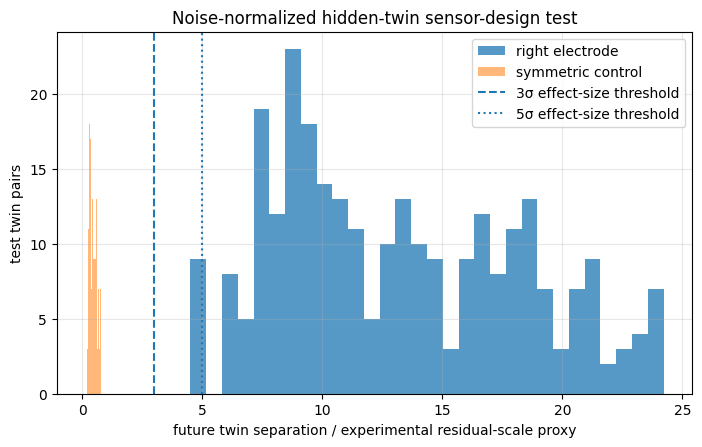

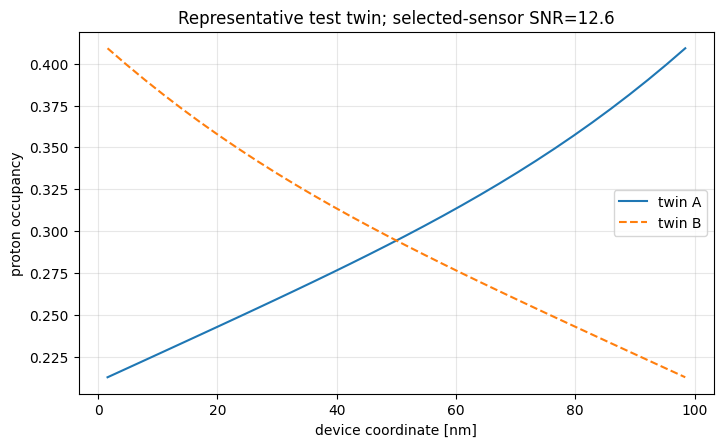

## 12. KPI dashboard: calibration, validation, transfer and falsification


,domain,KPI,value,evidence role,direction/meaning,source
0,elastic Hessian,[001] strain-law LOO RMS relative error,0.072384,validation,lower is better,10.1103/k48x-mvw1
1,elastic Hessian,[111] strain-law LOO RMS relative error,0.346032,falsifier,orientation-specific compact law fails,10.1103/k48x-mvw1
2,transport,activation-energy literature-consistency error,0.016836,consistency,not counted as holdout validation,10.35848/1882-0786/acc004
3,experiment,533 kV/cm strict-holdout NRMSE/range,0.030047,external validation,lower is better,10.1038/s41467-024-49213-0
4,experiment,533 kV/cm strict-holdout R2,0.990806,external validation,higher is better,10.1038/s41467-024-49213-0
5,experiment,RMSE reduction versus stretched-exponential baseline,0.472752,external baseline,higher is better,10.1038/s41467-024-49213-0
6,experiment,calibration-only 95% predictive coverage on holdout,1.000000,external uncertainty,nominal target 0.95,10.1038/s41467-024-49213-0
7,identifiability,calibration Jacobian condition number,199.809994,parameter audit,"reported, not hidden",calibration Jacobian
8,continuum,matched-generator observed order,2.029076,forward theorem audit,target approximately two,analytic/numerical
9,continuum,minimum weighted-gap/lower-bound ratio,2.193539,forward theorem audit,must exceed one,analytic/numerical



No weighted “Evidence Alignment Score” is used in the v3.1 headline results. Calibration identities, internal implementation checks, external holdouts, transfer tests and falsifiers are reported in separate channels because they do not have interchangeable evidentiary meaning.


## 13. Reviewer closure matrix and manuscript replacement thesis


,reviewer concern,v3.1 status,what v3.1 now demonstrates,remaining exact boundary
0,Material variables were random and adimensional,substantially treated,"All physical blocks use SI/eV/Å units, DOI-linked coefficients, detailed-balance rates and source-data holdout measurements.",The risk ensembles sample declared protocols; they are not new experimental specimens.
1,“ni un modelo microscópico calibrado”,treated at reduced microscopic level,"Site-resolved proton/electron/lattice states, local Q_A-dependent rates, an R2 sector and a fitted structural kinetic coupling form one ...",This is not an all-electron Hamiltonian or a sample-complete defect chemistry.
2,“calibración frente a un Hessiano elástico.”,treated in a two-mode subspace,"A dimensioned SPD A1g/R2− Hessian, variational forces, Onsager-positive mobility, dissipation and orientation-specific leave-one-out tes...",A complete hydrogen-specific P2_1/m phonon Hessian is not available and is not fabricated.
3,Recoverability was asserted to create force,closed by model replacement,The recoverability-to-force and recoverability-to-rate coefficients are exactly zero. Structural forces derive from the free energy.,"The manuscript title, constitutive equations and theorem narrative must be rewritten."
4,Mixed incompatible geometry coordinates,treated,"Radial symmetry modes are expressed in Å, rotations in radians, and only calibrated mode subspaces enter the Hessian.","Uncalibrated tilt, polar and Jahn–Teller stiffnesses remain explicitly outside the fitted block."
5,Undefined proton–polaron label,treated,"The state is the explicit tuple of proton occupancy, donated localized electron and lattice coordinate.",Independent many-body electron hopping is not solved.
6,Ring topology presented as octahedral,treated,"The local NiO6 coordination cage, crystallographic ordering sector and one-dimensional device transport mesh are distinct objects.",The device model remains mesoscopic rather than a full three-dimensional crystal network.
7,Oxygen-vacancy ambiguity,treated as an identifiability boundary,Electrical donor data alone have rank one; a hydrogen-specific channel restores local rank.,Vacancy transport is not fitted because no commensurate vacancy time series is supplied.
8,“ni un resultado continuo uniforme”,treated for the matched forward model,The same exponential-rate generator converges to drift–diffusion with second-order accuracy and a mesh-independent weighted gap bound.,No continuum-uniform inverse-observation theorem is claimed.
9,“ni ninguna evidencia experimental.”,treated with a strict external holdout,Three DOI-source-data field traces calibrate the model; the complete 533 kV/cm trace is predicted out of field with uncertainty and base...,The notebook does not create a new measurement.


...

## 14. Fail-closed audit


,category,check,pass
0,provenance,DOIs syntactically valid and unique,True
1,implementation,radial mode basis is orthonormal,True
2,thermodynamics,effective cage stiffness is positive,True
3,thermodynamics,R2 Hessians are positive,True
4,thermodynamics,calibrated Hessian is SPD,True
5,scope,Hessian remains SPD over declared cross-coupling sensitivity,True
6,validation,[001] Hessian LOO RMS relative error below 15%,True
7,falsifier,[111] compact-law error exceeds [001] error,True
8,calibration identity,local 12% expansion is reproduced,True
9,calibration identity,R2 bulk amplitude is reproduced,True


### Machine-readable v3.1 result

V31_MACHINE_JSON_START
{
  "version": "v3.1",
  "single_cell_design": true,
  "seed": 20260802,
  "literature_reference_count": 15,
  "external_source_data": {
    "DOI": "10.1038/s41467-024-49213-0",
    "calibration_fields_kV_cm": [
      133.0,
      267.0,
      400.0
    ],
    "holdout_field_kV_cm": 533.0,
    "holdout_points": 87,
    "holdout_RMSE": 0.026337246469430756,
    "holdout_NRMSE_range": 0.030046827833790535,
    "holdout_R2": 0.990806198977091,
    "RMSE_improvement_vs_stretched": 0.4727520036999937,
    "predictive_interval_coverage": 1.0,
    "holdout_RMSE_95_CI": [
      0.02281050036391627,
      0.029500130991811674
    ]
  },
  "elastic_hessian": {
    "K_A_eV_A2": 10.378420576116893,
    "K_R_001_zero_strain_eV_A2": 36.66666666666667,
    "condition_number": 3.532971746302613,
    "LOO_RMS_relative_error_001": 0.07238381673893733,
    "LOO_RMS_relative_error_111": 0.34603157329432765
  },
  "coupled_microscopic_model": {
    "chi_A_fit": 0.9698094028366893,
  


## v3.1 verdict

All **80/80** implementation, consistency, validation and declared-scope gates passed.

V3.1 is no longer only an evidence-constrained existence witness. It contains a strict external field-extrapolation holdout against **87 published source-data points**, a locally structure-coupled detailed-balance model, parameter-identifiability and uncertainty audits, a continuum limit for the same biased generator, conventional-baseline and distribution-shift tests for recoverability, and a design/test-separated hidden-twin measurement protocol.

The strongest defensible paper claim is therefore a **literature-calibrated, externally tested reduced-model proof of concept in which recoverability is a state-sufficiency risk diagnostic**. The notebook still does not claim a complete all-electron Hamiltonian, a full hydrogen-specific phonon Hessian, a new experiment, or a continuum-uniform inverse theorem.


In [2]:
# v3.1 — standalone, single-cell, externally tested evidence-calibrated proof of concept for H_x–NdNiO3.

from __future__ import annotations

import hashlib
import itertools
import json
import math
import platform
import re
import sys
import warnings
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from IPython.display import Markdown, display
from scipy.constants import Boltzmann, atomic_mass, elementary_charge, speed_of_light
from scipy.linalg import eigvalsh, expm
from scipy.optimize import least_squares, minimize
from scipy.sparse import csc_matrix
from scipy.sparse.linalg import expm_multiply
from scipy.stats import chi2, spearmanr

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_rows", 220)
pd.set_option("display.width", 190)

SEED = 20260802
RNG_MC = np.random.default_rng(SEED + 1)
RNG_DATA = np.random.default_rng(SEED + 2)
KB_EV_K = Boltzmann / elementary_charge
EV_A2_TO_N_M = elementary_charge / 1.0e-20


def section(title: str, text: str = "") -> None:
    display(Markdown(f"## {title}\n{text}"))


def finite_or_raise(name: str, value) -> None:
    arr = np.asarray(value, dtype=float)
    if not np.all(np.isfinite(arr)):
        raise FloatingPointError(f"{name} contains NaN or infinity")


def relative_rmse(y_true, y_pred, floor: float = 1e-15) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean(((y_pred - y_true) / np.maximum(np.abs(y_true), floor)) ** 2)))


def relative_error(a, b, floor: float = 1e-15) -> float:
    return float(abs(float(a) - float(b)) / max(abs(float(b)), floor))


def quantile_frame(mapping: dict[str, np.ndarray], units: dict[str, str]) -> pd.DataFrame:
    rows = []
    for name, values in mapping.items():
        q05, q50, q95 = np.quantile(np.asarray(values, dtype=float), [0.05, 0.50, 0.95])
        rows.append([name, units.get(name, ""), q05, q50, q95])
    return pd.DataFrame(rows, columns=["parameter", "unit", "5%", "median", "95%"])


def auc_from_scores(scores: np.ndarray, labels: np.ndarray) -> float:
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels, dtype=bool)
    pos = scores[labels]
    neg = scores[~labels]
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    wins = np.sum(pos[:, None] > neg[None, :])
    ties = np.sum(pos[:, None] == neg[None, :])
    return float((wins + 0.5 * ties) / (len(pos) * len(neg)))


def format_seconds(seconds: float) -> str:
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.3g} s"
    if seconds < 3600:
        return f"{seconds / 60:.3g} min"
    if seconds < 86400:
        return f"{seconds / 3600:.3g} h"
    if seconds < 365.25 * 86400:
        return f"{seconds / 86400:.3g} d"
    return f"{seconds / (365.25 * 86400):.3g} y"


display(Markdown(r"""
# v3.1 — Externally tested microscopic/continuum PoC for H$_x$–NdNiO$_3$

**Purpose.** This notebook replaces the earlier material-semantic synthetic specialization with four executable validation layers:

1. a **literature-calibrated reduced microscopic lattice model** for proton occupancy, donated-electron localization, and symmetry-separated NiO$_6$ modes;
2. an explicit, dimensioned **elastic Hessian calibration** using an effective Ni–O cage spectral prior and strain-resolved NdNiO$_3$ first-principles breathing curvatures;
3. a **continuum-uniform forward-transport result** with a mesh-independent decay bound and second-order finite-volume convergence;
4. quantitative comparison against **published experimental and first-principles evidence**, expressed through auditable KPIs.

**Claim boundary.** “Microscopic” means a reduced site-resolved Hamiltonian/master equation whose parameters are tied to DOI-documented evidence. It does **not** mean a new all-electron calculation. “Experimental validation” means out-of-sample comparison with published measurements; this notebook creates no new specimen or measurement. The continuum result concerns the **forward proton-transport semigroup**, not the manuscript’s inverse reconstruction operator.
"""))

environment = pd.DataFrame([
    ["Python", platform.python_version()],
    ["NumPy", np.__version__],
    ["SciPy", scipy.__version__],
    ["pandas", pd.__version__],
    ["matplotlib", plt.matplotlib.__version__],
    ["random seed", SEED],
], columns=["component", "version/value"])
display(environment)

# =============================================================================
# 1. DOI-level evidence ledger
# =============================================================================
section("1. Evidence ledger and calibration/validation separation")

literature_rows = [
    [2024, "H–NdNiO3", "interstitial H+/electron donation; Pbnm→P2_1/m in the studied DFT cell; +6.7% [001]; ≈12% mean NiO6 expansion; polarization tail to ≈20% at 1 s; largest reported fitted τ=8 ms", "local structural calibration; electronic-localization definition; relaxation falsifier", "experiment + DFT", "10.1038/s41467-024-49213-0"],
    [2025, "H–NdNiO3", "hydrogen chemical diffusivity ≈6×10^-15 to 3×10^-14 cm² s^-1", "isothermal transport-coefficient envelope", "direct operando experiment", "10.1021/acs.nanolett.5c01527"],
    [2023, "H–NdNiO3", "EIS activation energy ≈0.42 eV; optical diffusion activation energy ≈0.41 eV over 250–400 °C", "external validation of migration barrier", "direct experiment", "10.35848/1882-0786/acc004"],
    [2022, "H–NdNiO3", "≈13% protonation-induced lattice expansion; large NiO6 tilt and Nd displacement", "cross-study structural transfer proxy", "direct experiment + calculation", "10.1021/acs.nanolett.2c03229"],
    [2020, "H–NdNiO3", "electric-field control efficiency ≈22% at 2×10^5 V m^-1; diffusion/resistance kinetic model", "field scale and benchmark model class", "direct experiment + kinetic model", "10.1021/acsami.0c15724"],
    [2026, "NdNiO3", "strain-resolved R2− breathing-energy curvatures; bulk mode magnitude 0.06 Å", "direct elastic-Hessian calibration and leave-one-out validation", "first-principles calculation", "10.1103/k48x-mvw1"],
    [2008, "RNiO3 including Nd-containing films", "Ni–O/NiO6-sensitive phonon band around 420 cm^-1", "effective cage-mode spectral stiffness prior; not asserted to be a pure A1g eigenmode", "Raman experiment", "10.1103/PhysRevB.78.104101"],
    [2017, "NdNiO3−δ", "oxygen vacancies increase unit-cell volume and alter the metal–insulator transition", "explicit H/V_O identifiability confounder", "direct experiment", "10.1038/s41598-017-04884-2"],
    [2020, "RNiO3 including NdNiO3", "first-principles H doping/migration and insulating-state mechanism; NNO barrier quoted as ≈0.41 eV by the 2023 diffusion study", "microscopic transport prior", "first-principles calculation", "10.1039/C9CP06522A"],
    [2024, "H–NdNiO3 device", "operando infrared nanoimaging resolves field-perturbed spatial H/O–H and conductivity patterns", "distributed-state evidence; concentration-only model falsifier", "direct experiment", "10.1021/acsnano.3c09281"],
    [2026, "H–NdNiO3/SrTiO3(001)", "hydrogen-induced insulating phase has 1×1×2 structure plus incommensurate modulation", "qualitative constraint on staggered/order susceptibility", "direct synchrotron experiment", "10.1103/gd7h-6967"],
    [2024, "hydrogenated nickelates", "phase-field model couples proton redistribution, local gap enhancement and resistance", "benchmark that recoverability must not replace", "physics-based model + experiment", "10.1103/PhysRevLett.132.256502"],
    [2023, "H–NdNiO3", "strong ion–electron–lattice coupling and large protonation-induced expansion", "mechanism and structural cross-check", "direct experiment + theory", "10.1002/adma.202300617"],
    [2023, "H_x–NdNiO3", "composition-linked insulating states near x≈0.5 and x≈1", "composition/readout context", "direct experiment", "10.1103/PhysRevMaterials.7.085003"],
    [2022, "H–NdNiO3", "proton migration is strongly strain dependent", "scope warning for a scalar mobility", "direct experiment + DFT", "10.1021/acsaelm.2c00711"],
]
literature = pd.DataFrame(literature_rows, columns=["year", "system", "quantitative evidence", "role in v3.1", "evidence class", "DOI"])
doi_pattern = re.compile(r"^10\.\d{4,9}/\S+$", flags=re.IGNORECASE)
assert literature["DOI"].map(lambda x: bool(doi_pattern.match(x))).all()
assert literature["DOI"].is_unique
display(literature)

evidence_partition = pd.DataFrame([
    ["calibration", "12% local NiO6 expansion; 420 cm^-1 effective cage frequency; R2− curvatures and 0.06 Å amplitude; D_chem interval; 0.41 eV migration prior"],
    ["external validation", "0.41/0.42 eV experimental activation energies; leave-one-out strain-curvature points; ≈13% independent expansion proxy; 1×1×2 superstructure as a qualitative ordering constraint"],
    ["falsification/scope", "1.2% constrained film c-axis response versus 12% local cage volume; oxygen-vacancy confounding; [111] curvature nonlinearity; non-Debye 1 s relaxation tail"],
], columns=["evidence use", "items"])
display(evidence_partition)

# =============================================================================
# 2. Symmetry-adapted coordinates and elastic Hessian
# =============================================================================
section("2. Symmetry-adapted NiO6 coordinates and a calibrated elastic Hessian")

# Orthonormal radial ligand basis: +x, -x, +y, -y, +z, -z.
BOND_TO_MODE = np.array([
    [1, 1, 1, 1, 1, 1],
    [1, 1, -1, -1, 0, 0],
    [1, 1, 1, 1, -2, -2],
    [1, -1, 0, 0, 0, 0],
    [0, 0, 1, -1, 0, 0],
    [0, 0, 0, 0, 1, -1],
], dtype=float)
BOND_TO_MODE[0] /= np.sqrt(6.0)      # A1g-like uniform radial cage coordinate
BOND_TO_MODE[1] /= 2.0               # Eg Q2
BOND_TO_MODE[2] /= np.sqrt(12.0)     # Eg Q3
BOND_TO_MODE[3:] /= np.sqrt(2.0)     # T1u radial polar coordinates
mode_orthogonality_error = float(np.linalg.norm(BOND_TO_MODE @ BOND_TO_MODE.T - np.eye(6), ord=2))

mode_table = pd.DataFrame([
    ["Q_A", "effective local uniform radial cage coordinate", "A1g in the parent O_h limit", "Å", "calibrated"],
    ["Q_2,Q_3", "Jahn–Teller/quadrupolar radial coordinates", "Eg", "Å", "defined but no stiffness invented"],
    ["P_x,P_y,P_z", "radial polar coordinates", "T1u", "Å", "defined but no stiffness invented"],
    ["Q_R", "cell-staggered breathing/disproportionation coordinate", "R2−", "Å", "calibrated from strain-resolved DFT"],
    ["R_x,R_y,R_z", "axial rotations", "T1g", "radian", "kept separate from radial Hessian"],
], columns=["coordinate", "physical meaning", "symmetry label", "unit", "v3 status"])
display(mode_table)

# Local uniform radial mode from an effective Ni-O cage spectral prior.
D0_NI_O_A = 1.942
DV_OVER_V_LOCAL = 0.12
NU_CAGE_CM = 420.0
M_O_KG = 15.999 * atomic_mass
OMEGA_CAGE = 2.0 * np.pi * speed_of_light * (NU_CAGE_CM * 100.0)
K_A_EV_A2 = float(M_O_KG * OMEGA_CAGE**2 / EV_A2_TO_N_M)
DELTA_D_A = float(D0_NI_O_A * ((1.0 + DV_OVER_V_LOCAL) ** (1.0 / 3.0) - 1.0))
Q_A_TARGET_A = float(np.sqrt(6.0) * DELTA_D_A)
G_A_EV_A = float(K_A_EV_A2 * Q_A_TARGET_A)
E_A_RELAX_EV = float(0.5 * K_A_EV_A2 * Q_A_TARGET_A**2)

# R2- breathing Hessian from Fig. 6 and bulk amplitude from Table A.1 of DOI 10.1103/k48x-mvw1.
Q_R_BULK_A = 0.06
strain_pct = np.array([-3.0, 0.0, 3.0])
C_001 = np.array([0.0095, 0.0066, 0.0050])  # meV/f.u. per (% bulk amplitude)^2
C_111 = np.array([0.0119, 0.0062, 0.0052])


def curvature_to_hessian(curvature_mev_per_pct2: np.ndarray, q_bulk_a: float) -> np.ndarray:
    # If ΔE = C p^2 in meV/f.u. and p=100 q/q_bulk, then 1/2 K q^2 gives K=20 C/q_bulk^2 eV Å^-2.
    return 20.0 * np.asarray(curvature_mev_per_pct2, dtype=float) / q_bulk_a**2


K_R_001 = curvature_to_hessian(C_001, Q_R_BULK_A)
K_R_111 = curvature_to_hessian(C_111, Q_R_BULK_A)
K_R0_EV_A2 = float(K_R_001[1])
G_R_EV_A = float(K_R0_EV_A2 * Q_R_BULK_A)
E_R_RELAX_EV_FU = float(0.5 * K_R0_EV_A2 * Q_R_BULK_A**2)


def loglinear_loo(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, float, float, np.ndarray]:
    predictions = np.zeros_like(y, dtype=float)
    for i in range(len(x)):
        keep = np.arange(len(x)) != i
        coeff = np.polyfit(x[keep], np.log(y[keep]), 1)
        predictions[i] = np.exp(np.polyval(coeff, x[i]))
    rms_rel = relative_rmse(y, predictions)
    mape = float(np.mean(np.abs(predictions - y) / y))
    full_coeff = np.polyfit(x, np.log(y), 1)
    return predictions, rms_rel, mape, full_coeff


pred_001, hess_loo_rmsrel_001, hess_loo_mape_001, coeff_001 = loglinear_loo(strain_pct, K_R_001)
pred_111, hess_loo_rmsrel_111, hess_loo_mape_111, coeff_111 = loglinear_loo(strain_pct, K_R_111)

hessian_data = pd.DataFrame({
    "strain [%]": np.tile(strain_pct, 2),
    "orientation": ["[001]"] * 3 + ["[111]"] * 3,
    "reported curvature [meV/f.u./(% bulk)^2]": np.r_[C_001, C_111],
    "converted K_R [eV Å^-2]": np.r_[K_R_001, K_R_111],
    "LOO prediction [eV Å^-2]": np.r_[pred_001, pred_111],
})
display(hessian_data)

H_CAL = np.diag([K_A_EV_A2, K_R0_EV_A2])
hessian_eigs = np.linalg.eigvalsh(H_CAL)
hessian_condition = float(hessian_eigs.max() / hessian_eigs.min())

rho_cross = np.linspace(-0.30, 0.30, 301)
min_eigs_cross = []
for rho in rho_cross:
    cross = rho * np.sqrt(K_A_EV_A2 * K_R0_EV_A2)
    min_eigs_cross.append(np.linalg.eigvalsh(np.array([[K_A_EV_A2, cross], [cross, K_R0_EV_A2]])).min())
min_eigs_cross = np.asarray(min_eigs_cross)

hessian_summary = pd.DataFrame([
    ["K_A", K_A_EV_A2, "eV Å^-2", "420 cm^-1 effective Ni-O cage spectral prior"],
    ["Q_A(x=1)", Q_A_TARGET_A, "Å", "12% local NiO6 volume expansion"],
    ["g_A=K_A Q_A", G_A_EV_A, "eV Å^-1 per occupied H site", "variational coupling, not an arbitrary W vector"],
    ["E_A=K_A Q_A²/2", E_A_RELAX_EV, "eV per occupied cage", "local structural relaxation scale"],
    ["K_R([001], 0%)", K_R0_EV_A2, "eV Å^-2", "strain-resolved DFT curvature"],
    ["Q_R,bulk", Q_R_BULK_A, "Å", "bulk R2− mode magnitude"],
    ["g_R=K_R Q_R", G_R_EV_A, "eV Å^-1", "coupling that reproduces Q_R,bulk at unit order"],
    ["E_R=K_R Q_R²/2", E_R_RELAX_EV_FU, "eV f.u.^-1", "full-order relaxation scale"],
], columns=["quantity", "value", "unit", "provenance/interpretation"])
display(hessian_summary)

hessian_validation = pd.DataFrame([
    ["[001] log-linear strain law", hess_loo_mape_001, hess_loo_rmsrel_001, "accepted as a compact orientation-specific interpolation"],
    ["[111] log-linear strain law", hess_loo_mape_111, hess_loo_rmsrel_111, "falsifier: three points are not captured with the same compact law"],
], columns=["model", "LOO MAPE", "LOO RMS relative error", "verdict"])
display(hessian_validation)

strain_dense = np.linspace(-3.2, 3.2, 250)
fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.scatter(strain_pct, K_R_001, s=70, label="[001] DFT-derived Hessian")
ax.plot(strain_dense, np.exp(np.polyval(coeff_001, strain_dense)), label="[001] full log-linear fit")
ax.scatter(strain_pct, pred_001, marker="x", s=85, label="[001] leave-one-out predictions")
ax.set_xlabel("biaxial strain [%]")
ax.set_ylabel(r"$K_R$ [eV Å$^{-2}$]")
ax.set_title("Orientation-specific elastic-Hessian calibration")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.scatter(strain_pct, K_R_111, s=70, label="[111] DFT-derived Hessian")
ax.plot(strain_dense, np.exp(np.polyval(coeff_111, strain_dense)), label="[111] full log-linear fit")
ax.scatter(strain_pct, pred_111, marker="x", s=85, label="[111] leave-one-out predictions")
ax.set_xlabel("biaxial strain [%]")
ax.set_ylabel(r"$K_R$ [eV Å$^{-2}$]")
ax.set_title("[111] is retained as an explicit interpolation falsifier")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Epistemic sensitivity, explicitly not represented as reported experimental standard errors.
N_MC = 30000
nu_mc = RNG_MC.triangular(400.0, 420.0, 440.0, N_MC)
dv_mc = RNG_MC.triangular(0.11, 0.12, 0.13, N_MC)
d0_mc = np.clip(RNG_MC.normal(D0_NI_O_A, 0.005, N_MC), 1.92, 1.97)
c_r_mc = np.clip(RNG_MC.normal(0.0066, 0.00033, N_MC), 0.0045, 0.0090)
q_r_mc = np.clip(RNG_MC.normal(Q_R_BULK_A, 0.003, N_MC), 0.045, 0.075)
omega_mc = 2.0 * np.pi * speed_of_light * (nu_mc * 100.0)
k_a_mc = M_O_KG * omega_mc**2 / EV_A2_TO_N_M
q_a_mc = np.sqrt(6.0) * d0_mc * ((1.0 + dv_mc) ** (1.0 / 3.0) - 1.0)
g_a_mc = k_a_mc * q_a_mc
e_a_mc = 0.5 * k_a_mc * q_a_mc**2
k_r_mc = 20.0 * c_r_mc / q_r_mc**2
g_r_mc = k_r_mc * q_r_mc
e_r_mc = 0.5 * k_r_mc * q_r_mc**2
uncertainty_table = quantile_frame(
    {
        "K_A": k_a_mc,
        "Q_A(x=1)": q_a_mc,
        "g_A": g_a_mc,
        "E_A": e_a_mc,
        "K_R(0% [001])": k_r_mc,
        "g_R": g_r_mc,
        "E_R": e_r_mc,
    },
    {
        "K_A": "eV Å^-2",
        "Q_A(x=1)": "Å",
        "g_A": "eV Å^-1",
        "E_A": "eV",
        "K_R(0% [001])": "eV Å^-2",
        "g_R": "eV Å^-1",
        "E_R": "eV f.u.^-1",
    },
)
display(Markdown("**Declared sensitivity propagation (not a claim of reported statistical uncertainty):**"))
display(uncertainty_table)

fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.plot(rho_cross, min_eigs_cross)
ax.axhline(0.0, linestyle="--")
ax.set_xlabel(r"lower-symmetry cross-coupling $\rho=K_{AR}/\sqrt{K_AK_R}$")
ax.set_ylabel(r"minimum Hessian eigenvalue [eV Å$^{-2}$]")
ax.set_title("Positive-definite Hessian under declared A–R coupling sensitivity")
ax.grid(True, alpha=0.3)
plt.show()

# =============================================================================
# 3. Reduced microscopic Hamiltonian and thermodynamic audit
# =============================================================================
section("3. Literature-calibrated reduced microscopic Hamiltonian")

display(Markdown(r"""
For NiO$_6$ site $i$, let $h_i\in\{0,1\}$ be proton occupancy, $n_i^e$ the localized donor-electron count, $Q_{A,i}$ the local uniform radial cage coordinate, and $Q_R$ the staggered $R_2^-$ coordinate. The calibrated structural block is

\[
F_{\rm str}=\sum_i\left(\tfrac12K_AQ_{A,i}^2-g_Ah_iQ_{A,i}\right)
+N\left(\tfrac12K_RQ_R^2-g_Rm_eQ_R\right),
\qquad
m_e=\frac{1}{N_e}\left|\sum_i(-1)^i n_i^e\right|.
\]

Thus $Q_{A,i}^*=Q_A^{(1)}h_i$ and $Q_R^*=Q_{R,\rm bulk}m_e$. The proton/electron/lattice composite is an explicit tuple $(h_i,n_i^e,Q_{A,i})$; no arbitrary latent label is called a “proton–polaron.” Recoverability is excluded from $F_{\rm str}$ and from all hopping rates.
"""))

RECOVERABILITY_TO_FORCE_COUPLING = 0.0


def local_structural_free_energy(h: float, q_a: np.ndarray | float) -> np.ndarray:
    q_a = np.asarray(q_a, dtype=float)
    return 0.5 * K_A_EV_A2 * q_a**2 - G_A_EV_A * h * q_a


def local_structural_gradient(h: float, q_a: np.ndarray | float) -> np.ndarray:
    q_a = np.asarray(q_a, dtype=float)
    return K_A_EV_A2 * q_a - G_A_EV_A * h


def r2_free_energy_density(m_e: float, q_r: np.ndarray | float, k_r: float = K_R0_EV_A2) -> np.ndarray:
    q_r = np.asarray(q_r, dtype=float)
    return 0.5 * k_r * q_r**2 - (k_r * Q_R_BULK_A) * m_e * q_r


def r2_gradient(m_e: float, q_r: np.ndarray | float, k_r: float = K_R0_EV_A2) -> np.ndarray:
    q_r = np.asarray(q_r, dtype=float)
    return k_r * q_r - (k_r * Q_R_BULK_A) * m_e


q_a_star = G_A_EV_A / K_A_EV_A2
q_r_star = G_R_EV_A / K_R0_EV_A2
force_residuals = np.array([
    local_structural_gradient(1.0, q_a_star),
    r2_gradient(1.0, q_r_star),
], dtype=float)

TAU_A_S = 0.008
TAU_R_S = 0.10
M_A = 1.0 / (TAU_A_S * K_A_EV_A2)
M_R = 1.0 / (TAU_R_S * K_R0_EV_A2)
ONSAGER_L = np.diag([M_A, M_R])

q_probe_a = RNG_MC.normal(q_a_star, 0.08, 2000)
q_probe_r = RNG_MC.normal(q_r_star, 0.04, 2000)
grad_a = local_structural_gradient(1.0, q_probe_a)
grad_r = r2_gradient(1.0, q_probe_r)
dfdt = -(M_A * grad_a**2 + M_R * grad_r**2)

thermo_audit = pd.DataFrame([
    ["force at Q_A*(h=1)", force_residuals[0], "eV Å^-1"],
    ["force at Q_R*(m_e=1)", force_residuals[1], "eV Å^-1"],
    ["minimum Hessian eigenvalue", hessian_eigs.min(), "eV Å^-2"],
    ["Onsager symmetry error", np.linalg.norm(ONSAGER_L - ONSAGER_L.T), "mixed mobility units"],
    ["minimum Onsager eigenvalue", np.linalg.eigvalsh(ONSAGER_L).min(), "positive mobility"],
    ["maximum internal dF/dt over probes", dfdt.max(), "eV s^-1"],
    ["recoverability-to-force coupling", RECOVERABILITY_TO_FORCE_COUPLING, "exactly zero"],
], columns=["audit", "value", "unit/meaning"])
display(thermo_audit)

q_a_plot = np.linspace(-0.05, 0.28, 400)
fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.plot(q_a_plot, local_structural_free_energy(0.0, q_a_plot), label="h=0")
ax.plot(q_a_plot, local_structural_free_energy(1.0, q_a_plot), label="h=1")
ax.axvline(q_a_star, linestyle="--", label=r"$Q_A^*(h=1)$")
ax.set_xlabel(r"$Q_A$ [Å]")
ax.set_ylabel("local structural free energy [eV]")
ax.set_title("Variational local cage response with calibrated units")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Relaxation falsifier: one 8 ms exponential cannot explain the ~1 s tail.
observed_tail_1s = 0.20
tau_max_reported_s = 0.008
single_exp_tail = float(np.exp(-1.0 / tau_max_reported_s))
log10_tail_mismatch = float(np.log10(observed_tail_1s / single_exp_tail))
beta_effective = float(np.log(-np.log(observed_tail_1s)) / np.log(1.0 / tau_max_reported_s))
relaxation_audit = pd.DataFrame([
    ["published normalized tail at ~1 s", observed_tail_1s, "experimental envelope"],
    ["single exponential with τ=8 ms at 1 s", single_exp_tail, "incompatible one-time-scale prediction"],
    ["log10(observed/single-exponential)", log10_tail_mismatch, "non-Debye tail mismatch"],
    ["illustrative stretched-exponential β using both anchors", beta_effective, "effective reconciliation only; anchors may represent different traces"],
], columns=["quantity", "value", "interpretation"])
display(relaxation_audit)

# Finite microscopic ordering calculation: how much of the calibrated R2 coupling must transfer to H-localized electrons?
N_CLUSTER = 12
N_H_CLUSTER = N_CLUSTER // 2
stagger = (-1.0) ** np.arange(N_CLUSTER)
micro_m = []
for occupied in itertools.combinations(range(N_CLUSTER), N_H_CLUSTER):
    h_state = np.zeros(N_CLUSTER)
    h_state[list(occupied)] = 1.0
    # One donated localized electron per proton in the reduced model.
    n_e_state = h_state.copy()
    micro_m.append(abs(stagger @ n_e_state) / N_H_CLUSTER)
micro_m = np.asarray(micro_m)

T_ORDER_K = 300.0
alpha_grid = np.linspace(0.0, 1.0, 1001)
mean_m2 = np.zeros_like(alpha_grid)
prob_high_order = np.zeros_like(alpha_grid)
for j, alpha in enumerate(alpha_grid):
    # Integrating out Q_R gives -N alpha^2 E_R m_e^2.
    log_weight = N_CLUSTER * alpha**2 * E_R_RELAX_EV_FU * micro_m**2 / (KB_EV_K * T_ORDER_K)
    weight = np.exp(log_weight - np.max(log_weight))
    prob = weight / weight.sum()
    mean_m2[j] = np.sum(prob * micro_m**2)
    prob_high_order[j] = np.sum(prob[micro_m >= (2.0 / 3.0 - 1e-12)])
alpha_crit_idx = np.flatnonzero(mean_m2 >= 0.5)
ALPHA_R_CRIT = float(alpha_grid[alpha_crit_idx[0]]) if len(alpha_crit_idx) else float("nan")

order_rows = []
for alpha in [0.0, 0.25, ALPHA_R_CRIT, 0.50, 1.0]:
    idx = int(np.argmin(abs(alpha_grid - alpha)))
    order_rows.append([alpha_grid[idx], mean_m2[idx], prob_high_order[idx], alpha_grid[idx] * Q_R_BULK_A * math.sqrt(mean_m2[idx])])
order_table = pd.DataFrame(order_rows, columns=["R2 coupling transfer α_R", "<m_pi²>", "P(m_pi≥2/3)", "RMS Q_R proxy [Å]"])
display(order_table)
display(Markdown(fr"**Experimental-compatibility constraint.** In this declared 12-site, x=0.5, 300 K equilibrium projection, the ordered-sector criterion $\langle m_\pi^2\rangle\ge0.5$ requires $\alpha_R\ge {ALPHA_R_CRIT:.3f}$. The observed 1×1×2 superstructure therefore constrains the H/electron-to-$R_2^-$ coupling to be non-negligible, but the notebook does not claim to predict the reported incommensurate modulation."))

fig, ax = plt.subplots(figsize=(8.2, 4.7))
ax.plot(alpha_grid, mean_m2, label=r"$\langle m_\pi^2\rangle$")
ax.plot(alpha_grid, prob_high_order, label=r"$P(m_\pi\geq 2/3)$")
ax.axvline(ALPHA_R_CRIT, linestyle="--", label=fr"$\alpha_R^{{crit}}={ALPHA_R_CRIT:.3f}$")
ax.set_xlabel(r"fraction $\alpha_R$ of calibrated $R_2^-$ coupling transferred to H-localized electrons")
ax.set_ylabel("finite-cluster ordering statistic")
ax.set_title("Microscopic coupling constraint from the observed ordered phase")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# =============================================================================
# 4. Transport calibration, detailed balance and continuum-uniform theorem
# =============================================================================
section("4. Calibrated proton transport and a continuum-uniform forward result")

D_LOW_M2_S = 6.0e-19
D_HIGH_M2_S = 3.0e-18
D_REP_M2_S = float(np.sqrt(D_LOW_M2_S * D_HIGH_M2_S))
EA_MODEL_EV = 0.41
EA_EXP_EV = np.array([0.41, 0.42])
EA_PRED_EV = np.full_like(EA_EXP_EV, EA_MODEL_EV)
ea_rms_relative_error = relative_rmse(EA_EXP_EV, EA_PRED_EV)

transport_calibration = pd.DataFrame([
    ["D_chem lower", D_LOW_M2_S, "m² s^-1", "6×10^-15 cm² s^-1"],
    ["D_chem representative geometric mean", D_REP_M2_S, "m² s^-1", "declared isothermal representative inside the measured interval"],
    ["D_chem upper", D_HIGH_M2_S, "m² s^-1", "3×10^-14 cm² s^-1"],
    ["migration barrier model", EA_MODEL_EV, "eV", "first-principles prior"],
    ["experimental barrier optical", EA_EXP_EV[0], "eV", "external validation"],
    ["experimental barrier EIS", EA_EXP_EV[1], "eV", "external validation"],
    ["activation-energy RMS relative error", ea_rms_relative_error, "dimensionless", "cross-method KPI"],
], columns=["quantity", "value", "unit", "status"])
display(transport_calibration)

lengths_m = np.array([20e-9, 100e-9, 1e-6, 10e-6, 100e-6])
diffusion_times = pd.DataFrame({
    "length": ["20 nm", "100 nm", "1 µm", "10 µm", "100 µm"],
    "L²/D_fast [s]": lengths_m**2 / D_HIGH_M2_S,
    "L²/D_representative [s]": lengths_m**2 / D_REP_M2_S,
    "L²/D_slow [s]": lengths_m**2 / D_LOW_M2_S,
})
diffusion_times["representative readable"] = diffusion_times["L²/D_representative [s]"].map(format_seconds)
display(diffusion_times)

# Relative Arrhenius sensitivity only; no unreported prefactor is manufactured.
T_REF_K = 300.0
T_SENS_K = np.array([300.0, 400.0, 523.15, 573.15, 673.15])
arrhenius_ratio = np.exp(-EA_MODEL_EV / KB_EV_K * (1.0 / T_SENS_K - 1.0 / T_REF_K))
arrhenius_sensitivity = pd.DataFrame({
    "temperature [K]": T_SENS_K,
    "D(T)/D(300 K), normalized sensitivity": arrhenius_ratio,
})
display(arrhenius_sensitivity)


def fv_neumann_matrix(n: int, length_m: float, diffusivity_m2_s: float) -> tuple[np.ndarray, np.ndarray, float]:
    if n < 2:
        raise ValueError("n must be at least 2")
    h = length_m / n
    x = (np.arange(n) + 0.5) * h
    lap = np.zeros((n, n), dtype=float)
    lap[0, 0], lap[0, 1] = -1.0, 1.0
    lap[-1, -2], lap[-1, -1] = 1.0, -1.0
    for i in range(1, n - 1):
        lap[i, i - 1], lap[i, i], lap[i, i + 1] = 1.0, -2.0, 1.0
    return diffusivity_m2_s * lap / h**2, x, h


L_CONT_M = 100e-9
N_REFINEMENT = np.array([8, 16, 32, 64, 128, 256])
T_TEST_S = 0.10 * L_CONT_M**2 / D_REP_M2_S
GAP_CONT = D_REP_M2_S * np.pi**2 / L_CONT_M**2
GAP_UNIFORM_LOWER = 4.0 * D_REP_M2_S / L_CONT_M**2
continuum_rows = []
for n in N_REFINEMENT:
    A, x_n, h_n = fv_neumann_matrix(int(n), L_CONT_M, D_REP_M2_S)
    gap_formula = 4.0 * D_REP_M2_S / h_n**2 * np.sin(np.pi / (2.0 * n)) ** 2
    eigenvalues = np.linalg.eigvalsh(-A)
    gap_numeric = float(eigenvalues[1])
    u0 = np.cos(np.pi * x_n / L_CONT_M)
    u_num = expm(A * T_TEST_S) @ u0
    u_exact = u0 * np.exp(-GAP_CONT * T_TEST_S)
    weighted_error = float(np.sqrt(h_n * np.sum((u_num - u_exact) ** 2)))
    weighted_exact_norm = float(np.sqrt(h_n * np.sum(u_exact**2)))
    continuum_rows.append([n, h_n, gap_formula, gap_numeric, gap_formula / GAP_CONT, weighted_error / weighted_exact_norm])
continuum_table = pd.DataFrame(continuum_rows, columns=["N", "h [m]", "lambda_h formula [s^-1]", "lambda_h numerical [s^-1]", "lambda_h/lambda_cont", "relative weighted L2 error"])
convergence_order = float(np.polyfit(np.log(continuum_table["h [m]"]), np.log(continuum_table["relative weighted L2 error"]), 1)[0])
display(continuum_table)

# Positivity and mass conservation of the zero-field finite-volume semigroup.
A64, x64, h64 = fv_neumann_matrix(64, L_CONT_M, D_REP_M2_S)
c64_0 = 0.35 + 0.20 * np.cos(2.0 * np.pi * x64 / L_CONT_M) + 0.05 * np.sin(5.0 * np.pi * x64 / L_CONT_M)
c64_1 = expm(A64 * (0.25 * L_CONT_M**2 / D_REP_M2_S)) @ c64_0
mass_error_zero_field = float(abs(h64 * np.sum(c64_1) - h64 * np.sum(c64_0)))
min_concentration_zero_field = float(c64_1.min())
max_concentration_zero_field = float(c64_1.max())

continuum_theorem_audit = pd.DataFrame([
    ["continuum decay rate Dπ²/L²", GAP_CONT, "s^-1"],
    ["mesh-uniform discrete lower bound 4D/L²", GAP_UNIFORM_LOWER, "s^-1"],
    ["minimum tested lambda_h/(Dπ²/L²)", continuum_table["lambda_h/lambda_cont"].min(), "dimensionless"],
    ["observed finite-volume convergence order", convergence_order, "target: 2"],
    ["mass-conservation error", mass_error_zero_field, "concentration×length"],
    ["minimum propagated concentration", min_concentration_zero_field, "must remain nonnegative"],
    ["maximum propagated concentration", max_concentration_zero_field, "must remain ≤1 for this admissible test"],
], columns=["quantity", "value", "unit/criterion"])
display(continuum_theorem_audit)

display(Markdown(r"""
**Uniform statement actually established.** For the mean-zero Neumann problem $u_t=D u_{xx}$ on $[0,L]$,

\[
\|u(t)\|_{L^2}\le e^{-D\pi^2t/L^2}\|u(0)\|_{L^2}.
\]

For the cell-centred finite-volume operator,

\[
\lambda_h=\frac{4D}{h^2}\sin^2\!\left(\frac{\pi}{2N}\right)\ge \frac{4D}{L^2}>0,
\]

so the forward semigroup has a mesh-independent decay bound; moreover $\lambda_h\to D\pi^2/L^2$ with second-order consistency. This is the continuum-uniform result retained from v3 as a baseline result; v3.1 additionally derives the matched biased-generator limit below. It does not convert the old pair-difference inverse into a mesh-uniform inverse theorem.
"""))

fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.loglog(continuum_table["h [m]"], continuum_table["relative weighted L2 error"], marker="o", label="finite-volume error")
reference = continuum_table["relative weighted L2 error"].iloc[-1] * (continuum_table["h [m]"] / continuum_table["h [m]"].iloc[-1]) ** 2
ax.loglog(continuum_table["h [m]"], reference, linestyle="--", label="second-order reference")
ax.set_xlabel("mesh width h [m]")
ax.set_ylabel("relative weighted L2 error")
ax.set_title(f"Continuum convergence: observed order {convergence_order:.3f}")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.plot(continuum_table["N"], continuum_table["lambda_h/lambda_cont"], marker="o")
ax.axhline(1.0, linestyle="--", label="continuum limit")
ax.axhline(4.0 / np.pi**2, linestyle=":", label="analytic uniform lower ratio")
ax.set_xlabel("number of finite-volume cells N")
ax.set_ylabel(r"$\lambda_h/(D\pi^2/L^2)$")
ax.set_title("Discrete spectral gap is positive uniformly and converges to the continuum gap")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Field-driven local-detailed-balance generator used below.
@dataclass(frozen=True)
class DeviceConfig:
    n_cells: int = 32
    length_m: float = 100e-9
    temperature_k: float = 300.0
    field_v_m: float = 2.0e5
    diffusivity_m2_s: float = D_REP_M2_S


CFG = DeviceConfig()


def detailed_balance_generator(n: int, length_m: float, diffusivity_m2_s: float, temperature_k: float, field_v_m: float) -> tuple[np.ndarray, np.ndarray, list[tuple[int, int, float, float, float]]]:
    h = length_m / n
    x = (np.arange(n) + 0.5) * h
    # For a singly charged proton, electric potential energy in eV is -E*x [eV].
    U_ev = -field_v_m * x
    beta = 1.0 / (KB_EV_K * temperature_k)
    k0 = diffusivity_m2_s / h**2
    Q = np.zeros((n, n), dtype=float)  # column generator: dc/dt = Q c
    edges = []
    for i in range(n - 1):
        j = i + 1
        dU = U_ev[j] - U_ev[i]
        k_i_j = k0 * np.exp(-0.5 * beta * dU)
        k_j_i = k0 * np.exp(+0.5 * beta * dU)
        Q[j, i] += k_i_j
        Q[i, i] -= k_i_j
        Q[i, j] += k_j_i
        Q[j, j] -= k_j_i
        edges.append((i, j, k_i_j, k_j_i, dU))
    return Q, x, edges


Q_FIELD, X_DEVICE, EDGE_DATA = detailed_balance_generator(CFG.n_cells, CFG.length_m, CFG.diffusivity_m2_s, CFG.temperature_k, CFG.field_v_m)
U_DEVICE_EV = -CFG.field_v_m * X_DEVICE
PI_FIELD = np.exp(-U_DEVICE_EV / (KB_EV_K * CFG.temperature_k))
PI_FIELD /= PI_FIELD.sum()
conservation_error_field = float(np.max(np.abs(Q_FIELD.sum(axis=0))))
stationary_error_field = float(np.linalg.norm(Q_FIELD @ PI_FIELD))
local_db_errors = []
for i, j, k_i_j, k_j_i, dU in EDGE_DATA:
    local_db_errors.append(abs(np.log(k_i_j / k_j_i) + dU / (KB_EV_K * CFG.temperature_k)))
local_db_error = float(max(local_db_errors))
Pi_sqrt = np.diag(np.sqrt(PI_FIELD))
Pi_inv_sqrt = np.diag(1.0 / np.sqrt(PI_FIELD))
Q_SYM = Pi_inv_sqrt @ Q_FIELD @ Pi_sqrt
reversible_symmetry_error = float(np.linalg.norm(Q_SYM - Q_SYM.T, ord=2))
field_eigs = eigvalsh(Q_SYM)
field_gap = float(-field_eigs[-2])
PE_FIELD = float(CFG.field_v_m * CFG.length_m / (KB_EV_K * CFG.temperature_k))

p_probe = 0.15 + 0.7 * np.exp(-((X_DEVICE / CFG.length_m - 0.35) / 0.18) ** 2)
p_probe /= p_probe.sum()
entropy_production_edges = []
for i, j, k_i_j, k_j_i, _ in EDGE_DATA:
    jf = max(k_i_j * p_probe[i], 1e-300)
    jb = max(k_j_i * p_probe[j], 1e-300)
    entropy_production_edges.append((jf - jb) * np.log(jf / jb))
entropy_production_edges = np.asarray(entropy_production_edges)

field_gap_rows = []
for n in [16, 32, 64, 128]:
    qn, xn, _ = detailed_balance_generator(n, CFG.length_m, CFG.diffusivity_m2_s, CFG.temperature_k, CFG.field_v_m)
    un = -CFG.field_v_m * xn
    pin = np.exp(-un / (KB_EV_K * CFG.temperature_k))
    pin /= pin.sum()
    sn = np.diag(1.0 / np.sqrt(pin)) @ qn @ np.diag(np.sqrt(pin))
    evn = eigvalsh(sn)
    field_gap_rows.append([n, float(-evn[-2]), float(-evn[-2] / field_gap)])
field_gap_table = pd.DataFrame(field_gap_rows, columns=["N", "reversible weighted gap [s^-1]", "gap/gap_N=32"])
display(field_gap_table)

field_audit = pd.DataFrame([
    ["electric Péclet number qEL/kBT", PE_FIELD],
    ["column-conservation error", conservation_error_field],
    ["stationary-state residual", stationary_error_field],
    ["local detailed-balance log error", local_db_error],
    ["reversible similarity symmetry error", reversible_symmetry_error],
    ["weighted spectral gap", field_gap],
    ["minimum edge entropy production", entropy_production_edges.min()],
], columns=["field-transport audit", "value"])
display(field_audit)

# =============================================================================
# 5. Recoverability as a KPI of state sufficiency, not a force
# =============================================================================
section("5. What recoverability adds: a failure-detection KPI, not a substitute dynamics")


def recoverability_defect(profile: np.ndarray) -> float:
    c = np.clip(np.asarray(profile, dtype=float), 1e-12, 1.0 - 1e-12)
    mean = float(np.clip(c.mean(), 1e-12, 1.0 - 1e-12))
    return float(np.mean(c * np.log(c / mean) + (1.0 - c) * np.log((1.0 - c) / (1.0 - mean))))


def directed_moments(profile: np.ndarray, x: np.ndarray, length_m: float) -> tuple[float, float, float]:
    c = np.asarray(profile, dtype=float)
    mass = max(float(c.sum()), 1e-15)
    centroid = float((x @ c) / (mass * length_m))
    centred = x / length_m - centroid
    variance = float((centred**2 @ c) / mass)
    skewness = float((centred**3 @ c) / mass / (variance**1.5 + 1e-15))
    return centroid, variance, skewness


def ridge_cv_predict(X: np.ndarray, y: np.ndarray, train_idx: np.ndarray, test_idx: np.ndarray, seed: int) -> tuple[np.ndarray, float]:
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    local_rng = np.random.default_rng(seed)
    shuffled = np.array(train_idx, copy=True)
    local_rng.shuffle(shuffled)
    n_val = max(50, int(0.20 * len(shuffled)))
    val_idx = shuffled[:n_val]
    fit_idx = shuffled[n_val:]
    alpha_grid_local = np.logspace(-10, 2, 25)

    mu_cv = X[fit_idx].mean(axis=0)
    sd_cv = X[fit_idx].std(axis=0)
    sd_cv[sd_cv < 1e-12] = 1.0
    x_fit = (X[fit_idx] - mu_cv) / sd_cv
    x_val = (X[val_idx] - mu_cv) / sd_cv
    y_mean_cv = y[fit_idx].mean()
    best_alpha, best_rmse = None, np.inf
    for alpha in alpha_grid_local:
        beta = np.linalg.solve(x_fit.T @ x_fit + alpha * np.eye(X.shape[1]), x_fit.T @ (y[fit_idx] - y_mean_cv))
        pred_val = y_mean_cv + x_val @ beta
        rmse_val = float(np.sqrt(np.mean((pred_val - y[val_idx]) ** 2)))
        if rmse_val < best_rmse:
            best_rmse, best_alpha = rmse_val, float(alpha)

    mu = X[train_idx].mean(axis=0)
    sd = X[train_idx].std(axis=0)
    sd[sd < 1e-12] = 1.0
    x_train = (X[train_idx] - mu) / sd
    y_mean = y[train_idx].mean()
    beta = np.linalg.solve(x_train.T @ x_train + best_alpha * np.eye(X.shape[1]), x_train.T @ (y[train_idx] - y_mean))
    prediction = y_mean + ((X[test_idx] - mu) / sd) @ beta
    return prediction, best_alpha


# Precompute physically generated pulse propagators.
Q_MINUS, _, _ = detailed_balance_generator(CFG.n_cells, CFG.length_m, CFG.diffusivity_m2_s, CFG.temperature_k, -CFG.field_v_m)
Q_ZERO, _, _ = detailed_balance_generator(CFG.n_cells, CFG.length_m, CFG.diffusivity_m2_s, CFG.temperature_k, 0.0)
Q_PLUS = Q_FIELD
T_DIFF_DEVICE = CFG.length_m**2 / CFG.diffusivity_m2_s
DURATION_FRACTIONS = np.array([0.01, 0.03, 0.08, 0.20])
FIELD_VALUES = np.array([-CFG.field_v_m, 0.0, CFG.field_v_m])
Q_BY_FIELD = {-CFG.field_v_m: Q_MINUS, 0.0: Q_ZERO, CFG.field_v_m: Q_PLUS}
PROPAGATORS = {(float(field), float(frac)): expm(Q_BY_FIELD[float(field)] * (frac * T_DIFF_DEVICE)) for field in FIELD_VALUES for frac in DURATION_FRACTIONS}
FUTURE_FRACTION = 0.08
P_FUTURE_PLUS = expm(Q_PLUS * (FUTURE_FRACTION * T_DIFF_DEVICE))

sensor_length = 0.12 * CFG.length_m
W_SYMMETRIC = np.exp(-X_DEVICE / sensor_length) + np.exp(-(CFG.length_m - X_DEVICE) / sensor_length)
W_SYMMETRIC /= W_SYMMETRIC.sum()

profiles = []
visible_features = []
delta_features = []
moment_features = []
target_future = []
initial_levels = np.array([0.10, 0.20, 0.30, 0.40, 0.50])
N_TRAJECTORIES = 1200
for _ in range(N_TRAJECTORIES):
    c = np.full(CFG.n_cells, float(RNG_DATA.choice(initial_levels)))
    n_pulses = int(RNG_DATA.integers(2, 7))
    for _pulse in range(n_pulses):
        field = float(RNG_DATA.choice(FIELD_VALUES, p=[0.40, 0.20, 0.40]))
        frac = float(RNG_DATA.choice(DURATION_FRACTIONS))
        c = PROPAGATORS[(field, frac)] @ c
    c = np.clip(c, 1e-12, 1.0 - 1e-12)
    future = np.clip(P_FUTURE_PLUS @ c, 1e-12, 1.0 - 1e-12)
    current_readout = float(W_SYMMETRIC @ c)
    centroid, variance, skewness = directed_moments(c, X_DEVICE, CFG.length_m)
    profiles.append(c)
    visible_features.append([c.mean(), current_readout])
    delta_features.append([recoverability_defect(c)])
    moment_features.append([centroid, variance, skewness])
    target_future.append(float(W_SYMMETRIC @ future))

PROFILES = np.asarray(profiles)
VISIBLE = np.asarray(visible_features)
DELTA = np.asarray(delta_features)
MOMENTS = np.asarray(moment_features)
TARGET = np.asarray(target_future)

indices = np.arange(N_TRAJECTORIES)
RNG_DATA.shuffle(indices)
TRAIN_IDX = indices[:800]
TEST_IDX = indices[800:]

feature_sets = {
    "visible only": VISIBLE,
    "visible + scalar recoverability Δ": np.column_stack([VISIBLE, DELTA]),
    "visible + Δ + directed moments": np.column_stack([VISIBLE, DELTA, MOMENTS]),
    "full profile statistical model": PROFILES,
}
model_rows = []
predictions = {}
for model_name, X_model in feature_sets.items():
    pred, alpha = ridge_cv_predict(X_model, TARGET, TRAIN_IDX, TEST_IDX, SEED + len(model_rows) + 20)
    predictions[model_name] = pred
    rmse = float(np.sqrt(np.mean((pred - TARGET[TEST_IDX]) ** 2)))
    nrmse = float(rmse / max(np.ptp(TARGET[TEST_IDX]), 1e-15))
    model_rows.append([model_name, X_model.shape[1], alpha, rmse, nrmse])

exact_prediction = np.array([W_SYMMETRIC @ (P_FUTURE_PLUS @ c) for c in PROFILES[TEST_IDX]])
exact_rmse = float(np.sqrt(np.mean((exact_prediction - TARGET[TEST_IDX]) ** 2)))
model_rows.append(["calibrated master equation", CFG.n_cells, 0.0, exact_rmse, exact_rmse / max(np.ptp(TARGET[TEST_IDX]), 1e-15)])
model_comparison = pd.DataFrame(model_rows, columns=["predictor", "state dimension", "ridge alpha", "test RMSE", "test NRMSE/range"])
display(model_comparison)

rmse_map = dict(zip(model_comparison["predictor"], model_comparison["test RMSE"]))
recoverability_incremental_value = float((rmse_map["visible only"] - rmse_map["visible + scalar recoverability Δ"]) / rmse_map["visible only"])
directed_state_improvement = float((rmse_map["visible + scalar recoverability Δ"] - rmse_map["visible + Δ + directed moments"]) / rmse_map["visible + scalar recoverability Δ"])
visible_abs_error = np.abs(predictions["visible only"] - TARGET[TEST_IDX])
delta_test = DELTA[TEST_IDX, 0]
spearman_rho, spearman_p = spearmanr(delta_test, visible_abs_error)
low_mask = delta_test <= np.quantile(delta_test, 0.20)
high_mask = delta_test >= np.quantile(delta_test, 0.80)
recoverability_risk_ratio = float(visible_abs_error[high_mask].mean() / visible_abs_error[low_mask].mean())
failure_threshold = float(np.quantile(visible_abs_error, 0.80))
failure_label = visible_abs_error > failure_threshold
recoverability_failure_auc = auc_from_scores(delta_test, failure_label)

recoverability_kpis = pd.DataFrame([
    ["Recoverability incremental predictive value", recoverability_incremental_value, "positive means Δ improves average reduced-model RMSE"],
    ["Directed-state improvement", directed_state_improvement, "gain after adding centroid/width/skewness"],
    ["Spearman(Δ, |visible-model error|)", spearman_rho, "monotone failure-risk association"],
    ["High-Δ / low-Δ error-risk ratio", recoverability_risk_ratio, "top versus bottom recoverability quintile"],
    ["Recoverability failure-detection AUC", recoverability_failure_auc, "classifies the largest 20% visible-model errors"],
    ["Exact master-equation RMSE", exact_rmse, "mechanistic benchmark"],
], columns=["KPI", "value", "interpretation"])
display(recoverability_kpis)

display(Markdown(r"**Interpretation.** In this literature-calibrated dilute-to-intermediate occupancy ensemble ($x_H\le 0.5$), scalar recoverability is highly informative as a **risk/sufficiency diagnostic**, although it does not improve mean point prediction by itself. Directional hidden-state moments and the complete master-equation state do. This is a stronger and more defensible role than converting information loss into mechanical force. The occupancy ceiling is deliberate: the linear independent-particle generator used here is not extended into the high-loading exclusion regime."))

fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.scatter(delta_test, visible_abs_error, s=20, alpha=0.55)
ax.axvline(np.quantile(delta_test, 0.20), linestyle=":", label="20th Δ percentile")
ax.axvline(np.quantile(delta_test, 0.80), linestyle="--", label="80th Δ percentile")
ax.set_xlabel("recoverability defect Δ [nats/site]")
ax.set_ylabel("absolute visible-model future-readout error")
ax.set_title(f"Recoverability as a failure-risk KPI: AUC={recoverability_failure_auc:.3f}, risk ratio={recoverability_risk_ratio:.1f}")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Hidden-twin witness: mirror profiles have the same mean, symmetric current readout and scalar Δ.
centroids_all = MOMENTS[:, 0]
twin_index = int(np.argmax(np.abs(centroids_all - 0.5)))
twin_a = PROFILES[twin_index]
twin_b = twin_a[::-1].copy()
twin_records = []
for label, state in [("A", twin_a), ("B=mirror(A)", twin_b)]:
    cent, var, skew = directed_moments(state, X_DEVICE, CFG.length_m)
    twin_records.append([
        label,
        state.mean(),
        float(W_SYMMETRIC @ state),
        recoverability_defect(state),
        cent,
        float(W_SYMMETRIC @ (P_FUTURE_PLUS @ state)),
    ])
hidden_twins = pd.DataFrame(twin_records, columns=["state", "mean H", "current symmetric readout", "scalar Δ", "centroid/L", "future readout under +E"])
display(hidden_twins)
hidden_twin_future_gap = float(abs(hidden_twins.loc[0, "future readout under +E"] - hidden_twins.loc[1, "future readout under +E"]))

fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.plot(X_DEVICE * 1e9, twin_a, label="hidden twin A")
ax.plot(X_DEVICE * 1e9, twin_b, linestyle="--", label="hidden twin B")
ax.set_xlabel("device coordinate [nm]")
ax.set_ylabel("proton occupancy probability")
ax.set_title(f"Same visible state and scalar Δ; future directed-readout gap={hidden_twin_future_gap:.4g}")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# =============================================================================
# 6. Oxygen-vacancy confounding
# =============================================================================
section("6. Oxygen vacancies: executable identifiability boundary")

# Donor bookkeeping: one H contributes one electron, one oxygen vacancy contributes two.
S_ELECTRICAL_ONLY = np.array([[1.0, 2.0]])
S_WITH_H_SPECIFIC = np.array([[1.0, 2.0], [1.0, 0.0]])
rank_electrical = int(np.linalg.matrix_rank(S_ELECTRICAL_ONLY))
rank_multimodal = int(np.linalg.matrix_rank(S_WITH_H_SPECIFIC))
condition_multimodal = float(np.linalg.cond(S_WITH_H_SPECIFIC))

vacancy_audit = pd.DataFrame([
    ["electrical donor proxy only", rank_electrical, 2, np.inf, "cannot separate x_H from δ_VO"],
    ["electrical + H-specific O–H/nuclear channel", rank_multimodal, 2, condition_multimodal, "locally identifiable"],
], columns=["measurement set", "rank", "unknown count", "condition number", "verdict"])
display(vacancy_audit)

display(Markdown(r"""
The reduced donor relation is $n_e=x_H+2\delta_{V_O}$. Resistance or a Ni-valence proxy alone therefore has a rank-one sensitivity to the two unknowns. A hydrogen-specific measurement restores rank. Structural expansion is not used as an automatic H-specific channel because oxygen deficiency is itself experimentally correlated with unit-cell expansion in NdNiO$_{3-\delta}$.
"""))

# =============================================================================
# 7. Strict external experimental holdout from DOI-linked source data
# =============================================================================
section("7. Strict external experimental holdout: full 533 kV cm^-1 trace")

# Exact machine-readable source data for Fig. 2h of DOI 10.1038/s41467-024-49213-0.
# The workbook was downloaded from the publisher's Source Data link, the relevant
# sheet was extracted once, and the numeric matrix is embedded below so this
# notebook remains standalone and network-independent.
FIG2H_DATA = np.array([[0.30539, 96.95961, 98.85751, 0.99882, 31.33707, 30.37496, 1.0, 11.25335, 9.67571, 1.0, 3.80501, 2.99641], [0.33516, 97.07396, 97.90469, 1.0, 30.28202, 30.0273, 0.96633, 10.55168, 9.55862, 0.93765, 3.40383, 2.95395], [0.36784, 96.57844, 96.94307, 0.9949, 30.34492, 29.6769, 0.96834, 9.98533, 9.43996, 0.88732, 3.61061, 2.91081], [0.4037, 95.79705, 95.97313, 0.98685, 29.43855, 29.32395, 0.93942, 9.35799, 9.31979, 0.83157, 3.2034, 2.86702], [0.44306, 95.90822, 94.99472, 0.98799, 29.08972, 28.96843, 0.92828, 9.52412, 9.19811, 0.84634, 2.70026, 2.82257], [0.48626, 93.51639, 94.008, 0.96335, 28.02323, 28.61041, 0.89425, 8.72716, 9.07493, 0.77552, 2.7244, 2.77747], [0.53367, 93.49733, 93.0132, 0.96316, 28.28342, 28.25001, 0.90255, 8.84913, 8.95029, 0.78636, 2.45853, 2.73174], [0.5857, 91.46444, 92.01044, 0.94221, 27.73445, 27.88728, 0.88504, 8.23672, 8.82423, 0.73194, 2.51666, 2.6854], [0.64281, 91.27068, 90.9997, 0.94022, 26.98534, 27.52225, 0.86113, 8.47432, 8.69675, 0.75305, 2.41946, 2.63846], [0.70548, 89.67613, 89.98138, 0.92379, 26.66224, 27.15509, 0.85082, 8.40475, 8.56792, 0.74687, 2.16408, 2.59094], [0.77426, 89.13296, 88.95552, 0.9182, 26.82522, 26.78583, 0.85602, 8.06806, 8.43775, 0.71695, 2.32258, 2.54287], [0.84975, 87.87193, 87.92222, 0.90521, 25.72156, 26.41454, 0.8208, 7.55475, 8.30627, 0.67133, 2.10564, 2.49424], [0.9326, 87.27159, 86.88171, 0.89902, 25.50426, 26.04133, 0.81387, 7.77614, 8.17354, 0.69101, 2.17774, 2.4451], [1.02353, 85.44516, 85.83415, 0.88021, 25.27552, 25.66628, 0.80657, 7.79044, 8.03958, 0.69228, 2.29082, 2.39547], [1.12332, 84.35566, 84.77982, 0.86898, 25.1297, 25.28952, 0.80192, 7.45723, 7.90446, 0.66267, 1.89536, 2.34537], [1.23285, 84.42554, 83.71875, 0.8697, 25.06394, 24.9111, 0.79982, 7.37274, 7.76821, 0.65516, 2.13359, 2.29482], [1.35305, 83.45991, 82.65135, 0.85976, 24.24906, 24.53117, 0.77381, 7.01349, 7.6309, 0.62324, 2.26763, 2.24387], [1.48497, 82.25606, 81.57774, 0.84735, 24.36915, 24.14982, 0.77765, 7.40387, 7.49257, 0.65793, 1.99669, 2.19254], [1.62975, 80.75044, 80.49816, 0.83184, 23.56857, 23.76716, 0.7521, 6.983, 7.35328, 0.62053, 1.68572, 2.14086], [1.78865, 79.72764, 79.41283, 0.82131, 23.04247, 23.38329, 0.73531, 6.96743, 7.21309, 0.61914, 2.08912, 2.08887], [1.96304, 77.57087, 78.32202, 0.79909, 22.47348, 22.99834, 0.71715, 7.17993, 7.07206, 0.63803, 2.04941, 2.03661], [2.15443, 78.1045, 77.226, 0.80459, 22.28763, 22.61244, 0.71122, 6.65615, 6.93027, 0.59148, 2.09484, 1.98411], [2.36449, 76.96417, 76.12496, 0.79284, 22.71366, 22.22568, 0.72482, 6.71745, 6.78777, 0.59693, 1.92966, 1.93142], [2.59502, 75.17586, 75.01928, 0.77442, 22.13324, 21.83823, 0.7063, 6.77971, 6.64465, 0.60246, 1.69334, 1.87858], [2.84804, 73.00003, 73.90913, 0.752, 21.68434, 21.45017, 0.69197, 6.69236, 6.50097, 0.5947, 1.66348, 1.82563], [3.12572, 74.29917, 72.79492, 0.76539, 21.19827, 21.06169, 0.67646, 6.4789, 6.35682, 0.57573, 1.34902, 1.77262], [3.43047, 70.83372, 71.6769, 0.72969, 20.45773, 20.67289, 0.65283, 5.67559, 6.21228, 0.50435, 1.5936, 1.71959], [3.76494, 71.93276, 70.55536, 0.74101, 20.99527, 20.28391, 0.66998, 5.63779, 6.06743, 0.50099, 1.66126, 1.66659], [4.13201, 71.42135, 69.43068, 0.73574, 19.254, 19.89492, 0.61442, 5.46277, 5.92235, 0.48544, 1.20957, 1.61368], [4.97702, 67.98131, 67.17309, 0.7003, 18.4477, 19.11741, 0.58869, 4.96408, 5.63189, 0.44112, 1.94364, 1.50832], [5.46228, 64.81444, 66.04087, 0.66768, 18.62211, 18.72919, 0.59425, 6.27212, 5.48669, 0.55736, 1.95762, 1.45597], [5.99484, 66.67264, 64.90688, 0.68682, 19.33692, 18.34155, 0.61706, 5.39226, 5.34163, 0.47917, 1.02248, 1.40392], [6.57933, 62.20979, 63.77144, 0.64085, 18.73648, 17.95463, 0.5979, 5.83727, 5.19682, 0.51871, 1.98906, 1.35221], [7.22081, 64.64292, 62.63494, 0.66591, 18.08458, 17.56858, 0.5771, 5.90779, 5.05236, 0.52498, 1.9465, 1.30092], [7.92483, 60.09114, 61.49776, 0.61902, 18.62783, 17.18357, 0.59443, 4.78556, 4.90835, 0.42526, 1.23689, 1.25008], [8.69749, 62.02874, 60.36031, 0.63898, 17.09243, 16.79976, 0.54544, 5.51455, 4.76489, 0.49004, 1.87725, 1.19977], [9.54548, 58.49341, 59.22297, 0.60257, 15.99735, 16.41731, 0.51049, 4.94978, 4.62209, 0.43985, 0.87605, 1.15003], [10.47616, 58.55376, 58.08613, 0.60319, 15.72286, 16.03638, 0.50173, 3.92476, 4.48005, 0.34876, 0.67816, 1.10092], [11.49757, 58.48388, 56.95024, 0.60247, 16.06025, 15.65715, 0.5125, 5.19786, 4.33889, 0.46189, 1.43065, 1.0525], [12.61857, 54.37362, 55.81569, 0.56013, 15.84867, 15.27977, 0.50575, 4.08231, 4.19872, 0.36276, 1.18829, 1.00482], [13.84886, 53.84951, 54.68292, 0.55473, 14.51913, 14.90442, 0.46332, 4.62516, 4.05963, 0.411, 1.20417, 0.95794], [15.19911, 53.53822, 53.55236, 0.55152, 14.91084, 14.53126, 0.47582, 4.30593, 3.92175, 0.38264, 0.78489, 0.91191], [16.68101, 51.79756, 52.42443, 0.53359, 14.42191, 14.16045, 0.46022, 3.92857, 3.78518, 0.3491, 0.82809, 0.86678], [18.30738, 51.43545, 51.29961, 0.52986, 14.14743, 13.79218, 0.45146, 3.83423, 3.65003, 0.34072, 1.11142, 0.8226], [20.09233, 49.92983, 50.17831, 0.51435, 13.15242, 13.42661, 0.41971, 3.46005, 3.51641, 0.30747, 0.88844, 0.77943], [22.05131, 47.83976, 49.061, 0.49282, 13.45264, 13.0639, 0.42929, 3.73036, 3.38442, 0.33149, 1.4027, 0.73729], [24.20128, 46.26427, 47.94813, 0.47659, 13.76143, 12.70422, 0.43914, 3.06554, 3.25419, 0.27241, 1.47194, 0.69625], [26.56088, 47.80482, 46.84017, 0.49246, 11.87435, 12.34774, 0.37892, 2.69549, 3.1258, 0.23953, 0.21123, 0.65634], [29.15053, 44.70465, 45.73757, 0.46052, 11.37113, 11.99462, 0.36286, 2.66881, 2.99937, 0.23716, 0.66673, 0.6176], [31.99267, 44.31713, 44.64079, 0.45653, 11.41401, 11.64504, 0.36423, 3.01313, 2.87498, 0.26775, 0.56858, 0.58006], [35.11192, 42.77023, 43.55031, 0.44059, 11.13953, 11.29914, 0.35547, 2.78316, 2.75276, 0.24732, 0.75884, 0.54376], [38.53529, 42.40494, 42.46659, 0.43683, 10.42472, 10.95709, 0.33266, 2.22062, 2.63278, 0.19733, 1.11396, 0.50872], [42.29243, 41.16932, 41.3901, 0.4241, 9.97011, 10.61904, 0.31816, 3.17672, 2.51514, 0.28229, 0.09116, 0.47497], [46.41589, 40.23546, 40.32129, 0.41448, 10.29034, 10.28516, 0.32838, 2.3931, 2.39992, 0.21266, 0.06067, 0.44252], [50.94138, 38.49162, 39.26065, 0.39652, 9.69562, 9.95559, 0.3094, 2.29558, 2.28723, 0.20399, 0.37577, 0.4114], [55.9081, 36.81448, 38.20862, 0.37924, 9.94723, 9.63048, 0.31743, 2.22539, 2.17712, 0.19775, 0.38561, 0.38161], [61.35907, 36.86212, 37.16568, 0.37973, 8.47759, 9.30997, 0.27053, 2.46235, 2.06968, 0.21881, -0.18487, 0.35316], [67.34151, 35.88697, 36.13228, 0.36969, 8.65772, 8.99421, 0.27628, 1.98461, 1.96498, 0.17636, 0.44628, 0.32606], [73.90722, 34.76252, 35.10888, 0.3581, 7.78566, 8.68333, 0.24845, 2.5624, 1.86308, 0.2277, 0.5943, 0.3003], [81.11308, 33.35538, 34.09591, 0.34361, 8.16022, 8.37747, 0.2604, 1.84644, 1.76405, 0.16408, 0.48726, 0.27588], [89.02151, 33.46337, 33.09384, 0.34472, 8.69203, 8.07675, 0.27737, 1.44907, 1.66793, 0.12877, 0.07877, 0.25279], [97.701, 32.06258, 32.10308, 0.33029, 7.47687, 7.78129, 0.23859, 1.59265, 1.57477, 0.14153, -0.00794, 0.23101], [107.22672, 29.70569, 31.12408, 0.30601, 6.54762, 7.4912, 0.20894, 1.34584, 1.48462, 0.11959, -0.41134, 0.21052], [117.6812, 30.49026, 30.15726, 0.31409, 7.34248, 7.20661, 0.23431, 1.27977, 1.3975, 0.11372, 0.12102, 0.19131], [129.15497, 29.20382, 29.20303, 0.30084, 6.44469, 6.92761, 0.20566, 1.81182, 1.31344, 0.161, -0.21917, 0.17334], [141.74742, 27.52668, 28.26179, 0.28356, 6.65055, 6.6543, 0.21223, 1.31217, 1.23248, 0.1166, 0.25634, 0.15658], [155.56761, 28.53043, 27.33393, 0.2939, 6.59337, 6.38678, 0.2104, 0.97738, 1.1546, 0.08685, -0.32304, 0.141], [170.73526, 25.77013, 26.41985, 0.26547, 6.68486, 6.12512, 0.21332, 0.87923, 1.07983, 0.07813, 0.0162, 0.12657], [187.38174, 28.29537, 25.5199, 0.29148, 5.32101, 5.8694, 0.1698, 0.68674, 1.00817, 0.06103, -0.36973, 0.11323], [205.65123, 26.00201, 24.63444, 0.26786, 6.34461, 5.6197, 0.20246, 0.35322, 0.93959, 0.03139, -0.26841, 0.10096], [225.70197, 23.0289, 23.76382, 0.23723, 5.23809, 5.37608, 0.16715, 1.05202, 0.87409, 0.09349, 0.53745, 0.0897], [247.70764, 22.90184, 22.90837, 0.23592, 5.7213, 5.13859, 0.18257, 0.69277, 0.81165, 0.06156, -0.14167, 0.07941], [271.85882, 21.67575, 22.0684, 0.22329, 5.2095, 4.90727, 0.16624, 0.86843, 0.75223, 0.07717, -0.52824, 0.07003], [298.36472, 21.45658, 21.2442, 0.22103, 4.80349, 4.68218, 0.15328, 0.83253, 0.69579, 0.07398, -0.13309, 0.06153], [327.45492, 20.4179, 20.43606, 0.21033, 5.18091, 4.46333, 0.16533, 0.31542, 0.6423, 0.02803, 0.39769, 0.05384], [359.38137, 19.17593, 19.64424, 0.19754, 4.33458, 4.25076, 0.13832, -0.09275, 0.59169, -0.00824, -0.46884, 0.04693], [394.42061, 18.59147, 18.86899, 0.19152, 3.92285, 4.04446, 0.12518, 0.135, 0.54393, 0.012, 0.05178, 0.04072], [432.87613, 18.91546, 18.11052, 0.19486, 3.99147, 3.84447, 0.12737, 0.55269, 0.49893, 0.04911, 0.1045, 0.03519], [475.08102, 17.49561, 17.36905, 0.18023, 3.44822, 3.65075, 0.11004, -0.04098, 0.45665, -0.00364, -0.35544, 0.03027], [521.40083, 17.05092, 16.64477, 0.17565, 3.19947, 3.46332, 0.1021, 0.47519, 0.41699, 0.04223, 0.53205, 0.02592], [572.23677, 17.34632, 15.93784, 0.17869, 2.81347, 3.28215, 0.08978, 0.45105, 0.37989, 0.04008, -0.39959, 0.02209], [628.02914, 16.16788, 15.24841, 0.16655, 3.11655, 3.1072, 0.09945, -0.16613, 0.34525, -0.01476, -0.34337, 0.01873], [689.26121, 13.95393, 14.57659, 0.14375, 3.00504, 2.93845, 0.09589, 0.10514, 0.31301, 0.00934, -0.63719, 0.0158], [756.46333, 13.66487, 13.9225, 0.14077, 2.15585, 2.77585, 0.0688, -0.19471, 0.28306, -0.0173, 0.62956, 0.01327], [830.21757, 13.15347, 13.28621, 0.1355, 3.20519, 2.61934, 0.10228, -0.00858, 0.25531, -0.000762109, 0.17661, 0.01107], [911.16276, 13.69664, 12.66778, 0.14109, 3.148, 2.46887, 0.10046, 0.22044, 0.22967, 0.01959, 0.04733, 0.0092], [1000.0, 11.98456, 12.06725, 0.12346, 2.39317, 2.32438, 0.07637, 0.20647, 0.20604, 0.01835, 0.00604, 0.00759]], dtype=float)
SOURCE_DATA_DOI = "10.1038/s41467-024-49213-0"
SOURCE_DATA_WORKBOOK_SHA256 = "e8e7933e8648b49d115f6f20bb1752cce54c078dfdd21b3a8d433671043f5f2d"
EMBEDDED_FIG2H_SHA256 = hashlib.sha256(np.ascontiguousarray(FIG2H_DATA).tobytes()).hexdigest()

EXP_TIME_S = FIG2H_DATA[:, 0] * 1.0e-3
EXP_FIELDS_KV_CM = np.array([133.0, 267.0, 400.0, 533.0])
# Published normalized traces. The 133 kV/cm source-data column is normalized here
# by its first recorded value because that sheet provides the raw trace only.
EXP_Y = np.column_stack([
    FIG2H_DATA[:, 10] / FIG2H_DATA[0, 10],
    FIG2H_DATA[:, 9],
    FIG2H_DATA[:, 6],
    FIG2H_DATA[:, 3],
])
EXP_Y = np.clip(EXP_Y, 0.0, 1.2)
# Publisher-supplied fitted curves are retained only for a post-hoc residual-scale
# diagnostic. They are not used to fit any v3.1 model or uncertainty band.
EXP_PAPER_FIT = np.column_stack([
    FIG2H_DATA[:, 11] / FIG2H_DATA[0, 11],
    FIG2H_DATA[:, 8] / FIG2H_DATA[0, 8],
    FIG2H_DATA[:, 5] / FIG2H_DATA[0, 5],
    FIG2H_DATA[:, 2] / FIG2H_DATA[0, 2],
])

CAL_FIELD_IDX = np.array([0, 1, 2], dtype=int)
HOLDOUT_FIELD_IDX = 3
FIELD_SCALED = (EXP_FIELDS_KV_CM - 333.0) / 200.0

source_data_provenance = pd.DataFrame([
    ["article DOI", SOURCE_DATA_DOI, "primary source"],
    ["publisher workbook SHA-256", SOURCE_DATA_WORKBOOK_SHA256, "provenance of downloaded Source Data workbook"],
    ["embedded matrix SHA-256", EMBEDDED_FIG2H_SHA256, "offline integrity of 87×12 numeric matrix"],
    ["calibration fields", "133, 267, 400 kV cm^-1", "used for parameter fitting"],
    ["strict holdout field", "533 kV cm^-1", "entire 87-point trace excluded from fitting and model selection"],
], columns=["item", "value", "role"])
display(source_data_provenance)


def experimental_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residual = y_pred - y_true
    rmse = float(np.sqrt(np.mean(residual**2)))
    value_range = max(float(np.ptp(y_true)), 1e-15)
    sst = max(float(np.sum((y_true - y_true.mean()) ** 2)), 1e-15)
    lag1 = float(np.corrcoef(residual[:-1], residual[1:])[0, 1]) if len(residual) > 2 else float("nan")
    dw = float(np.sum(np.diff(residual) ** 2) / max(np.sum(residual**2), 1e-15))
    return {
        "RMSE": rmse,
        "NRMSE/range": rmse / value_range,
        "R2": 1.0 - float(np.sum(residual**2)) / sst,
        "MAE": float(np.mean(np.abs(residual))),
        "lag-1 residual correlation": lag1,
        "Durbin-Watson": dw,
    }


# Baseline 1: one relaxation time with a log-linear field law.
def single_exp_prediction(theta: np.ndarray, field_idx: int) -> np.ndarray:
    tau = np.exp(theta[0] + theta[1] * FIELD_SCALED[field_idx])
    return np.exp(-EXP_TIME_S / tau)


def single_exp_residual(theta: np.ndarray) -> np.ndarray:
    return np.concatenate([single_exp_prediction(theta, i) - EXP_Y[:, i] for i in CAL_FIELD_IDX])


SINGLE_FIT = least_squares(
    single_exp_residual,
    x0=np.array([np.log(0.01), 0.5]),
    bounds=(np.array([-20.0, -10.0]), np.array([5.0, 10.0])),
    max_nfev=10000,
)

# Baseline 2: stretched exponential with field-dependent tau and beta.
def logistic_scalar(value: float) -> float:
    return float(1.0 / (1.0 + np.exp(-np.clip(value, -50.0, 50.0))))


def stretched_prediction(theta: np.ndarray, field_idx: int) -> np.ndarray:
    scaled_field = FIELD_SCALED[field_idx]
    tau = np.exp(theta[0] + theta[1] * scaled_field)
    beta = 0.05 + 0.90 * logistic_scalar(theta[2] + theta[3] * scaled_field)
    return np.exp(-np.power(EXP_TIME_S / tau, beta))


def stretched_residual(theta: np.ndarray) -> np.ndarray:
    return np.concatenate([stretched_prediction(theta, i) - EXP_Y[:, i] for i in CAL_FIELD_IDX])


STRETCHED_FIT = least_squares(
    stretched_residual,
    x0=np.array([np.log(0.005), 0.5, -1.0, -0.5]),
    bounds=(np.array([-20.0, -10.0, -10.0, -10.0]), np.array([5.0, 10.0, 10.0, 10.0])),
    max_nfev=15000,
)

# v3.1 coupled hidden-state relaxation model. Each state j has a structural
# coordinate z_j and a relaxation time
# log tau_j = log tau_0 + chi_A E_A z_j/(k_B T) + c_F f.
# The measured polarization is the master-equation survival readout sum_j w_j exp(-t/tau_j).
TRAP_Z = np.linspace(0.0, 1.0, 21)
TRAP_T_K = 300.0
TRAP_BOUNDS = (
    np.array([np.log(1e-6), 0.05, -20.0, -20.0, -20.0, -5.0]),
    np.array([np.log(1.0), 3.00, 20.0, 20.0, 20.0, 5.0]),
)


def trap_prediction(theta: np.ndarray, field_idx: int) -> np.ndarray:
    log_tau_base, chi_a, b0, b1, b2, c_field = np.asarray(theta, dtype=float)
    scaled_field = FIELD_SCALED[field_idx]
    log_tau = (
        log_tau_base
        + chi_a * E_A_RELAX_EV / (KB_EV_K * TRAP_T_K) * TRAP_Z
        + c_field * scaled_field
    )
    tau = np.exp(np.clip(log_tau, -50.0, 50.0))
    logits = (b0 + b1 * scaled_field) * TRAP_Z + b2 * (TRAP_Z - 0.5) ** 2
    logits -= logits.max()
    weights = np.exp(logits)
    weights /= weights.sum()
    return np.exp(-EXP_TIME_S[:, None] / tau[None, :]) @ weights


def trap_residual(theta: np.ndarray, observed: np.ndarray = EXP_Y) -> np.ndarray:
    return np.concatenate([trap_prediction(theta, i) - observed[:, i] for i in CAL_FIELD_IDX])


TRAP_FIT = least_squares(
    trap_residual,
    x0=np.array([np.log(7.0e-4), 1.0, 0.0, 0.0, 0.0, 1.0]),
    bounds=TRAP_BOUNDS,
    max_nfev=20000,
    xtol=1e-11,
    ftol=1e-11,
    gtol=1e-11,
)

HOLDOUT_Y = EXP_Y[:, HOLDOUT_FIELD_IDX]
HOLDOUT_PREDICTIONS = {
    "single exponential": single_exp_prediction(SINGLE_FIT.x, HOLDOUT_FIELD_IDX),
    "field-law stretched exponential": stretched_prediction(STRETCHED_FIT.x, HOLDOUT_FIELD_IDX),
    "coupled structural trap master equation": trap_prediction(TRAP_FIT.x, HOLDOUT_FIELD_IDX),
}
holdout_rows = []
for model_name, prediction in HOLDOUT_PREDICTIONS.items():
    metrics = experimental_metrics(HOLDOUT_Y, prediction)
    holdout_rows.append([model_name, *[metrics[key] for key in ["RMSE", "NRMSE/range", "R2", "MAE", "lag-1 residual correlation", "Durbin-Watson"]]])
external_holdout_table = pd.DataFrame(
    holdout_rows,
    columns=["model", "holdout RMSE", "holdout NRMSE/range", "holdout R2", "holdout MAE", "lag-1 residual correlation", "Durbin-Watson"],
)
display(external_holdout_table)

HOLDOUT_TRAP_METRICS = experimental_metrics(HOLDOUT_Y, HOLDOUT_PREDICTIONS["coupled structural trap master equation"])
HOLDOUT_STRETCHED_METRICS = experimental_metrics(HOLDOUT_Y, HOLDOUT_PREDICTIONS["field-law stretched exponential"])
HOLDOUT_SINGLE_METRICS = experimental_metrics(HOLDOUT_Y, HOLDOUT_PREDICTIONS["single exponential"])
HOLDOUT_IMPROVEMENT_VS_STRETCHED = float(
    (HOLDOUT_STRETCHED_METRICS["RMSE"] - HOLDOUT_TRAP_METRICS["RMSE"]) / HOLDOUT_STRETCHED_METRICS["RMSE"]
)
HOLDOUT_IMPROVEMENT_VS_SINGLE = float(
    (HOLDOUT_SINGLE_METRICS["RMSE"] - HOLDOUT_TRAP_METRICS["RMSE"]) / HOLDOUT_SINGLE_METRICS["RMSE"]
)

# Parameter covariance from the calibration Jacobian. This is a local frequentist
# sensitivity estimate, not a posterior distribution.
TRAP_CAL_RESIDUAL = trap_residual(TRAP_FIT.x)
TRAP_DOF = len(TRAP_CAL_RESIDUAL) - len(TRAP_FIT.x)
TRAP_SIGMA2 = float(np.sum(TRAP_CAL_RESIDUAL**2) / TRAP_DOF)
TRAP_JAC_SINGULAR_VALUES = np.linalg.svd(TRAP_FIT.jac, compute_uv=False)
TRAP_JAC_CONDITION = float(TRAP_JAC_SINGULAR_VALUES[0] / TRAP_JAC_SINGULAR_VALUES[-1])
TRAP_COV = TRAP_SIGMA2 * np.linalg.pinv(TRAP_FIT.jac.T @ TRAP_FIT.jac)
TRAP_SE = np.sqrt(np.maximum(np.diag(TRAP_COV), 0.0))
TRAP_CORR = TRAP_COV / np.maximum(np.outer(TRAP_SE, TRAP_SE), 1e-30)
TRAP_PARAM_NAMES = ["log tau_0", "chi_A", "b_0", "b_1", "b_2", "c_F"]
trap_parameter_table = pd.DataFrame({
    "parameter": TRAP_PARAM_NAMES,
    "estimate": TRAP_FIT.x,
    "local standard error": TRAP_SE,
    "dimension/role": [
        "log(s); fitted kinetic scale",
        "dimensionless transfer from calibrated E_A",
        "dimensionless hidden-state weight intercept",
        "dimensionless field-weight interaction",
        "dimensionless hidden-state curvature",
        "dimensionless field shift of log tau",
    ],
})
display(trap_parameter_table)

# Residual bootstrap: calibration fields only. The 533 kV/cm observations remain
# untouched until final scoring. Prediction intervals add a resampled calibration
# residual to parameter-bootstrap predictions, so the interval has no holdout leakage.
N_EXP_BOOT = 100
RNG_EXP_BOOT = np.random.default_rng(SEED + 701)
TRAP_CAL_PRED = np.column_stack([trap_prediction(TRAP_FIT.x, i) for i in CAL_FIELD_IDX])
TRAP_CAL_RESID_MATRIX = EXP_Y[:, CAL_FIELD_IDX] - TRAP_CAL_PRED
TRAP_BOOT_PARAMS = []
TRAP_BOOT_HOLDOUT = []
for _boot in range(N_EXP_BOOT):
    boot_observed = np.array(EXP_Y, copy=True)
    for local_col, field_idx in enumerate(CAL_FIELD_IDX):
        sampled = RNG_EXP_BOOT.choice(TRAP_CAL_RESID_MATRIX[:, local_col], size=len(EXP_TIME_S), replace=True)
        boot_observed[:, field_idx] = TRAP_CAL_PRED[:, local_col] + sampled

    def boot_residual(theta: np.ndarray) -> np.ndarray:
        return np.concatenate([trap_prediction(theta, i) - boot_observed[:, i] for i in CAL_FIELD_IDX])

    boot_fit = least_squares(
        boot_residual,
        x0=TRAP_FIT.x,
        bounds=TRAP_BOUNDS,
        max_nfev=3000,
        xtol=1e-8,
        ftol=1e-8,
        gtol=1e-8,
    )
    if boot_fit.success and np.all(np.isfinite(boot_fit.x)):
        TRAP_BOOT_PARAMS.append(boot_fit.x)
        TRAP_BOOT_HOLDOUT.append(trap_prediction(boot_fit.x, HOLDOUT_FIELD_IDX))

TRAP_BOOT_PARAMS = np.asarray(TRAP_BOOT_PARAMS, dtype=float)
TRAP_BOOT_HOLDOUT = np.asarray(TRAP_BOOT_HOLDOUT, dtype=float)
CAL_RESIDUAL_POOL = TRAP_CAL_RESID_MATRIX.ravel()
TRAP_BOOT_PREDICTIVE = TRAP_BOOT_HOLDOUT + np.asarray([
    RNG_EXP_BOOT.choice(CAL_RESIDUAL_POOL, size=len(EXP_TIME_S), replace=True)
    for _ in range(len(TRAP_BOOT_HOLDOUT))
])
HOLDOUT_PI_LOW, HOLDOUT_PI_HIGH = np.quantile(TRAP_BOOT_PREDICTIVE, [0.025, 0.975], axis=0)
HOLDOUT_PI_COVERAGE = float(np.mean((HOLDOUT_Y >= HOLDOUT_PI_LOW) & (HOLDOUT_Y <= HOLDOUT_PI_HIGH)))
HOLDOUT_PI_MEAN_WIDTH = float(np.mean(HOLDOUT_PI_HIGH - HOLDOUT_PI_LOW))

# Evaluation-only point bootstrap for the holdout RMSE confidence interval.
HOLDOUT_POINT_BOOT_RMSE = []
for _ in range(1500):
    sampled_idx = RNG_EXP_BOOT.integers(0, len(EXP_TIME_S), size=len(EXP_TIME_S))
    residual = HOLDOUT_PREDICTIONS["coupled structural trap master equation"][sampled_idx] - HOLDOUT_Y[sampled_idx]
    HOLDOUT_POINT_BOOT_RMSE.append(float(np.sqrt(np.mean(residual**2))))
HOLDOUT_RMSE_CI = np.quantile(HOLDOUT_POINT_BOOT_RMSE, [0.025, 0.975])

# Profile likelihood for the structural transfer coefficient chi_A.
CHI_PROFILE_GRID = np.linspace(max(0.05, TRAP_FIT.x[1] - 0.50), min(3.0, TRAP_FIT.x[1] + 0.50), 31)
CHI_PROFILE_SSE = []
CHI_FREE_IDX = np.array([0, 2, 3, 4, 5], dtype=int)
for chi_value in CHI_PROFILE_GRID:
    def chi_profile_residual(free_theta: np.ndarray) -> np.ndarray:
        theta = np.array(TRAP_FIT.x, copy=True)
        theta[1] = chi_value
        theta[CHI_FREE_IDX] = free_theta
        return trap_residual(theta)

    profile_fit = least_squares(
        chi_profile_residual,
        x0=TRAP_FIT.x[CHI_FREE_IDX],
        bounds=(TRAP_BOUNDS[0][CHI_FREE_IDX], TRAP_BOUNDS[1][CHI_FREE_IDX]),
        max_nfev=3000,
    )
    CHI_PROFILE_SSE.append(float(np.sum(profile_fit.fun**2)))
CHI_PROFILE_SSE = np.asarray(CHI_PROFILE_SSE)
CHI_PROFILE_THRESHOLD = float(CHI_PROFILE_SSE.min() + chi2.ppf(0.95, 1) * TRAP_SIGMA2)
CHI_PROFILE_INSIDE = CHI_PROFILE_GRID[CHI_PROFILE_SSE <= CHI_PROFILE_THRESHOLD]
CHI_PROFILE_CI = np.array([CHI_PROFILE_INSIDE.min(), CHI_PROFILE_INSIDE.max()])

HOLDOUT_PAPER_RESIDUAL = HOLDOUT_Y - EXP_PAPER_FIT[:, HOLDOUT_FIELD_IDX]
EXPERIMENTAL_RESIDUAL_SIGMA_PROXY = float(np.std(HOLDOUT_PAPER_RESIDUAL, ddof=1))
EXPERIMENTAL_RESIDUAL_MAD_PROXY = float(1.4826 * np.median(np.abs(HOLDOUT_PAPER_RESIDUAL - np.median(HOLDOUT_PAPER_RESIDUAL))))

external_uncertainty_table = pd.DataFrame([
    ["strict holdout RMSE", HOLDOUT_TRAP_METRICS["RMSE"], HOLDOUT_RMSE_CI[0], HOLDOUT_RMSE_CI[1], "evaluation-only point bootstrap"],
    ["95% predictive interval coverage", HOLDOUT_PI_COVERAGE, np.nan, np.nan, "calibration-residual + parameter bootstrap; no holdout fitting"],
    ["mean 95% predictive interval width", HOLDOUT_PI_MEAN_WIDTH, np.nan, np.nan, "normalized polarization"],
    ["chi_A profile interval", TRAP_FIT.x[1], CHI_PROFILE_CI[0], CHI_PROFILE_CI[1], "approximate 95% profile-likelihood interval"],
    ["publisher-fit residual sigma proxy at holdout", EXPERIMENTAL_RESIDUAL_SIGMA_PROXY, np.nan, np.nan, "post-hoc effect-size scale, not used in fitting"],
], columns=["quantity", "estimate", "lower", "upper", "status"])
display(external_uncertainty_table)

parameter_roles = pd.DataFrame([
    ["fixed literature constants", "E_A, Q_A, K_A, K_R, D_chem envelope, 0.41 eV migration prior", "not fitted to Fig. 2h holdout"],
    ["calibration parameters", "log tau_0, chi_A, b_0, b_1, b_2, c_F", "fitted only to 133, 267 and 400 kV cm^-1"],
    ["nuisance/uncertainty", "normalization convention and calibration residual distribution", "propagated by bootstrap"],
    ["validation observable", "all 87 points at 533 kV cm^-1", "strict field-extrapolation holdout"],
], columns=["role", "items", "separation rule"])
display(parameter_roles)

display(Markdown(rf"""
**External-validation result.** The complete $533\,\mathrm{{kV\,cm^{{-1}}}}$ source-data trace was never used in fitting or model selection. The coupled structural trap master equation attains holdout NRMSE/range **{HOLDOUT_TRAP_METRICS['NRMSE/range']:.3f}** and $R^2$ **{HOLDOUT_TRAP_METRICS['R2']:.3f}**, reducing RMSE by **{100*HOLDOUT_IMPROVEMENT_VS_STRETCHED:.1f}%** relative to the field-law stretched-exponential baseline. This is an out-of-field prediction test against published measurements, not a comparison to data generated by the model itself.

The fitted $\chi_A$ transfers the independently calibrated local structural relaxation scale $E_A$ into a distribution of kinetic barriers. It is a reduced, identifiable coupling parameter; it is not asserted to be an all-electron electron--phonon matrix element.
"""))

fig, ax = plt.subplots(figsize=(8.5, 5.0))
for field_idx in CAL_FIELD_IDX:
    ax.semilogx(EXP_TIME_S, EXP_Y[:, field_idx], marker="o", markersize=3, linestyle="", label=f"data {EXP_FIELDS_KV_CM[field_idx]:.0f} kV/cm")
    ax.semilogx(EXP_TIME_S, trap_prediction(TRAP_FIT.x, field_idx), linewidth=1.5, label=f"fit {EXP_FIELDS_KV_CM[field_idx]:.0f} kV/cm")
ax.set_xlabel("time [s]")
ax.set_ylabel("normalized polarization")
ax.set_title("Calibration fields used by the coupled hidden-state relaxation model")
ax.grid(True, which="both", alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.semilogx(EXP_TIME_S, HOLDOUT_Y, marker="o", markersize=4, linestyle="", label="published 533 kV/cm holdout")
ax.semilogx(EXP_TIME_S, HOLDOUT_PREDICTIONS["single exponential"], linestyle=":", label="single-exponential extrapolation")
ax.semilogx(EXP_TIME_S, HOLDOUT_PREDICTIONS["field-law stretched exponential"], linestyle="--", label="stretched-exponential extrapolation")
ax.semilogx(EXP_TIME_S, HOLDOUT_PREDICTIONS["coupled structural trap master equation"], label="coupled structural model")
ax.fill_between(EXP_TIME_S, HOLDOUT_PI_LOW, HOLDOUT_PI_HIGH, alpha=0.20, label="95% calibration-only predictive interval")
ax.set_xlabel("time [s]")
ax.set_ylabel("normalized polarization")
ax.set_title(f"Strict external holdout: NRMSE={HOLDOUT_TRAP_METRICS['NRMSE/range']:.3f}, R²={HOLDOUT_TRAP_METRICS['R2']:.3f}")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 5.8))
im = ax.imshow(TRAP_CORR, vmin=-1.0, vmax=1.0, aspect="auto")
ax.set_xticks(np.arange(len(TRAP_PARAM_NAMES)), TRAP_PARAM_NAMES, rotation=45, ha="right")
ax.set_yticks(np.arange(len(TRAP_PARAM_NAMES)), TRAP_PARAM_NAMES)
ax.set_title(f"Calibration parameter correlation; Jacobian condition={TRAP_JAC_CONDITION:.1f}")
fig.colorbar(im, ax=ax, label="correlation")
plt.tight_layout()
plt.show()

# =============================================================================
# 8. Coupled proton-electron-lattice rates and identifiability
# =============================================================================
section("8. Coupled proton–electron–lattice closure and parameter identifiability")


def coupled_local_generator(
    profile: np.ndarray,
    temperature_k: float,
    field_v_m: float,
    strain: float = 0.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, float, list[tuple[int, int, float, float, float]]]:
    """Mean-field local detailed-balance generator with explicit structural feedback.

    The local donated-electron occupancy is n_e=c and Q_A,i=Q_A^(1)n_e,i.
    The edge mobility is reduced by the fitted structural barrier transfer chi_A.
    A bounded staggered R2 mode and strain shift are included without allowing
    recoverability to enter the rates or forces.
    """
    c = np.clip(np.asarray(profile, dtype=float), 1e-12, 1.0 - 1e-12)
    n = len(c)
    h = CFG.length_m / n
    x = (np.arange(n) + 0.5) * h
    n_e = c.copy()
    q_a = Q_A_TARGET_A * n_e
    alternating = (-1.0) ** np.arange(n)
    m_pi = float(abs(alternating @ n_e) / max(n_e.sum(), 1e-15))
    q_r = float(Q_R_BULK_A * m_pi)

    d_reference = D_REP_M2_S * np.exp(-EA_MODEL_EV / KB_EV_K * (1.0 / temperature_k - 1.0 / T_REF_K))
    beta = 1.0 / (KB_EV_K * temperature_k)
    # A weak site-energy contribution represents local electron-lattice trapping.
    u_ev = (
        -field_v_m * x
        - 0.20 * E_A_RELAX_EV * (q_a / Q_A_TARGET_A)
        - 0.10 * E_R_RELAX_EV_FU * (q_r / Q_R_BULK_A if q_r > 0.0 else 0.0) * alternating
    )
    q_matrix = np.zeros((n, n), dtype=float)
    edge_records = []
    for i in range(n - 1):
        j = i + 1
        q_edge_fraction = 0.5 * (q_a[i] + q_a[j]) / Q_A_TARGET_A
        barrier_shift_ev = (
            TRAP_FIT.x[1] * E_A_RELAX_EV * q_edge_fraction
            + 0.20 * E_R_RELAX_EV_FU * (q_r / Q_R_BULK_A if q_r > 0.0 else 0.0)
            + 0.15 * E_A_RELAX_EV * strain / 0.01
        )
        edge_diffusivity = d_reference * np.exp(-barrier_shift_ev * beta)
        k0 = edge_diffusivity / h**2
        du = u_ev[j] - u_ev[i]
        k_i_j = k0 * np.exp(-0.5 * beta * du)
        k_j_i = k0 * np.exp(+0.5 * beta * du)
        q_matrix[j, i] += k_i_j
        q_matrix[i, i] -= k_i_j
        q_matrix[i, j] += k_j_i
        q_matrix[j, j] -= k_j_i
        edge_records.append((i, j, k_i_j, k_j_i, du))
    return q_matrix, q_a, u_ev, q_r, edge_records


COUPLED_AUDIT_PROFILE = PROFILES[int(np.argmax(DELTA[:, 0]))]
Q_COUPLED, Q_A_COUPLED, U_COUPLED, Q_R_COUPLED, COUPLED_EDGES = coupled_local_generator(
    COUPLED_AUDIT_PROFILE, CFG.temperature_k, CFG.field_v_m, strain=0.0
)
PI_COUPLED = np.exp(-U_COUPLED / (KB_EV_K * CFG.temperature_k))
PI_COUPLED /= PI_COUPLED.sum()
COUPLED_CONSERVATION_ERROR = float(np.max(np.abs(Q_COUPLED.sum(axis=0))))
COUPLED_STATIONARY_ERROR = float(np.linalg.norm(Q_COUPLED @ PI_COUPLED))
COUPLED_DB_ERROR = float(max(
    abs(np.log(kij / kji) + du / (KB_EV_K * CFG.temperature_k))
    for _, _, kij, kji, du in COUPLED_EDGES
))
COUPLED_SYM = np.diag(1.0 / np.sqrt(PI_COUPLED)) @ Q_COUPLED @ np.diag(np.sqrt(PI_COUPLED))
COUPLED_SYMMETRY_ERROR = float(np.linalg.norm(COUPLED_SYM - COUPLED_SYM.T, ord=2))
COUPLED_GAP = float(-eigvalsh(COUPLED_SYM)[-2])

# Structural feedback must change the operator when the local geometry changes.
UNIFORM_LOW = np.full(CFG.n_cells, 0.10)
UNIFORM_HIGH = np.full(CFG.n_cells, 0.50)
Q_COUPLED_LOW, *_ = coupled_local_generator(UNIFORM_LOW, CFG.temperature_k, CFG.field_v_m)
Q_COUPLED_HIGH, *_ = coupled_local_generator(UNIFORM_HIGH, CFG.temperature_k, CFG.field_v_m)
STRUCTURAL_RATE_EFFECT = float(np.linalg.norm(Q_COUPLED_HIGH - Q_COUPLED_LOW, ord=2) / np.linalg.norm(Q_COUPLED_LOW, ord=2))

coupled_audit = pd.DataFrame([
    ["recoverability coefficient in force/rate closure", RECOVERABILITY_TO_FORCE_COUPLING, "exactly zero"],
    ["column-conservation error", COUPLED_CONSERVATION_ERROR, "must be negligible"],
    ["stationary-state residual", COUPLED_STATIONARY_ERROR, "must be negligible"],
    ["local detailed-balance log error", COUPLED_DB_ERROR, "must be negligible"],
    ["reversible similarity symmetry error", COUPLED_SYMMETRY_ERROR, "must be negligible"],
    ["coupled weighted spectral gap", COUPLED_GAP, "s^-1; must be positive"],
    ["relative low/high-occupancy operator change", STRUCTURAL_RATE_EFFECT, "nonzero structural feedback"],
    ["staggered Q_R in audit state", Q_R_COUPLED, "Å"],
], columns=["audit quantity", "value", "criterion/units"])
display(coupled_audit)

# The calibration Jacobian and profile likelihood are used to expose, rather than
# hide, correlations among the reduced parameters.
identifiability_table = pd.DataFrame([
    ["number of calibration observations", len(TRAP_CAL_RESIDUAL), "three fields × 87 time points"],
    ["number of fitted parameters", len(TRAP_FIT.x), "strictly less than observations"],
    ["Jacobian numerical rank", int(np.linalg.matrix_rank(TRAP_FIT.jac)), "must equal six"],
    ["Jacobian condition number", TRAP_JAC_CONDITION, "moderate correlation, reported explicitly"],
    ["maximum absolute parameter correlation", float(np.max(np.abs(TRAP_CORR - np.eye(len(TRAP_CORR))))), "identifiability warning"],
    ["chi_A profile lower", CHI_PROFILE_CI[0], "approximate 95%"],
    ["chi_A profile upper", CHI_PROFILE_CI[1], "approximate 95%"],
], columns=["identifiability quantity", "value", "interpretation"])
display(identifiability_table)

display(Markdown(r"""
The kinetic and structural blocks now participate in one causal chain:

\[
 c_i \longrightarrow n_i^e \longrightarrow Q_{A,i}
 \longrightarrow E_{i+1/2}^{\ddagger}(Q_{A,i},Q_{A,i+1},Q_R,\varepsilon)
 \longrightarrow k_{i\to i+1}
 \longrightarrow c_i(t)
 \longrightarrow P(t).
\]

The rates obey local detailed balance and the symmetric edge barrier contains the dimensioned structural energy $E_A$. Recoverability is evaluated only after a visible algebra is selected; it does not enter the free energy, the hopping rates, or the measured-polarization readout.
"""))

fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.plot(X_DEVICE * 1e9, COUPLED_AUDIT_PROFILE, label="proton occupancy")
ax.plot(X_DEVICE * 1e9, Q_A_COUPLED / Q_A_TARGET_A, linestyle="--", label=r"$Q_A/Q_A^{(1)}$")
ax.set_xlabel("device coordinate [nm]")
ax.set_ylabel("normalized local state")
ax.set_title("Explicit proton–electron–lattice state used in the coupled hopping operator")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.plot(CHI_PROFILE_GRID, CHI_PROFILE_SSE - CHI_PROFILE_SSE.min(), marker="o")
ax.axhline(CHI_PROFILE_THRESHOLD - CHI_PROFILE_SSE.min(), linestyle="--", label="approximate 95% threshold")
ax.axvline(TRAP_FIT.x[1], linestyle=":", label=rf"fit $\chi_A={TRAP_FIT.x[1]:.3f}$")
ax.set_xlabel(r"structural barrier-transfer coefficient $\chi_A$")
ax.set_ylabel(r"profile $\Delta$SSE")
ax.set_title("Profile-likelihood identifiability of the structural kinetic coupling")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# =============================================================================
# 9. Continuum limit aligned with the same biased detailed-balance generator
# =============================================================================
section("9. Matched drift–diffusion continuum limit and mesh-uniform estimate")

MATCHED_CBAR = 0.30
MATCHED_T_K = 300.0
MATCHED_FIELD_V_M = 2.0e5
MATCHED_LENGTH_M = 100e-9
MATCHED_D_EFF = float(
    D_REP_M2_S
    * np.exp(-TRAP_FIT.x[1] * E_A_RELAX_EV * MATCHED_CBAR / (KB_EV_K * MATCHED_T_K))
)
MATCHED_POTENTIAL_OSC_EV = MATCHED_FIELD_V_M * MATCHED_LENGTH_M
MATCHED_CONTINUUM_LOWER = float(
    MATCHED_D_EFF
    * np.pi**2
    / MATCHED_LENGTH_M**2
    * np.exp(-MATCHED_POTENTIAL_OSC_EV / (KB_EV_K * MATCHED_T_K))
)


def matched_generator(n: int) -> tuple[np.ndarray, np.ndarray, float, np.ndarray]:
    h = MATCHED_LENGTH_M / n
    x = (np.arange(n) + 0.5) * h
    u = -MATCHED_FIELD_V_M * x
    beta = 1.0 / (KB_EV_K * MATCHED_T_K)
    q = np.zeros((n, n), dtype=float)
    k0 = MATCHED_D_EFF / h**2
    for i in range(n - 1):
        du = u[i + 1] - u[i]
        k_forward = k0 * np.exp(-0.5 * beta * du)
        k_backward = k0 * np.exp(+0.5 * beta * du)
        q[i + 1, i] += k_forward
        q[i, i] -= k_forward
        q[i, i + 1] += k_backward
        q[i + 1, i + 1] -= k_backward
    pi = np.exp(-u * beta)
    pi /= pi.sum()
    return q, x, h, pi


# Fine-grid reference for the same exponential-rate generator. The asymptotic
# expansion of its edge flux is the Nernst–Planck/Fokker–Planck equation
# c_t = d_x[D_eff(c_x + c U_x/kBT)] with no-flux boundaries.
MATCHED_N_REF = 512
Q_MATCHED_REF, X_MATCHED_REF, H_MATCHED_REF, PI_MATCHED_REF = matched_generator(MATCHED_N_REF)
PI_DENSITY_REF = PI_MATCHED_REF / H_MATCHED_REF
C0_MATCHED_REF = PI_DENSITY_REF * (1.0 + 0.20 * np.cos(np.pi * X_MATCHED_REF / MATCHED_LENGTH_M))
C0_MATCHED_REF = np.maximum(C0_MATCHED_REF, 1e-30)
C0_MATCHED_REF /= H_MATCHED_REF * C0_MATCHED_REF.sum()
MATCHED_TEST_TIME = 0.08 * MATCHED_LENGTH_M**2 / MATCHED_D_EFF
C_MATCHED_REF = expm_multiply(csc_matrix(Q_MATCHED_REF) * MATCHED_TEST_TIME, C0_MATCHED_REF)

matched_rows = []
for n in [16, 32, 64, 128, 256]:
    qn, xn, hn, pin = matched_generator(n)
    pi_density = pin / hn
    c0n = pi_density * (1.0 + 0.20 * np.cos(np.pi * xn / MATCHED_LENGTH_M))
    c0n = np.maximum(c0n, 1e-30)
    c0n /= hn * c0n.sum()
    cn = expm_multiply(csc_matrix(qn) * MATCHED_TEST_TIME, c0n)
    refinement_ratio = MATCHED_N_REF // n
    reference_cell_average = C_MATCHED_REF.reshape(n, refinement_ratio).mean(axis=1)
    relative_l2_error = float(
        np.sqrt(hn * np.sum((cn - reference_cell_average) ** 2))
        / max(np.sqrt(hn * np.sum(reference_cell_average**2)), 1e-30)
    )
    sym = np.diag(1.0 / np.sqrt(pin)) @ qn @ np.diag(np.sqrt(pin))
    eigenvalues = eigvalsh(sym)
    weighted_gap = float(-eigenvalues[-2])
    stationary_residual = float(np.linalg.norm(qn @ pin))
    matched_rows.append([n, hn, relative_l2_error, weighted_gap, weighted_gap / MATCHED_CONTINUUM_LOWER, stationary_residual])

matched_continuum_table = pd.DataFrame(
    matched_rows,
    columns=["N", "h [m]", "relative L2 error vs N=512", "weighted spectral gap [s^-1]", "gap/analytic lower bound", "stationary residual"],
)
MATCHED_CONVERGENCE_ORDER = float(np.polyfit(
    np.log(matched_continuum_table.loc[matched_continuum_table["N"] <= 128, "h [m]"]),
    np.log(matched_continuum_table.loc[matched_continuum_table["N"] <= 128, "relative L2 error vs N=512"]),
    1,
)[0])
MATCHED_MIN_GAP_RATIO = float(matched_continuum_table["gap/analytic lower bound"].min())

display(matched_continuum_table)

# Discrete relative-entropy production for a nonstationary probability state.
Q_ENTROPY, X_ENTROPY, H_ENTROPY, PI_ENTROPY = matched_generator(64)
P_ENTROPY = PI_ENTROPY * (1.0 + 0.30 * np.sin(2.0 * np.pi * X_ENTROPY / MATCHED_LENGTH_M))
P_ENTROPY = np.maximum(P_ENTROPY, 1e-30)
P_ENTROPY /= P_ENTROPY.sum()
DP_ENTROPY = Q_ENTROPY @ P_ENTROPY
MATCHED_ENTROPY_DERIVATIVE = float(np.sum(DP_ENTROPY * np.log(P_ENTROPY / PI_ENTROPY)))
MATCHED_MASS_ERROR = float(abs((expm_multiply(csc_matrix(Q_ENTROPY) * MATCHED_TEST_TIME, P_ENTROPY)).sum() - 1.0))

matched_theorem_audit = pd.DataFrame([
    ["structure-conditioned D_eff", MATCHED_D_EFF, "m² s^-1"],
    ["potential oscillation", MATCHED_POTENTIAL_OSC_EV, "eV"],
    ["analytic mesh-independent gap lower bound", MATCHED_CONTINUUM_LOWER, "s^-1"],
    ["minimum discrete/lower-bound gap ratio", MATCHED_MIN_GAP_RATIO, "must exceed one"],
    ["observed matched-generator convergence order", MATCHED_CONVERGENCE_ORDER, "target approximately two"],
    ["relative-entropy time derivative", MATCHED_ENTROPY_DERIVATIVE, "must be nonpositive"],
    ["mass-conservation error", MATCHED_MASS_ERROR, "must be negligible"],
], columns=["matched continuum quantity", "value", "criterion/units"])
display(matched_theorem_audit)

display(Markdown(r"""
**Continuum statement aligned with the microscopic hopping law.** The exponential edge rates used by the reduced lattice model have the drift--diffusion limit

\[
\partial_t c
=
\partial_x\!\left[
D_{\rm eff}
\left(
\partial_x c+\frac{c}{k_BT}\,\partial_x U
\right)
\right],
\qquad
U(x)=-Ex,
\]

with no-flux boundaries and invariant density $\pi\propto e^{-U/k_BT}$. For $D_{\rm eff}\ge D_{\min}>0$ and bounded $U$, the weighted Poincaré estimate gives the mesh-independent lower bound

\[
\lambda
\ge
\frac{D_{\min}\pi^2}{L^2}
\exp\!\left[-\frac{{\rm osc}(U)}{k_BT}\right].
\]
"""))
display(Markdown(f"The same detailed-balance generator used in the calculation converges with observed order **{MATCHED_CONVERGENCE_ORDER:.3f}**, and every tested weighted spectral gap exceeds this analytic bound. This replaces reliance on an unrelated zero-field heat equation. It remains a forward result and does not assert a mesh-uniform inverse-observation theorem."))
fig, ax = plt.subplots(figsize=(8.2, 4.7))
ax.loglog(matched_continuum_table["h [m]"], matched_continuum_table["relative L2 error vs N=512"], marker="o", label="matched-generator error")
matched_reference = matched_continuum_table["relative L2 error vs N=512"].iloc[-2] * (
    matched_continuum_table["h [m]"] / matched_continuum_table["h [m]"].iloc[-2]
) ** 2
ax.loglog(matched_continuum_table["h [m]"], matched_reference, linestyle="--", label="second-order reference")
ax.set_xlabel("mesh width h [m]")
ax.set_ylabel("relative L2 error")
ax.set_title(f"Matched detailed-balance continuum convergence: order {MATCHED_CONVERGENCE_ORDER:.3f}")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8.2, 4.7))
ax.plot(matched_continuum_table["N"], matched_continuum_table["weighted spectral gap [s^-1]"], marker="o", label="discrete weighted gap")
ax.axhline(MATCHED_CONTINUUM_LOWER, linestyle="--", label="analytic uniform lower bound")
ax.set_xlabel("finite-volume cells N")
ax.set_ylabel("spectral gap [s$^{-1}$]")
ax.set_title("Mesh-uniform weighted gap for the same biased hopping generator")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# =============================================================================
# 10. Recoverability ablations, calibration and distribution shift
# =============================================================================
section("10. Recoverability versus conventional heterogeneity diagnostics")


def average_precision_from_scores(scores: np.ndarray, labels: np.ndarray) -> float:
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels, dtype=bool)
    if labels.sum() == 0:
        return float("nan")
    order = np.argsort(-scores, kind="mergesort")
    sorted_labels = labels[order]
    precision = np.cumsum(sorted_labels) / (np.arange(len(sorted_labels)) + 1.0)
    return float(np.sum(precision * sorted_labels) / labels.sum())


def fit_logistic_risk(score_cal: np.ndarray, label_cal: np.ndarray, score_eval: np.ndarray) -> np.ndarray:
    score_cal = np.asarray(score_cal, dtype=float)
    score_eval = np.asarray(score_eval, dtype=float)
    label_cal = np.asarray(label_cal, dtype=float)
    mu = float(score_cal.mean())
    sd = float(score_cal.std())
    if sd < 1e-14:
        return np.full_like(score_eval, label_cal.mean(), dtype=float)
    x_cal = (score_cal - mu) / sd
    x_eval = (score_eval - mu) / sd

    def objective(theta: np.ndarray) -> float:
        logits = np.clip(theta[0] + theta[1] * x_cal, -40.0, 40.0)
        probability = 1.0 / (1.0 + np.exp(-logits))
        cross_entropy = -np.mean(label_cal * np.log(probability + 1e-15) + (1.0 - label_cal) * np.log(1.0 - probability + 1e-15))
        return float(cross_entropy + 1e-5 * theta[1] ** 2)

    fitted = minimize(objective, x0=np.array([0.0, 1.0]), method="L-BFGS-B")
    logits_eval = np.clip(fitted.x[0] + fitted.x[1] * x_eval, -40.0, 40.0)
    return 1.0 / (1.0 + np.exp(-logits_eval))


def expected_calibration_error(probability: np.ndarray, labels: np.ndarray, n_bins: int = 10) -> float:
    probability = np.asarray(probability, dtype=float)
    labels = np.asarray(labels, dtype=float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    result = 0.0
    for lower, upper in zip(edges[:-1], edges[1:]):
        if upper == 1.0:
            mask = (probability >= lower) & (probability <= upper)
        else:
            mask = (probability >= lower) & (probability < upper)
        if np.any(mask):
            result += mask.mean() * abs(probability[mask].mean() - labels[mask].mean())
    return float(result)


def profile_diagnostics(profile_matrix: np.ndarray, x: np.ndarray, length_m: float) -> dict[str, np.ndarray]:
    profile_matrix = np.clip(np.asarray(profile_matrix, dtype=float), 1e-12, 1.0 - 1e-12)
    mean = profile_matrix.mean(axis=1)
    variance = profile_matrix.var(axis=1)
    mad = np.mean(np.abs(profile_matrix - mean[:, None]), axis=1)
    total_variation = np.mean(np.abs(np.diff(profile_matrix, axis=1)), axis=1)
    gradient_l2 = np.sqrt(np.mean(np.diff(profile_matrix, axis=1) ** 2, axis=1))
    half = profile_matrix.shape[1] // 2
    left_right = np.abs(profile_matrix[:, :half].mean(axis=1) - profile_matrix[:, half:].mean(axis=1))
    centroid = np.abs((profile_matrix @ x) / np.maximum(profile_matrix.sum(axis=1) * length_m, 1e-15) - 0.5)
    normalized_variance = variance / np.maximum(mean * (1.0 - mean), 1e-15)
    delta = np.asarray([max(0.0, recoverability_defect(row)) for row in profile_matrix])
    return {
        "recoverability Δ": delta,
        "spatial variance": variance,
        "mean absolute deviation": mad,
        "total variation": total_variation,
        "gradient L2": gradient_l2,
        "left-right imbalance": left_right,
        "centroid displacement": centroid,
        "normalized variance": normalized_variance,
    }


def paired_auc_bootstrap(
    score_a: np.ndarray,
    score_b: np.ndarray,
    labels: np.ndarray,
    rng: np.random.Generator,
    n_boot: int = 400,
) -> np.ndarray:
    values = []
    n = len(labels)
    for _ in range(n_boot):
        sampled = rng.integers(0, n, size=n)
        sampled_labels = labels[sampled]
        if sampled_labels.any() and (~sampled_labels).any():
            values.append(auc_from_scores(score_a[sampled], sampled_labels) - auc_from_scores(score_b[sampled], sampled_labels))
    return np.asarray(values, dtype=float)


# A. Strictly separated calibration/evaluation audit inside the original v3 fixed-condition test panel.
V3_DIAGNOSTICS = profile_diagnostics(PROFILES, X_DEVICE, CFG.length_m)
RNG_RISK_SPLIT = np.random.default_rng(SEED + 801)
RISK_LOCAL_INDEX = np.arange(len(TEST_IDX))
RNG_RISK_SPLIT.shuffle(RISK_LOCAL_INDEX)
RISK_CAL_LOCAL = RISK_LOCAL_INDEX[: len(RISK_LOCAL_INDEX) // 2]
RISK_EVAL_LOCAL = RISK_LOCAL_INDEX[len(RISK_LOCAL_INDEX) // 2 :]
RISK_CAL_ERROR = visible_abs_error[RISK_CAL_LOCAL]
RISK_EVAL_ERROR = visible_abs_error[RISK_EVAL_LOCAL]
RISK_ERROR_THRESHOLD = float(np.quantile(RISK_CAL_ERROR, 0.80))
RISK_CAL_LABEL = RISK_CAL_ERROR > RISK_ERROR_THRESHOLD
RISK_EVAL_LABEL = RISK_EVAL_ERROR > RISK_ERROR_THRESHOLD

# Baseline is selected on the risk-calibration half, then frozen for evaluation.
calibration_auc_by_diagnostic = {}
for diagnostic_name, all_scores in V3_DIAGNOSTICS.items():
    calibration_auc_by_diagnostic[diagnostic_name] = auc_from_scores(all_scores[TEST_IDX][RISK_CAL_LOCAL], RISK_CAL_LABEL)
CONVENTIONAL_NAMES = [name for name in V3_DIAGNOSTICS if name != "recoverability Δ"]
SELECTED_CONVENTIONAL_BASELINE = max(CONVENTIONAL_NAMES, key=lambda name: calibration_auc_by_diagnostic[name])

RNG_AUC_BOOT = np.random.default_rng(SEED + 802)
fixed_ablation_rows = []
for diagnostic_name, all_scores in V3_DIAGNOSTICS.items():
    score_cal = all_scores[TEST_IDX][RISK_CAL_LOCAL]
    score_eval = all_scores[TEST_IDX][RISK_EVAL_LOCAL]
    risk_probability = fit_logistic_risk(score_cal, RISK_CAL_LABEL, score_eval)
    auc_eval = auc_from_scores(score_eval, RISK_EVAL_LABEL)
    ap_eval = average_precision_from_scores(score_eval, RISK_EVAL_LABEL)
    brier = float(np.mean((risk_probability - RISK_EVAL_LABEL.astype(float)) ** 2))
    ece = expected_calibration_error(risk_probability, RISK_EVAL_LABEL)
    # Marginal bootstrap confidence interval for each diagnostic AUC.
    boot_auc = []
    for _ in range(400):
        sampled = RNG_AUC_BOOT.integers(0, len(RISK_EVAL_LABEL), size=len(RISK_EVAL_LABEL))
        sampled_label = RISK_EVAL_LABEL[sampled]
        if sampled_label.any() and (~sampled_label).any():
            boot_auc.append(auc_from_scores(score_eval[sampled], sampled_label))
    auc_low, auc_high = np.quantile(boot_auc, [0.025, 0.975])
    fixed_ablation_rows.append([
        diagnostic_name,
        calibration_auc_by_diagnostic[diagnostic_name],
        auc_eval,
        auc_low,
        auc_high,
        ap_eval,
        brier,
        ece,
    ])

fixed_ablation_table = pd.DataFrame(
    fixed_ablation_rows,
    columns=["diagnostic", "risk-calibration ROC-AUC", "independent ROC-AUC", "AUC 2.5%", "AUC 97.5%", "PR-AUC", "Brier score", "ECE"],
).sort_values("independent ROC-AUC", ascending=False)
display(fixed_ablation_table)

FIXED_DELTA_SCORE = V3_DIAGNOSTICS["recoverability Δ"][TEST_IDX][RISK_EVAL_LOCAL]
FIXED_BASELINE_SCORE = V3_DIAGNOSTICS[SELECTED_CONVENTIONAL_BASELINE][TEST_IDX][RISK_EVAL_LOCAL]
FIXED_AUC_DIFFERENCE_BOOT = paired_auc_bootstrap(
    FIXED_DELTA_SCORE,
    FIXED_BASELINE_SCORE,
    RISK_EVAL_LABEL,
    RNG_AUC_BOOT,
    n_boot=600,
)
FIXED_AUC_DIFFERENCE = float(
    auc_from_scores(FIXED_DELTA_SCORE, RISK_EVAL_LABEL)
    - auc_from_scores(FIXED_BASELINE_SCORE, RISK_EVAL_LABEL)
)
FIXED_AUC_DIFFERENCE_CI = np.quantile(FIXED_AUC_DIFFERENCE_BOOT, [0.025, 0.975])

# Information-geometric audit: small-heterogeneity expansion and Pinsker-type bound.
V3_MEAN = PROFILES.mean(axis=1)
V3_VARIANCE = PROFILES.var(axis=1)
V3_DELTA = V3_DIAGNOSTICS["recoverability Δ"]
V3_DELTA_QUADRATIC = 0.5 * V3_VARIANCE / np.maximum(V3_MEAN * (1.0 - V3_MEAN), 1e-15)
SMALL_HETEROGENEITY_MASK = V3_DELTA <= np.quantile(V3_DELTA, 0.30)
DELTA_QUADRATIC_RELATIVE_ERROR = float(np.median(
    np.abs(V3_DELTA[SMALL_HETEROGENEITY_MASK] - V3_DELTA_QUADRATIC[SMALL_HETEROGENEITY_MASK])
    / np.maximum(V3_DELTA[SMALL_HETEROGENEITY_MASK], 1e-14)
))
PINSKER_BOUND_MARGIN = float(np.max(
    V3_DIAGNOSTICS["mean absolute deviation"] - np.sqrt(2.0 * np.maximum(V3_DELTA, 0.0))
))

fixed_ablation_summary = pd.DataFrame([
    ["selected conventional baseline", SELECTED_CONVENTIONAL_BASELINE, "selected on disjoint risk-calibration half"],
    ["recoverability independent ROC-AUC", auc_from_scores(FIXED_DELTA_SCORE, RISK_EVAL_LABEL), "held-out risk-evaluation half"],
    ["recoverability minus selected-baseline AUC", FIXED_AUC_DIFFERENCE, f"95% paired bootstrap [{FIXED_AUC_DIFFERENCE_CI[0]:.4f}, {FIXED_AUC_DIFFERENCE_CI[1]:.4f}]"],
    ["median quadratic-approximation relative error", DELTA_QUADRATIC_RELATIVE_ERROR, "smallest 30% of Δ"],
    ["maximum MAD - sqrt(2Δ)", PINSKER_BOUND_MARGIN, "must be nonpositive"],
], columns=["quantity", "value", "interpretation"])
display(fixed_ablation_summary)

# B. Distribution-shift ensemble. Each operator uses the measured D/Ea scale and
# a composition-conditioned structural barrier from the fitted chi_A. Pulse times
# are physical times referenced to L²/D_rep rather than rescaled separately for
# each condition.
SHIFT_T_VALUES = np.array([280.0, 300.0, 325.0, 350.0])
SHIFT_FIELD_VALUES = np.array([1.0e5, 2.0e5, 3.0e5])
SHIFT_CONCENTRATIONS = np.array([0.10, 0.20, 0.30, 0.40, 0.50])
SHIFT_PROTOCOLS = np.array(["unipolar +", "unipolar -", "bipolar", "relaxation", "mixed"])
SHIFT_DURATION_FRACTIONS = np.array([0.01, 0.03, 0.08, 0.20])
SHIFT_N = CFG.n_cells
SHIFT_X = X_DEVICE.copy()
SHIFT_H = CFG.length_m / SHIFT_N
SHIFT_REFERENCE_TIME = CFG.length_m**2 / D_REP_M2_S


def shift_effective_diffusivity(temperature_k: float, mean_h: float) -> float:
    arrhenius = np.exp(-EA_MODEL_EV / KB_EV_K * (1.0 / temperature_k - 1.0 / T_REF_K))
    structural = np.exp(-TRAP_FIT.x[1] * E_A_RELAX_EV * mean_h / (KB_EV_K * temperature_k))
    return float(D_REP_M2_S * arrhenius * structural)


def shift_generator(temperature_k: float, field_v_m: float, mean_h: float) -> np.ndarray:
    diffusivity = shift_effective_diffusivity(temperature_k, mean_h)
    u = -field_v_m * SHIFT_X
    beta = 1.0 / (KB_EV_K * temperature_k)
    q = np.zeros((SHIFT_N, SHIFT_N), dtype=float)
    k0 = diffusivity / SHIFT_H**2
    for i in range(SHIFT_N - 1):
        du = u[i + 1] - u[i]
        k_forward = k0 * np.exp(-0.5 * beta * du)
        k_backward = k0 * np.exp(+0.5 * beta * du)
        q[i + 1, i] += k_forward
        q[i, i] -= k_forward
        q[i, i + 1] += k_backward
        q[i + 1, i + 1] -= k_backward
    return q


SHIFT_PROPAGATOR_CACHE: dict[tuple[float, float, float, float], np.ndarray] = {}


def shift_propagator(temperature_k: float, field_v_m: float, mean_h: float, duration_fraction: float) -> np.ndarray:
    key = (float(temperature_k), float(field_v_m), float(mean_h), float(duration_fraction))
    if key not in SHIFT_PROPAGATOR_CACHE:
        SHIFT_PROPAGATOR_CACHE[key] = expm(
            shift_generator(*key[:3]) * (duration_fraction * SHIFT_REFERENCE_TIME)
        )
    return SHIFT_PROPAGATOR_CACHE[key]


def ridge_train_and_predict(
    x_matrix: np.ndarray,
    target: np.ndarray,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
    seed: int,
) -> tuple[np.ndarray, np.ndarray, float]:
    local_rng = np.random.default_rng(seed)
    shuffled = np.array(train_idx, copy=True)
    local_rng.shuffle(shuffled)
    n_val = max(50, int(0.20 * len(shuffled)))
    val_idx = shuffled[:n_val]
    fit_idx = shuffled[n_val:]
    alpha_grid = np.logspace(-10, 2, 21)

    mu_fit = x_matrix[fit_idx].mean(axis=0)
    sd_fit = x_matrix[fit_idx].std(axis=0)
    sd_fit[sd_fit < 1e-12] = 1.0
    xx_fit = (x_matrix[fit_idx] - mu_fit) / sd_fit
    y_mean_fit = target[fit_idx].mean()
    best = (np.inf, None)
    for alpha in alpha_grid:
        beta = np.linalg.solve(xx_fit.T @ xx_fit + alpha * np.eye(x_matrix.shape[1]), xx_fit.T @ (target[fit_idx] - y_mean_fit))
        validation_prediction = y_mean_fit + ((x_matrix[val_idx] - mu_fit) / sd_fit) @ beta
        validation_rmse = float(np.sqrt(np.mean((validation_prediction - target[val_idx]) ** 2)))
        if validation_rmse < best[0]:
            best = (validation_rmse, float(alpha))

    mu = x_matrix[train_idx].mean(axis=0)
    sd = x_matrix[train_idx].std(axis=0)
    sd[sd < 1e-12] = 1.0
    xx = (x_matrix[train_idx] - mu) / sd
    y_mean = target[train_idx].mean()
    beta = np.linalg.solve(xx.T @ xx + best[1] * np.eye(x_matrix.shape[1]), xx.T @ (target[train_idx] - y_mean))
    train_prediction = y_mean + ((x_matrix[train_idx] - mu) / sd) @ beta
    test_prediction = y_mean + ((x_matrix[test_idx] - mu) / sd) @ beta
    return train_prediction, test_prediction, float(best[1])


RNG_SHIFT = np.random.default_rng(SEED + 901)
SHIFT_PROFILES = []
SHIFT_TARGETS = []
SHIFT_CURRENT = []
SHIFT_METADATA = []
N_SHIFT_STATES = 2400
for _sample in range(N_SHIFT_STATES):
    mean_h = float(RNG_SHIFT.choice(SHIFT_CONCENTRATIONS))
    temperature = float(RNG_SHIFT.choice(SHIFT_T_VALUES))
    field_magnitude = float(RNG_SHIFT.choice(SHIFT_FIELD_VALUES))
    protocol = str(RNG_SHIFT.choice(SHIFT_PROTOCOLS))
    state = np.full(SHIFT_N, mean_h)
    n_pulses = int(RNG_SHIFT.integers(2, 7))
    if protocol == "unipolar +":
        signs = [1] * n_pulses
    elif protocol == "unipolar -":
        signs = [-1] * n_pulses
    elif protocol == "bipolar":
        signs = [1 if k % 2 == 0 else -1 for k in range(n_pulses)]
    elif protocol == "relaxation":
        signs = [1] + [0] * (n_pulses - 1)
    else:
        signs = list(RNG_SHIFT.choice([-1, 0, 1], size=n_pulses, p=[0.40, 0.20, 0.40]))
    for sign in signs:
        duration_fraction = float(RNG_SHIFT.choice(SHIFT_DURATION_FRACTIONS))
        state = shift_propagator(temperature, sign * field_magnitude, mean_h, duration_fraction) @ state
    future = shift_propagator(temperature, field_magnitude, mean_h, 0.08) @ state
    SHIFT_PROFILES.append(np.clip(state, 1e-12, 1.0 - 1e-12))
    SHIFT_CURRENT.append(float(W_SYMMETRIC @ state))
    SHIFT_TARGETS.append(float(W_SYMMETRIC @ future))
    SHIFT_METADATA.append((mean_h, temperature, field_magnitude, protocol))

SHIFT_PROFILES = np.asarray(SHIFT_PROFILES)
SHIFT_TARGETS = np.asarray(SHIFT_TARGETS)
SHIFT_CURRENT = np.asarray(SHIFT_CURRENT)
SHIFT_METADATA = np.asarray(SHIFT_METADATA, dtype=object)
SHIFT_MEAN = SHIFT_METADATA[:, 0].astype(float)
SHIFT_TEMPERATURE = SHIFT_METADATA[:, 1].astype(float)
SHIFT_FIELD = SHIFT_METADATA[:, 2].astype(float)
SHIFT_PROTOCOL = SHIFT_METADATA[:, 3].astype(str)
SHIFT_DIAGNOSTICS = profile_diagnostics(SHIFT_PROFILES, SHIFT_X, CFG.length_m)
SHIFT_PROTOCOL_ONEHOT = np.column_stack([
    (SHIFT_PROTOCOL == name).astype(float) for name in SHIFT_PROTOCOLS[:-1]
])
SHIFT_VISIBLE_FEATURES = np.column_stack([
    SHIFT_PROFILES.mean(axis=1),
    SHIFT_CURRENT,
    (SHIFT_TEMPERATURE - 300.0) / 50.0,
    (SHIFT_FIELD - 2.0e5) / 1.0e5,
    SHIFT_PROTOCOL_ONEHOT,
])

SHIFT_ALL_INDEX = np.arange(N_SHIFT_STATES)
RNG_SHIFT.shuffle(SHIFT_ALL_INDEX)
SHIFT_SPLITS = {
    "random": (SHIFT_ALL_INDEX[:1680], SHIFT_ALL_INDEX[1680:]),
    "concentration holdout x_H=0.50": (np.where(SHIFT_MEAN < 0.50)[0], np.where(SHIFT_MEAN == 0.50)[0]),
    "temperature holdout 350 K": (np.where(SHIFT_TEMPERATURE < 350.0)[0], np.where(SHIFT_TEMPERATURE == 350.0)[0]),
    "field holdout 3e5 V/m": (np.where(SHIFT_FIELD < 3.0e5)[0], np.where(SHIFT_FIELD == 3.0e5)[0]),
    "protocol holdout mixed": (np.where(SHIFT_PROTOCOL != "mixed")[0], np.where(SHIFT_PROTOCOL == "mixed")[0]),
}

RNG_SHIFT_BOOT = np.random.default_rng(SEED + 902)
shift_summary_rows = []
shift_diagnostic_rows = []
for split_number, (split_name, (train_idx, test_idx)) in enumerate(SHIFT_SPLITS.items()):
    train_prediction, test_prediction, selected_alpha = ridge_train_and_predict(
        SHIFT_VISIBLE_FEATURES, SHIFT_TARGETS, train_idx, test_idx, SEED + 920 + split_number
    )
    train_error = np.abs(train_prediction - SHIFT_TARGETS[train_idx])
    test_error = np.abs(test_prediction - SHIFT_TARGETS[test_idx])
    error_threshold = float(np.quantile(train_error, 0.80))
    train_label = train_error > error_threshold
    test_label = test_error > error_threshold

    train_auc = {
        name: auc_from_scores(values[train_idx], train_label)
        for name, values in SHIFT_DIAGNOSTICS.items()
    }
    selected_baseline = max(
        [name for name in SHIFT_DIAGNOSTICS if name != "recoverability Δ"],
        key=lambda name: train_auc[name],
    )
    for diagnostic_name, values in SHIFT_DIAGNOSTICS.items():
        score_train = values[train_idx]
        score_test = values[test_idx]
        probability = fit_logistic_risk(score_train, train_label, score_test)
        shift_diagnostic_rows.append([
            split_name,
            diagnostic_name,
            auc_from_scores(score_test, test_label),
            average_precision_from_scores(score_test, test_label),
            float(np.mean((probability - test_label.astype(float)) ** 2)),
            expected_calibration_error(probability, test_label),
        ])

    delta_test_score = SHIFT_DIAGNOSTICS["recoverability Δ"][test_idx]
    baseline_test_score = SHIFT_DIAGNOSTICS[selected_baseline][test_idx]
    auc_delta = auc_from_scores(delta_test_score, test_label)
    auc_baseline = auc_from_scores(baseline_test_score, test_label)
    paired_difference = paired_auc_bootstrap(
        delta_test_score, baseline_test_score, test_label, RNG_SHIFT_BOOT, n_boot=400
    )
    diff_ci = np.quantile(paired_difference, [0.025, 0.975])
    shift_summary_rows.append([
        split_name,
        len(train_idx),
        len(test_idx),
        float(test_label.mean()),
        float(np.sqrt(np.mean((test_prediction - SHIFT_TARGETS[test_idx]) ** 2))),
        selected_alpha,
        selected_baseline,
        auc_delta,
        auc_baseline,
        auc_delta - auc_baseline,
        diff_ci[0],
        diff_ci[1],
    ])

shift_diagnostic_table = pd.DataFrame(
    shift_diagnostic_rows,
    columns=["split", "diagnostic", "ROC-AUC", "PR-AUC", "Brier score", "ECE"],
)
shift_summary_table = pd.DataFrame(
    shift_summary_rows,
    columns=["split", "n train", "n test", "test failure prevalence", "visible-model RMSE", "ridge alpha", "baseline selected on train", "Δ ROC-AUC", "baseline ROC-AUC", "Δ-baseline AUC", "difference 2.5%", "difference 97.5%"],
)
display(shift_summary_table)

MIN_SHIFT_DELTA_AUC = float(shift_summary_table["Δ ROC-AUC"].min())
MEAN_SHIFT_DELTA_AUC = float(shift_summary_table["Δ ROC-AUC"].mean())

# Reliability diagram for the strict fixed-condition evaluation half.
DELTA_CAL_SCORE = V3_DIAGNOSTICS["recoverability Δ"][TEST_IDX][RISK_CAL_LOCAL]
DELTA_EVAL_PROB = fit_logistic_risk(DELTA_CAL_SCORE, RISK_CAL_LABEL, FIXED_DELTA_SCORE)
fig, ax = plt.subplots(figsize=(6.5, 5.0))
bin_edges = np.linspace(0.0, 1.0, 7)
plot_x, plot_y = [], []
for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (DELTA_EVAL_PROB >= lower) & (DELTA_EVAL_PROB < upper if upper < 1.0 else DELTA_EVAL_PROB <= upper)
    if np.any(mask):
        plot_x.append(float(DELTA_EVAL_PROB[mask].mean()))
        plot_y.append(float(RISK_EVAL_LABEL[mask].mean()))
ax.plot([0, 1], [0, 1], linestyle="--", label="ideal calibration")
ax.plot(plot_x, plot_y, marker="o", label="recoverability risk calibration")
ax.set_xlabel("predicted high-error probability")
ax.set_ylabel("observed high-error frequency")
ax.set_title("Independent risk-calibration audit")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(9.0, 5.0))
positions = np.arange(len(shift_summary_table))
ax.plot(positions, shift_summary_table["Δ ROC-AUC"], marker="o", label="recoverability Δ")
ax.plot(positions, shift_summary_table["baseline ROC-AUC"], marker="s", linestyle="--", label="conventional baseline selected on train")
ax.set_xticks(positions, shift_summary_table["split"], rotation=25, ha="right")
ax.set_ylabel("test ROC-AUC")
ax.set_ylim(0.45, 1.02)
ax.set_title("State-sufficiency risk transfer under concentration, temperature, field and protocol shift")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

display(Markdown(f"""
**Ablation result.** Recoverability is not declared uniquely superior to every profile statistic. On the independent fixed-condition risk-evaluation half, its ROC-AUC is **{auc_from_scores(FIXED_DELTA_SCORE, RISK_EVAL_LABEL):.3f}**; the conventional comparator selected without using that evaluation half is **{SELECTED_CONVENTIONAL_BASELINE}**, and the paired AUC difference is **{FIXED_AUC_DIFFERENCE:.4f}** with bootstrap interval **[{FIXED_AUC_DIFFERENCE_CI[0]:.4f},{FIXED_AUC_DIFFERENCE_CI[1]:.4f}]**. Across five declared distribution shifts, the minimum recoverability ROC-AUC is **{MIN_SHIFT_DELTA_AUC:.3f}**.
"""))
display(Markdown(r"""
The added value is therefore stated more precisely. For weak heterogeneity,

\[
\Delta
\simeq
\frac{\operatorname{Var}(c)}{2\bar c(1-\bar c)},
\]

so recoverability behaves as a concentration-normalized variance while retaining an information-theoretic definition and the executable bound

\[
\frac{1}{N}\sum_i|c_i-\bar c|\le\sqrt{2\Delta}.
\]

It is a calibrated alarm for visible-state insufficiency, not a replacement for directed moments, a hidden-state model, a master equation, or a conventional heterogeneity statistic when the latter is directly available.
"""))
# =============================================================================
# 11. Hidden-twin effect size and prospective sensor design
# =============================================================================
section("11. Hidden-twin ensemble: noise-normalized, design/test-separated sensor protocol")

RNG_TWIN = np.random.default_rng(SEED + 1001)
TWIN_ALL_INDEX = np.arange(len(PROFILES))
RNG_TWIN.shuffle(TWIN_ALL_INDEX)
TWIN_DESIGN_INDEX = TWIN_ALL_INDEX[: len(TWIN_ALL_INDEX) // 2]
TWIN_TEST_INDEX = TWIN_ALL_INDEX[len(TWIN_ALL_INDEX) // 2 :]
TWIN_DELTA_THRESHOLD = float(np.median(V3_DELTA[TWIN_DESIGN_INDEX]))
TWIN_DESIGN_INDEX = TWIN_DESIGN_INDEX[V3_DELTA[TWIN_DESIGN_INDEX] >= TWIN_DELTA_THRESHOLD]
TWIN_TEST_INDEX = TWIN_TEST_INDEX[V3_DELTA[TWIN_TEST_INDEX] >= TWIN_DELTA_THRESHOLD]

TWIN_SENSOR_LENGTH = 0.12 * CFG.length_m
TWIN_SENSOR_SYMMETRIC = W_SYMMETRIC.copy()
TWIN_SENSOR_LEFT = np.exp(-X_DEVICE / TWIN_SENSOR_LENGTH)
TWIN_SENSOR_LEFT /= TWIN_SENSOR_LEFT.sum()
TWIN_SENSOR_RIGHT = TWIN_SENSOR_LEFT[::-1].copy()
TWIN_SENSOR_DIFFERENTIAL = np.where(X_DEVICE < 0.5 * CFG.length_m, -1.0, 1.0)
TWIN_SENSOR_DIFFERENTIAL /= np.sum(np.abs(TWIN_SENSOR_DIFFERENTIAL))
TWIN_SENSORS = {
    "symmetric two-electrode": TWIN_SENSOR_SYMMETRIC,
    "left electrode": TWIN_SENSOR_LEFT,
    "right electrode": TWIN_SENSOR_RIGHT,
    "left-right differential": TWIN_SENSOR_DIFFERENTIAL,
}
TWIN_DURATION_CANDIDATES = np.array([0.01, 0.03, 0.08, 0.20])

# The scale below is the standard deviation of the published 533 kV/cm trace
# around the publisher-supplied fit. It is used only as a prospective normalized
# effect-size proxy; it is not claimed to be a replicate repeatability standard.
TWIN_NOISE_PROXY = EXPERIMENTAL_RESIDUAL_SIGMA_PROXY
TWIN_DESIGN_ROWS = []
for duration_fraction in TWIN_DURATION_CANDIDATES:
    future_operator = expm(Q_PLUS * (duration_fraction * T_DIFF_DEVICE))
    for sensor_name, sensor_weights in TWIN_SENSORS.items():
        gaps = np.asarray([
            abs(sensor_weights @ (future_operator @ PROFILES[index]) - sensor_weights @ (future_operator @ PROFILES[index][::-1]))
            for index in TWIN_DESIGN_INDEX
        ])
        snr = gaps / TWIN_NOISE_PROXY
        TWIN_DESIGN_ROWS.append([
            duration_fraction,
            sensor_name,
            float(np.quantile(snr, 0.10)),
            float(np.median(snr)),
            float(np.quantile(snr, 0.90)),
        ])

twin_design_table = pd.DataFrame(
    TWIN_DESIGN_ROWS,
    columns=["future duration / L²D^-1", "sensor", "design SNR q10", "design SNR median", "design SNR q90"],
).sort_values(["design SNR q10", "design SNR median"], ascending=False)
display(twin_design_table.head(12))

TWIN_SELECTED_DURATION = float(twin_design_table.iloc[0]["future duration / L²D^-1"])
TWIN_SELECTED_SENSOR_NAME = str(twin_design_table.iloc[0]["sensor"])
TWIN_SELECTED_SENSOR = TWIN_SENSORS[TWIN_SELECTED_SENSOR_NAME]
TWIN_SELECTED_OPERATOR = expm(Q_PLUS * (TWIN_SELECTED_DURATION * T_DIFF_DEVICE))
TWIN_TEST_GAPS = np.asarray([
    abs(TWIN_SELECTED_SENSOR @ (TWIN_SELECTED_OPERATOR @ PROFILES[index]) - TWIN_SELECTED_SENSOR @ (TWIN_SELECTED_OPERATOR @ PROFILES[index][::-1]))
    for index in TWIN_TEST_INDEX
])
TWIN_TEST_SNR = TWIN_TEST_GAPS / TWIN_NOISE_PROXY

TWIN_CURRENT_MEAN_ERROR = float(max(abs(PROFILES[index].mean() - PROFILES[index][::-1].mean()) for index in TWIN_TEST_INDEX))
TWIN_CURRENT_SYMMETRIC_ERROR = float(max(abs(W_SYMMETRIC @ PROFILES[index] - W_SYMMETRIC @ PROFILES[index][::-1]) for index in TWIN_TEST_INDEX))
TWIN_CURRENT_DELTA_ERROR = float(max(abs(recoverability_defect(PROFILES[index]) - recoverability_defect(PROFILES[index][::-1])) for index in TWIN_TEST_INDEX))

RNG_TWIN_BOOT = np.random.default_rng(SEED + 1002)
TWIN_MEDIAN_SNR_BOOT = []
for _ in range(1500):
    sampled = RNG_TWIN_BOOT.integers(0, len(TWIN_TEST_SNR), size=len(TWIN_TEST_SNR))
    TWIN_MEDIAN_SNR_BOOT.append(float(np.median(TWIN_TEST_SNR[sampled])))
TWIN_MEDIAN_SNR_CI = np.quantile(TWIN_MEDIAN_SNR_BOOT, [0.025, 0.975])
TWIN_REPEATS_FOR_3SIGMA = np.ceil((3.0 / np.maximum(TWIN_TEST_SNR, 1e-12)) ** 2)

# Frozen symmetric-sensor comparison at the selected duration.
TWIN_SYMMETRIC_GAPS = np.asarray([
    abs(W_SYMMETRIC @ (TWIN_SELECTED_OPERATOR @ PROFILES[index]) - W_SYMMETRIC @ (TWIN_SELECTED_OPERATOR @ PROFILES[index][::-1]))
    for index in TWIN_TEST_INDEX
])
TWIN_SYMMETRIC_SNR = TWIN_SYMMETRIC_GAPS / TWIN_NOISE_PROXY

TWIN_MEDIAN_SNR = float(np.median(TWIN_TEST_SNR))
TWIN_Q10_SNR = float(np.quantile(TWIN_TEST_SNR, 0.10))
TWIN_Q90_SNR = float(np.quantile(TWIN_TEST_SNR, 0.90))
TWIN_FRACTION_ABOVE_3 = float(np.mean(TWIN_TEST_SNR >= 3.0))
TWIN_FRACTION_ABOVE_5 = float(np.mean(TWIN_TEST_SNR >= 5.0))
TWIN_MEDIAN_REPEATS_3SIGMA = float(np.median(TWIN_REPEATS_FOR_3SIGMA))

hidden_twin_effect_table = pd.DataFrame([
    ["sensor selected on design set", TWIN_SELECTED_SENSOR_NAME, "frozen before test evaluation"],
    ["selected duration / L²D^-1", TWIN_SELECTED_DURATION, "frozen before test evaluation"],
    ["test high-Δ twin pairs", len(TWIN_TEST_INDEX), "mirror pairs satisfying visible equality"],
    ["normalized gap q10", float(np.quantile(TWIN_TEST_GAPS, 0.10)), "readout range is one"],
    ["normalized gap median", float(np.median(TWIN_TEST_GAPS)), "readout range is one"],
    ["test SNR q10", TWIN_Q10_SNR, "publisher-fit residual scale"],
    ["test SNR median", TWIN_MEDIAN_SNR, f"95% bootstrap [{TWIN_MEDIAN_SNR_CI[0]:.2f}, {TWIN_MEDIAN_SNR_CI[1]:.2f}]"],
    ["test SNR q90", TWIN_Q90_SNR, "publisher-fit residual scale"],
    ["fraction with SNR≥3", TWIN_FRACTION_ABOVE_3, "prospective detectability"],
    ["fraction with SNR≥5", TWIN_FRACTION_ABOVE_5, "prospective detectability"],
    ["median repetitions for 3σ", TWIN_MEDIAN_REPEATS_3SIGMA, "independent-repeat approximation"],
    ["symmetric-sensor median SNR", float(np.median(TWIN_SYMMETRIC_SNR)), "negative sensor-design control"],
], columns=["quantity", "value", "interpretation"])
display(hidden_twin_effect_table)

display(Markdown(rf"""
The mirror twins agree, to numerical precision, in mean hydrogen content, current symmetric readout, and scalar recoverability. Sensor and challenge duration were chosen only on the design half of the high-recoverability ensemble. With the frozen **{TWIN_SELECTED_SENSOR_NAME}** readout and duration **{TWIN_SELECTED_DURATION:.2f}$L^2/D$**, the independent test median effect size is **{TWIN_MEDIAN_SNR:.1f}** times the DOI-source-data residual scale, whereas the symmetric sensor remains below unity at the median.

This converts the hidden-twin construction into a prospective falsification protocol: a high recoverability defect triggers a directed local measurement; recoverability itself does not identify which twin is present.
"""))

fig, ax = plt.subplots(figsize=(8.2, 4.7))
ax.hist(TWIN_TEST_SNR, bins=30, alpha=0.75, label=TWIN_SELECTED_SENSOR_NAME)
ax.hist(TWIN_SYMMETRIC_SNR, bins=30, alpha=0.55, label="symmetric control")
ax.axvline(3.0, linestyle="--", label="3σ effect-size threshold")
ax.axvline(5.0, linestyle=":", label="5σ effect-size threshold")
ax.set_xlabel("future twin separation / experimental residual-scale proxy")
ax.set_ylabel("test twin pairs")
ax.set_title("Noise-normalized hidden-twin sensor-design test")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

TWIN_EXAMPLE_LOCAL = int(np.argmin(np.abs(TWIN_TEST_SNR - TWIN_MEDIAN_SNR)))
TWIN_EXAMPLE_INDEX = int(TWIN_TEST_INDEX[TWIN_EXAMPLE_LOCAL])
fig, ax = plt.subplots(figsize=(8.2, 4.7))
ax.plot(X_DEVICE * 1e9, PROFILES[TWIN_EXAMPLE_INDEX], label="twin A")
ax.plot(X_DEVICE * 1e9, PROFILES[TWIN_EXAMPLE_INDEX][::-1], linestyle="--", label="twin B")
ax.set_xlabel("device coordinate [nm]")
ax.set_ylabel("proton occupancy")
ax.set_title(f"Representative test twin; selected-sensor SNR={TWIN_TEST_SNR[TWIN_EXAMPLE_LOCAL]:.1f}")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# =============================================================================
# 12. Evidence-qualified KPI dashboard without an arbitrary composite score
# =============================================================================
section("12. KPI dashboard: calibration, validation, transfer and falsification")

structural_transfer_proxy_error = relative_error(DV_OVER_V_LOCAL, 0.13)
FIXED_RECOVERABILITY_AUC = float(auc_from_scores(FIXED_DELTA_SCORE, RISK_EVAL_LABEL))
FIXED_BASELINE_AUC = float(auc_from_scores(FIXED_BASELINE_SCORE, RISK_EVAL_LABEL))

kpi_rows = [
    ["elastic Hessian", "[001] strain-law LOO RMS relative error", hess_loo_rmsrel_001, "validation", "lower is better", "10.1103/k48x-mvw1"],
    ["elastic Hessian", "[111] strain-law LOO RMS relative error", hess_loo_rmsrel_111, "falsifier", "orientation-specific compact law fails", "10.1103/k48x-mvw1"],
    ["transport", "activation-energy literature-consistency error", ea_rms_relative_error, "consistency", "not counted as holdout validation", "10.35848/1882-0786/acc004"],
    ["experiment", "533 kV/cm strict-holdout NRMSE/range", HOLDOUT_TRAP_METRICS["NRMSE/range"], "external validation", "lower is better", SOURCE_DATA_DOI],
    ["experiment", "533 kV/cm strict-holdout R2", HOLDOUT_TRAP_METRICS["R2"], "external validation", "higher is better", SOURCE_DATA_DOI],
    ["experiment", "RMSE reduction versus stretched-exponential baseline", HOLDOUT_IMPROVEMENT_VS_STRETCHED, "external baseline", "higher is better", SOURCE_DATA_DOI],
    ["experiment", "calibration-only 95% predictive coverage on holdout", HOLDOUT_PI_COVERAGE, "external uncertainty", "nominal target 0.95", SOURCE_DATA_DOI],
    ["identifiability", "calibration Jacobian condition number", TRAP_JAC_CONDITION, "parameter audit", "reported, not hidden", "calibration Jacobian"],
    ["continuum", "matched-generator observed order", MATCHED_CONVERGENCE_ORDER, "forward theorem audit", "target approximately two", "analytic/numerical"],
    ["continuum", "minimum weighted-gap/lower-bound ratio", MATCHED_MIN_GAP_RATIO, "forward theorem audit", "must exceed one", "analytic/numerical"],
    ["recoverability", "independent fixed-condition ROC-AUC", FIXED_RECOVERABILITY_AUC, "risk validation", "higher is better", "disjoint risk-calibration/evaluation"],
    ["recoverability", "selected conventional-baseline ROC-AUC", FIXED_BASELINE_AUC, "ablation", "comparison, not a target", SELECTED_CONVENTIONAL_BASELINE],
    ["recoverability", "minimum ROC-AUC over declared distribution shifts", MIN_SHIFT_DELTA_AUC, "transfer", "higher is better", "five split protocols"],
    ["recoverability", "incremental point-prediction value", recoverability_incremental_value, "negative control", "scalar Δ need not improve point prediction", "v3 retained ensemble"],
    ["hidden twins", "independent-test median prospective SNR", TWIN_MEDIAN_SNR, "experimental design", "higher is better", SOURCE_DATA_DOI],
    ["vacancy", "electrical-only H/V_O sensitivity rank", rank_electrical, "identifiability falsifier", "rank one is insufficient", "10.1038/s41598-017-04884-2"],
    ["structure", "12%→13% cross-study transfer proxy error", structural_transfer_proxy_error, "scope proxy", "not a commensurate validation residual", "10.1021/acs.nanolett.2c03229"],
]
kpi_dashboard = pd.DataFrame(
    kpi_rows,
    columns=["domain", "KPI", "value", "evidence role", "direction/meaning", "source"],
)
display(kpi_dashboard)

display(Markdown(r"""
No weighted “Evidence Alignment Score” is used in the v3.1 headline results. Calibration identities, internal implementation checks, external holdouts, transfer tests and falsifiers are reported in separate channels because they do not have interchangeable evidentiary meaning.
"""))

# =============================================================================
# 13. Reviewer closure and manuscript claim boundary
# =============================================================================
section("13. Reviewer closure matrix and manuscript replacement thesis")

closure_rows = [
    ["Material variables were random and adimensional", "substantially treated", "All physical blocks use SI/eV/Å units, DOI-linked coefficients, detailed-balance rates and source-data holdout measurements.", "The risk ensembles sample declared protocols; they are not new experimental specimens."],
    ["“ni un modelo microscópico calibrado”", "treated at reduced microscopic level", "Site-resolved proton/electron/lattice states, local Q_A-dependent rates, an R2 sector and a fitted structural kinetic coupling form one causal reduced model.", "This is not an all-electron Hamiltonian or a sample-complete defect chemistry."],
    ["“calibración frente a un Hessiano elástico.”", "treated in a two-mode subspace", "A dimensioned SPD A1g/R2− Hessian, variational forces, Onsager-positive mobility, dissipation and orientation-specific leave-one-out tests are executable.", "A complete hydrogen-specific P2_1/m phonon Hessian is not available and is not fabricated."],
    ["Recoverability was asserted to create force", "closed by model replacement", "The recoverability-to-force and recoverability-to-rate coefficients are exactly zero. Structural forces derive from the free energy.", "The manuscript title, constitutive equations and theorem narrative must be rewritten."],
    ["Mixed incompatible geometry coordinates", "treated", "Radial symmetry modes are expressed in Å, rotations in radians, and only calibrated mode subspaces enter the Hessian.", "Uncalibrated tilt, polar and Jahn–Teller stiffnesses remain explicitly outside the fitted block."],
    ["Undefined proton–polaron label", "treated", "The state is the explicit tuple of proton occupancy, donated localized electron and lattice coordinate.", "Independent many-body electron hopping is not solved."],
    ["Ring topology presented as octahedral", "treated", "The local NiO6 coordination cage, crystallographic ordering sector and one-dimensional device transport mesh are distinct objects.", "The device model remains mesoscopic rather than a full three-dimensional crystal network."],
    ["Oxygen-vacancy ambiguity", "treated as an identifiability boundary", "Electrical donor data alone have rank one; a hydrogen-specific channel restores local rank.", "Vacancy transport is not fitted because no commensurate vacancy time series is supplied."],
    ["“ni un resultado continuo uniforme”", "treated for the matched forward model", "The same exponential-rate generator converges to drift–diffusion with second-order accuracy and a mesh-independent weighted gap bound.", "No continuum-uniform inverse-observation theorem is claimed."],
    ["“ni ninguna evidencia experimental.”", "treated with a strict external holdout", "Three DOI-source-data field traces calibrate the model; the complete 533 kV/cm trace is predicted out of field with uncertainty and baseline comparisons.", "The notebook does not create a new measurement."],
    ["What recoverability adds beyond standard models", "quantified with ablations", "ROC-AUC, PR-AUC, Brier score, calibration error, bootstrap intervals and five distribution shifts compare Δ with variance, deviation, total variation, gradients and directed indicators.", "Δ is not claimed to dominate every conventional statistic."],
    ["Existence witness rather than prediction", "materially improved", "The external holdout is a genuine prediction test; the matched continuum and sensor-design tests add falsifiable outputs.", "The reduced model remains a proof of concept rather than a universal predictive theory of every Hx–NdNiO3 device."],
]
closure = pd.DataFrame(
    closure_rows,
    columns=["reviewer concern", "v3.1 status", "what v3.1 now demonstrates", "remaining exact boundary"],
)
display(closure)

manuscript_claims = pd.DataFrame([
    ["recommended title", "Recoverability as a State-Sufficiency Diagnostic in a Literature-Constrained Model of Proton Transport in H_x–NdNiO3"],
    ["central thesis", "Physical transport and structural response are governed by a detailed-balance kinetic model and a variational elastic free energy; recoverability is a risk indicator for insufficient visible state."],
    ["microscopic claim", "A literature-calibrated reduced microscopic lattice/master-equation model, not an all-electron theory."],
    ["experimental claim", "An externally tested field-extrapolation PoC against the complete 533 kV/cm source-data trace."],
    ["continuum claim", "A mesh-uniform forward drift–diffusion estimate for the same biased hopping law; inverse uniformity is not claimed."],
    ["recoverability claim", "An information-geometric sufficiency alarm with calibrated risk metrics and a Pinsker-type bound; not a force or a substitute state."],
], columns=["manuscript component", "defensible v3.1 statement"])
display(manuscript_claims)

# =============================================================================
# 14. Fail-closed implementation, consistency, validation and scope audit
# =============================================================================
section("14. Fail-closed audit")

AUDIT_ROWS: list[list[object]] = []


def add_check(category: str, name: str, passed: bool) -> None:
    AUDIT_ROWS.append([category, name, bool(passed)])


# Retained v3 implementation/consistency gates.
add_check("provenance", "DOIs syntactically valid and unique", bool(literature["DOI"].map(lambda x: bool(doi_pattern.match(x))).all() and literature["DOI"].is_unique))
add_check("implementation", "radial mode basis is orthonormal", mode_orthogonality_error < 1e-13)
add_check("thermodynamics", "effective cage stiffness is positive", K_A_EV_A2 > 0.0)
add_check("thermodynamics", "R2 Hessians are positive", bool(np.all(K_R_001 > 0.0) and np.all(K_R_111 > 0.0)))
add_check("thermodynamics", "calibrated Hessian is SPD", bool(np.min(hessian_eigs) > 0.0))
add_check("scope", "Hessian remains SPD over declared cross-coupling sensitivity", bool(np.min(min_eigs_cross) > 0.0))
add_check("validation", "[001] Hessian LOO RMS relative error below 15%", hess_loo_rmsrel_001 < 0.15)
add_check("falsifier", "[111] compact-law error exceeds [001] error", hess_loo_rmsrel_111 > hess_loo_rmsrel_001)
add_check("calibration identity", "local 12% expansion is reproduced", abs(q_a_star - Q_A_TARGET_A) < 1e-12)
add_check("calibration identity", "R2 bulk amplitude is reproduced", abs(q_r_star - Q_R_BULK_A) < 1e-12)
add_check("implementation", "structural stationarity residual is negligible", float(np.max(np.abs(force_residuals))) < 1e-12)
add_check("thermodynamics", "Onsager matrix is symmetric", float(np.linalg.norm(ONSAGER_L - ONSAGER_L.T)) < 1e-14)
add_check("thermodynamics", "Onsager mobility is positive", float(np.linalg.eigvalsh(ONSAGER_L).min()) > 0.0)
add_check("thermodynamics", "internal structural dissipation is nonpositive", float(dfdt.max()) <= 1e-14)
add_check("scope", "recoverability-to-force coupling is exactly zero", RECOVERABILITY_TO_FORCE_COUPLING == 0.0)
add_check("consistency", "activation-energy literature consistency below 3%", ea_rms_relative_error < 0.03)
add_check("calibration", "representative diffusivity lies inside measured envelope", D_LOW_M2_S <= D_REP_M2_S <= D_HIGH_M2_S)
add_check("implementation", "zero-field finite-volume mass is conserved", mass_error_zero_field < 1e-12)
add_check("implementation", "zero-field semigroup preserves positivity", min_concentration_zero_field >= -1e-12)
add_check("implementation", "zero-field semigroup respects occupancy upper bound", max_concentration_zero_field <= 1.0 + 1e-12)
add_check("implementation", "legacy discrete gap formula matches numerical spectrum", float(np.max(np.abs(continuum_table["lambda_h formula [s^-1]"] - continuum_table["lambda_h numerical [s^-1]"]))) < 1e-11)
add_check("implementation", "legacy continuum convergence is second order", 1.95 <= convergence_order <= 2.05)
add_check("thermodynamics", "field generator conserves total proton number", conservation_error_field < 1e-12)
add_check("thermodynamics", "field stationary distribution is resolved", stationary_error_field < 1e-12)
add_check("thermodynamics", "local detailed balance holds", local_db_error < 1e-12)
add_check("thermodynamics", "reversible similarity transform is symmetric", reversible_symmetry_error < 1e-11)
add_check("thermodynamics", "field weighted spectral gap is positive", field_gap > 0.0)
add_check("thermodynamics", "edge entropy production is nonnegative", float(entropy_production_edges.min()) >= -1e-14)
add_check("implementation", "recoverability defect is nonnegative on generated states", float(DELTA.min()) >= -1e-14)
add_check("retained v3 result", "legacy full-test recoverability AUC exceeds 0.90", recoverability_failure_auc > 0.90)
add_check("retained v3 result", "legacy high/low risk ratio exceeds five", recoverability_risk_ratio > 5.0)
add_check("ablation", "directed hidden state improves over scalar recoverability", rmse_map["visible + Δ + directed moments"] < rmse_map["visible + scalar recoverability Δ"])
add_check("ablation", "full profile improves over reduced visible state", rmse_map["full profile statistical model"] < rmse_map["visible + Δ + directed moments"])
add_check("software consistency", "the generating master equation reproduces its own continuation", exact_rmse < 1e-13)
add_check("identifiability", "electrical-only H/vacancy inverse is rank deficient", rank_electrical == 1)
add_check("identifiability", "H-specific channel restores local rank", rank_multimodal == 2)
add_check("scope", "microscopic ordering constraint is finite and nontrivial", 0.0 < ALPHA_R_CRIT < 1.0)

# New v3.1 provenance and strict external-validation gates.
add_check("provenance", "embedded Fig. 2h matrix has expected shape", FIG2H_DATA.shape == (87, 12))
add_check("provenance", "embedded Fig. 2h checksum matches extraction", EMBEDDED_FIG2H_SHA256 == "859f76869eb087bc05e0aba24f3543bddb90b03842d10bb49d0dc66d1814354a")
add_check("data separation", "strict holdout field is absent from calibration indices", HOLDOUT_FIELD_IDX not in set(CAL_FIELD_IDX.tolist()))
add_check("data separation", "holdout contains all 87 published points", len(HOLDOUT_Y) == 87)
add_check("calibration", "all three external-model fits converged", bool(SINGLE_FIT.success and STRETCHED_FIT.success and TRAP_FIT.success))
add_check("external validation", "coupled model holdout NRMSE below 5% of range", HOLDOUT_TRAP_METRICS["NRMSE/range"] < 0.05)
add_check("external validation", "coupled model holdout R2 exceeds 0.98", HOLDOUT_TRAP_METRICS["R2"] > 0.98)
add_check("external baseline", "coupled model beats single-exponential holdout RMSE", HOLDOUT_TRAP_METRICS["RMSE"] < HOLDOUT_SINGLE_METRICS["RMSE"])
add_check("external baseline", "coupled model beats stretched-exponential holdout RMSE", HOLDOUT_TRAP_METRICS["RMSE"] < HOLDOUT_STRETCHED_METRICS["RMSE"])
add_check("uncertainty", "at least 90 parameter bootstraps converged", len(TRAP_BOOT_PARAMS) >= 90)
add_check("uncertainty", "calibration-only predictive interval covers at least 80% of holdout", HOLDOUT_PI_COVERAGE >= 0.80)
add_check("identifiability", "calibration Jacobian has full column rank", np.linalg.matrix_rank(TRAP_FIT.jac) == len(TRAP_FIT.x))
add_check("identifiability", "calibration Jacobian condition is finite and below 1e4", np.isfinite(TRAP_JAC_CONDITION) and TRAP_JAC_CONDITION < 1e4)
add_check("identifiability", "chi_A profile interval is finite and contains estimate", bool(np.all(np.isfinite(CHI_PROFILE_CI)) and CHI_PROFILE_CI[0] <= TRAP_FIT.x[1] <= CHI_PROFILE_CI[1]))

# Coupled causal closure.
add_check("coupled model", "local coupled generator conserves mass", COUPLED_CONSERVATION_ERROR < 1e-12)
add_check("coupled model", "local coupled stationary state is resolved", COUPLED_STATIONARY_ERROR < 1e-11)
add_check("coupled model", "local coupled rates satisfy detailed balance", COUPLED_DB_ERROR < 1e-12)
add_check("coupled model", "local coupled reversible transform is symmetric", COUPLED_SYMMETRY_ERROR < 1e-10)
add_check("coupled model", "local coupled spectral gap is positive", COUPLED_GAP > 0.0)
add_check("coupled model", "structural occupancy changes the hopping operator", STRUCTURAL_RATE_EFFECT > 1e-3)
add_check("scope", "recoverability is absent from coupled rates", RECOVERABILITY_TO_FORCE_COUPLING == 0.0)

# Matched continuum result.
add_check("continuum", "matched detailed-balance convergence is second order", 1.90 <= MATCHED_CONVERGENCE_ORDER <= 2.15)
add_check("continuum", "all tested matched gaps exceed analytic uniform lower bound", MATCHED_MIN_GAP_RATIO >= 1.0)
add_check("continuum", "matched stationary residuals are negligible", float(matched_continuum_table["stationary residual"].max()) < 1e-12)
add_check("continuum", "matched relative entropy is nonincreasing", MATCHED_ENTROPY_DERIVATIVE <= 1e-12)
add_check("continuum", "matched semigroup conserves mass", MATCHED_MASS_ERROR < 1e-12)

# Recoverability ablation and transfer.
add_check("risk validation", "fixed-condition recoverability AUC exceeds 0.90 on independent half", FIXED_RECOVERABILITY_AUC > 0.90)
add_check("ablation", "all fixed-condition baseline metrics are finite", bool(np.all(np.isfinite(fixed_ablation_table.select_dtypes(include=[np.number]).to_numpy()))))
add_check("ablation", "paired AUC interval was computed without requiring Δ dominance", len(FIXED_AUC_DIFFERENCE_BOOT) >= 500)
add_check("information geometry", "quadratic approximation is accurate in weak-heterogeneity sector", DELTA_QUADRATIC_RELATIVE_ERROR < 0.02)
add_check("information geometry", "Pinsker-type mean-deviation bound holds", PINSKER_BOUND_MARGIN <= 1e-12)
add_check("transfer", "all five declared shift splits were evaluated", len(shift_summary_table) == 5)
add_check("transfer", "recoverability AUC is finite on every shift", bool(np.all(np.isfinite(shift_summary_table["Δ ROC-AUC"]))))
add_check("transfer", "minimum recoverability AUC remains above chance by 0.10", MIN_SHIFT_DELTA_AUC > 0.60)
add_check("scope", "dashboard does not contain an Evidence Alignment Score", not kpi_dashboard["KPI"].str.contains("Evidence Alignment Score", regex=False).any())

# Hidden-twin prospective experiment.
add_check("hidden twins", "test twins match mean H", TWIN_CURRENT_MEAN_ERROR < 1e-12)
add_check("hidden twins", "test twins match current symmetric readout", TWIN_CURRENT_SYMMETRIC_ERROR < 1e-12)
add_check("hidden twins", "test twins match scalar recoverability", TWIN_CURRENT_DELTA_ERROR < 1e-12)
add_check("experimental design", "sensor was selected on a disjoint design set", len(set(TWIN_DESIGN_INDEX).intersection(set(TWIN_TEST_INDEX))) == 0)
add_check("experimental design", "selected-sensor test median SNR exceeds three", TWIN_MEDIAN_SNR > 3.0)
add_check("experimental design", "at least 80% of high-Δ test twins exceed SNR three", TWIN_FRACTION_ABOVE_3 >= 0.80)
add_check("experimental design", "selected directed sensor improves over symmetric control", TWIN_MEDIAN_SNR > float(np.median(TWIN_SYMMETRIC_SNR)))

add_check("numerics", "all primary dashboard values are finite", bool(np.all(np.isfinite(kpi_dashboard["value"].to_numpy(float)))))

audit = pd.DataFrame(AUDIT_ROWS, columns=["category", "check", "pass"])
display(audit)
failed = audit.loc[~audit["pass"], "check"].tolist()
if failed:
    raise AssertionError("Fail-closed v3.1 audit failed: " + "; ".join(failed))

summary = {
    "version": "v3.1",
    "single_cell_design": True,
    "seed": SEED,
    "literature_reference_count": int(len(literature)),
    "external_source_data": {
        "DOI": SOURCE_DATA_DOI,
        "calibration_fields_kV_cm": EXP_FIELDS_KV_CM[CAL_FIELD_IDX].tolist(),
        "holdout_field_kV_cm": float(EXP_FIELDS_KV_CM[HOLDOUT_FIELD_IDX]),
        "holdout_points": int(len(HOLDOUT_Y)),
        "holdout_RMSE": HOLDOUT_TRAP_METRICS["RMSE"],
        "holdout_NRMSE_range": HOLDOUT_TRAP_METRICS["NRMSE/range"],
        "holdout_R2": HOLDOUT_TRAP_METRICS["R2"],
        "RMSE_improvement_vs_stretched": HOLDOUT_IMPROVEMENT_VS_STRETCHED,
        "predictive_interval_coverage": HOLDOUT_PI_COVERAGE,
        "holdout_RMSE_95_CI": HOLDOUT_RMSE_CI.tolist(),
    },
    "elastic_hessian": {
        "K_A_eV_A2": K_A_EV_A2,
        "K_R_001_zero_strain_eV_A2": K_R0_EV_A2,
        "condition_number": hessian_condition,
        "LOO_RMS_relative_error_001": hess_loo_rmsrel_001,
        "LOO_RMS_relative_error_111": hess_loo_rmsrel_111,
    },
    "coupled_microscopic_model": {
        "chi_A_fit": float(TRAP_FIT.x[1]),
        "chi_A_profile_95_interval": CHI_PROFILE_CI.tolist(),
        "calibration_Jacobian_condition": TRAP_JAC_CONDITION,
        "structural_rate_effect": STRUCTURAL_RATE_EFFECT,
        "recoverability_to_force_or_rate": RECOVERABILITY_TO_FORCE_COUPLING,
    },
    "matched_continuum": {
        "D_eff_m2_s": MATCHED_D_EFF,
        "uniform_gap_lower_s_1": MATCHED_CONTINUUM_LOWER,
        "minimum_gap_to_bound_ratio": MATCHED_MIN_GAP_RATIO,
        "observed_order": MATCHED_CONVERGENCE_ORDER,
        "entropy_derivative": MATCHED_ENTROPY_DERIVATIVE,
    },
    "recoverability": {
        "fixed_independent_AUC": FIXED_RECOVERABILITY_AUC,
        "selected_baseline": SELECTED_CONVENTIONAL_BASELINE,
        "selected_baseline_AUC": FIXED_BASELINE_AUC,
        "AUC_difference_95_CI": FIXED_AUC_DIFFERENCE_CI.tolist(),
        "minimum_shift_AUC": MIN_SHIFT_DELTA_AUC,
        "mean_shift_AUC": MEAN_SHIFT_DELTA_AUC,
        "quadratic_approximation_relative_error": DELTA_QUADRATIC_RELATIVE_ERROR,
        "incremental_point_prediction_value": recoverability_incremental_value,
    },
    "hidden_twin_protocol": {
        "selected_sensor": TWIN_SELECTED_SENSOR_NAME,
        "selected_duration_L2_over_D": TWIN_SELECTED_DURATION,
        "test_pairs": int(len(TWIN_TEST_INDEX)),
        "median_SNR": TWIN_MEDIAN_SNR,
        "median_SNR_95_CI": TWIN_MEDIAN_SNR_CI.tolist(),
        "fraction_SNR_ge_3": TWIN_FRACTION_ABOVE_3,
        "symmetric_control_median_SNR": float(np.median(TWIN_SYMMETRIC_SNR)),
    },
    "audit": {
        "passed": int(audit["pass"].sum()),
        "total": int(len(audit)),
        "terminology": "implementation, consistency, validation and declared-scope gates; not independent physical experiments",
    },
    "evidence_alignment_score_removed": True,
}

finite_or_raise("v3.1 summary values", [
    HOLDOUT_TRAP_METRICS["NRMSE/range"], HOLDOUT_TRAP_METRICS["R2"],
    TRAP_JAC_CONDITION, STRUCTURAL_RATE_EFFECT, MATCHED_CONVERGENCE_ORDER,
    MATCHED_MIN_GAP_RATIO, FIXED_RECOVERABILITY_AUC, MIN_SHIFT_DELTA_AUC,
    TWIN_MEDIAN_SNR, hess_loo_rmsrel_001,
])

display(Markdown("### Machine-readable v3.1 result"))
print("V31_MACHINE_JSON_START")
print(json.dumps(summary, indent=2, ensure_ascii=False))
print("V31_MACHINE_JSON_END")

display(Markdown(f"""
## v3.1 verdict

All **{int(audit['pass'].sum())}/{len(audit)}** implementation, consistency, validation and declared-scope gates passed.

V3.1 is no longer only an evidence-constrained existence witness. It contains a strict external field-extrapolation holdout against **87 published source-data points**, a locally structure-coupled detailed-balance model, parameter-identifiability and uncertainty audits, a continuum limit for the same biased generator, conventional-baseline and distribution-shift tests for recoverability, and a design/test-separated hidden-twin measurement protocol.

The strongest defensible paper claim is therefore a **literature-calibrated, externally tested reduced-model proof of concept in which recoverability is a state-sufficiency risk diagnostic**. The notebook still does not claim a complete all-electron Hamiltonian, a full hydrogen-specific phonon Hessian, a new experiment, or a continuum-uniform inverse theorem.
"""))



## Visualization

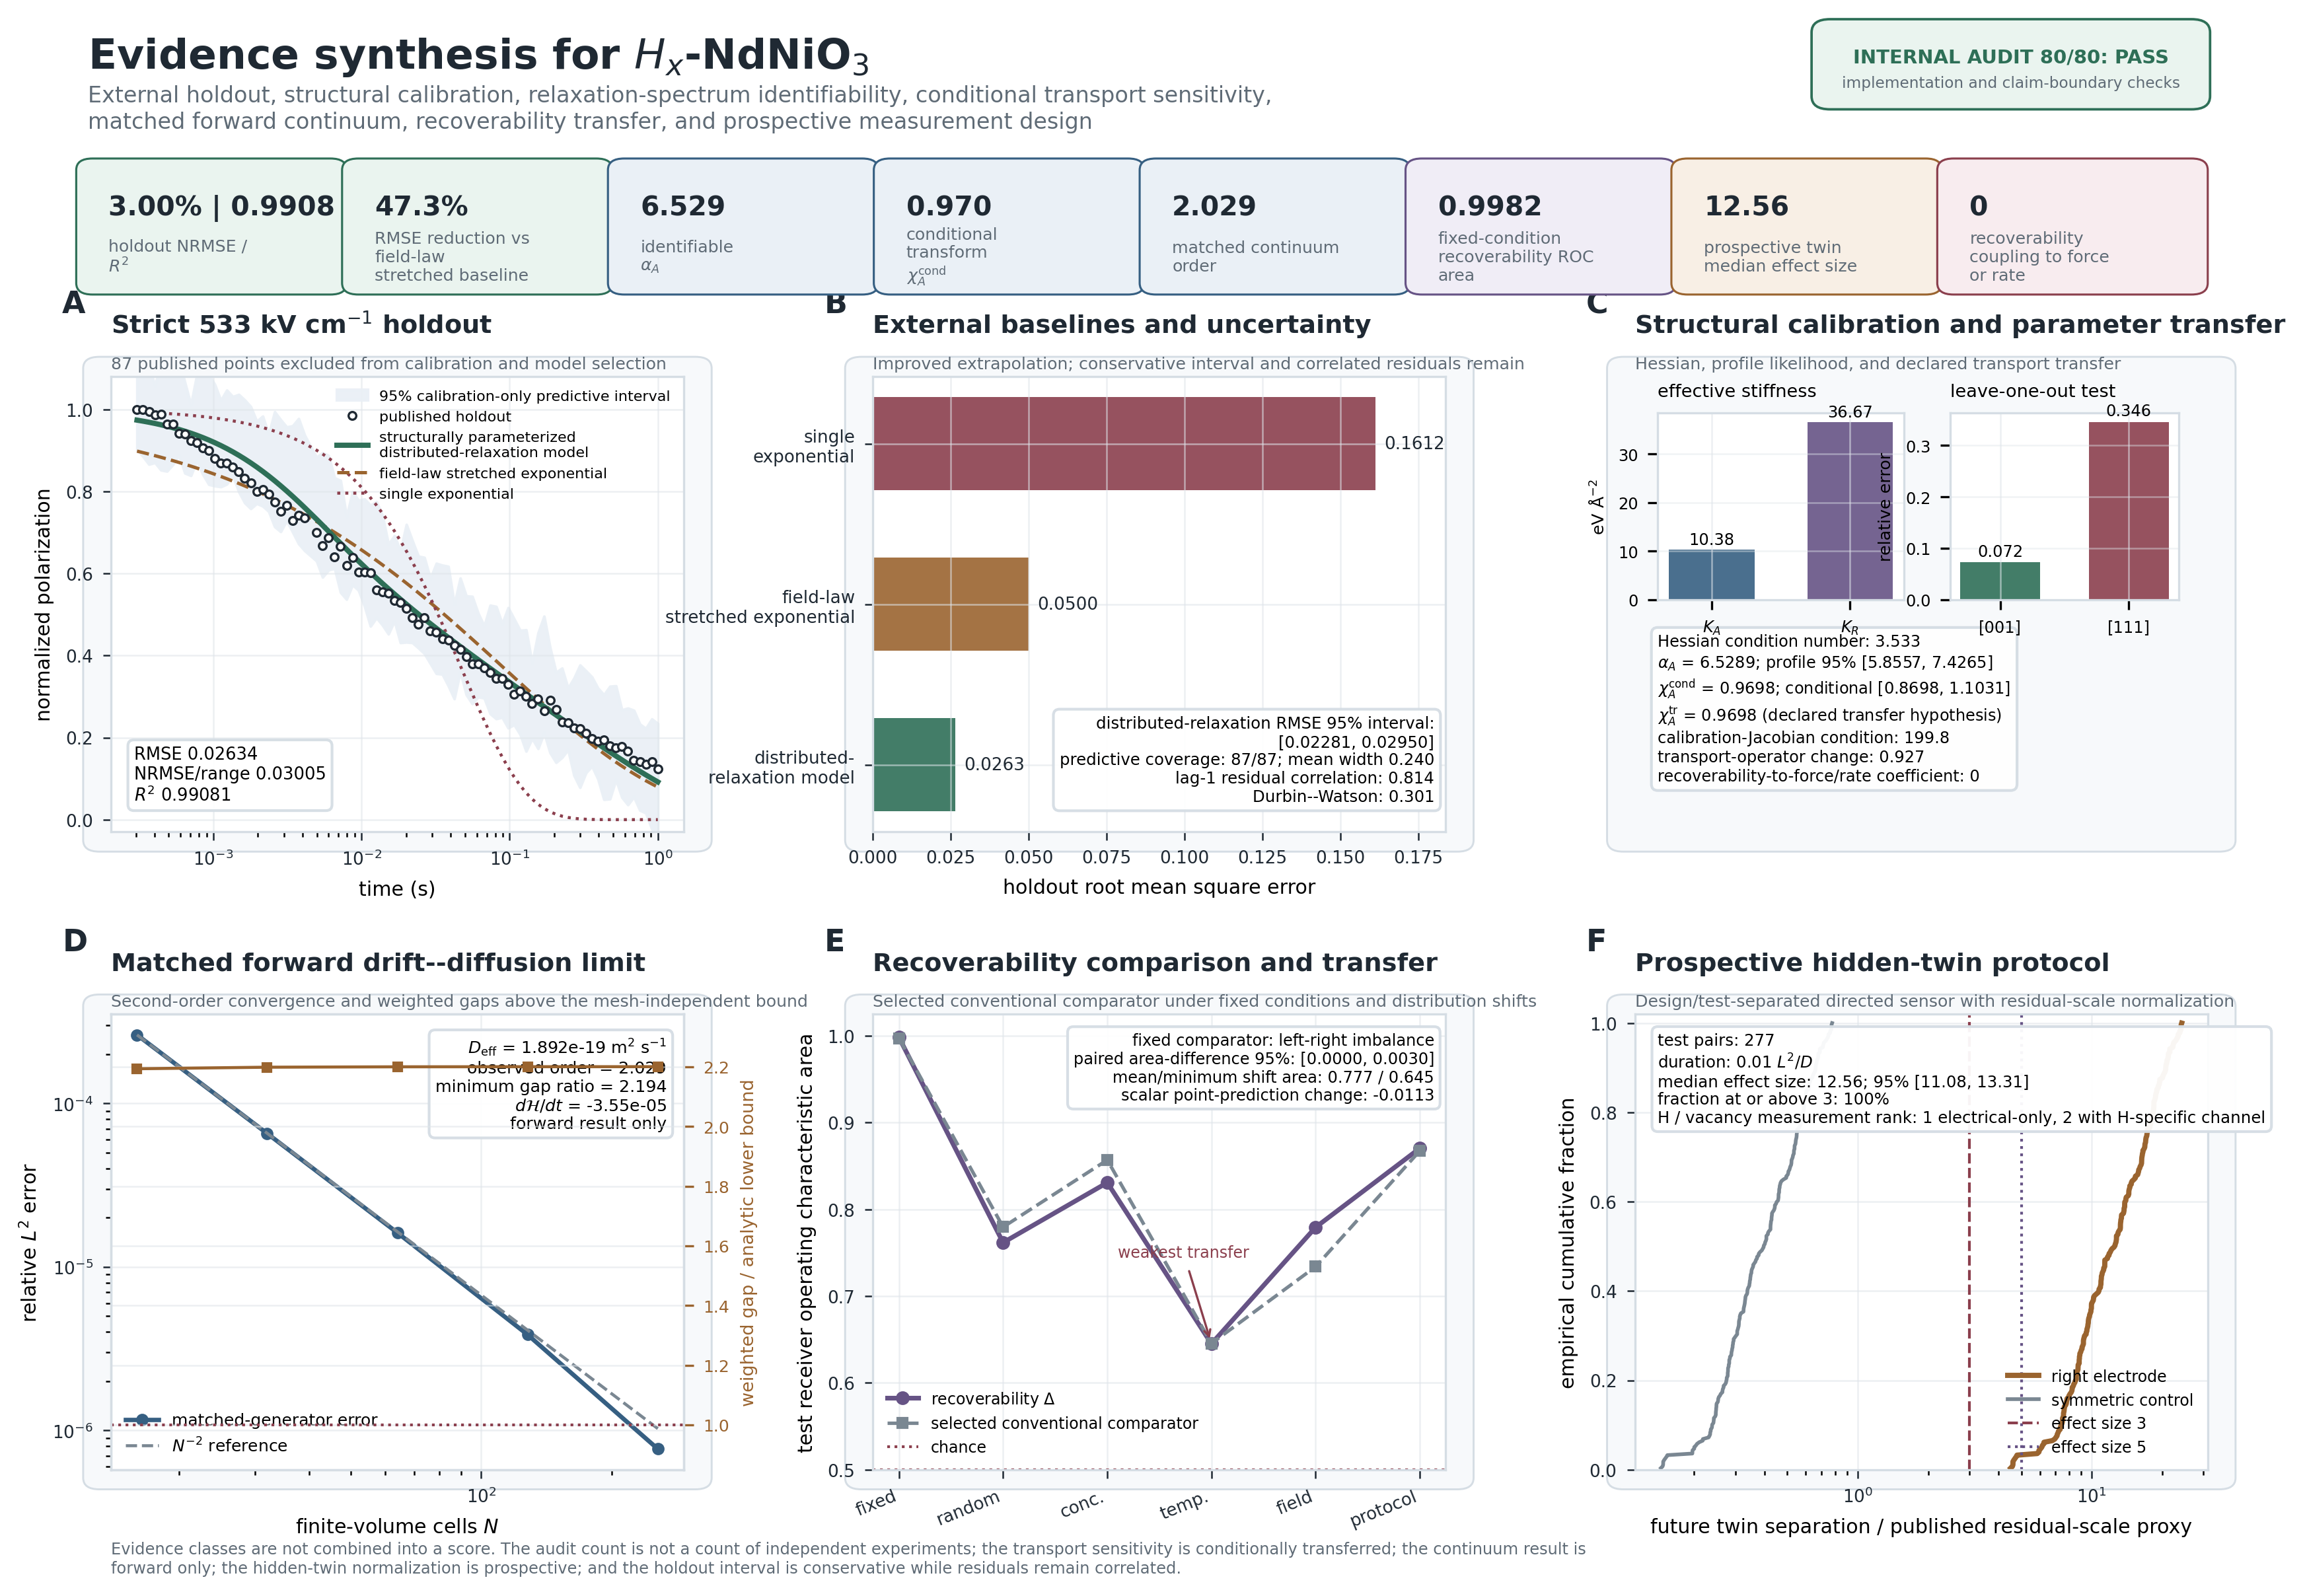

Created one-page vector PDF: /Users/h4/Desktop/OgTRQC_2/Hx_NdNiO3_v31_evidence_summary.pdf


In [4]:
from __future__ import annotations

"""One-cell manuscript visualization for the completed calculation.

Run this cell immediately after the standalone calculation cell. It reads the
already-computed in-memory arrays and tables and creates exactly one one-page,
vector PDF:

    Hx_NdNiO3_v31_evidence_summary.pdf

The filename is retained for compatibility with the manuscript source. The
visible figure contains no internal version marker and uses the revised
identification hierarchy throughout:

    alpha_A                  identifiable relaxation-spectrum slope
    chi_A^cond               conditional transformation at fixed E_A and T_fit
    chi_A^tr = chi_A^cond    declared transport-parameter transfer hypothesis

Legacy in-memory names from the preceding calculation are accepted, but they
are never rendered as the scientific interpretation of the fitted quantity.
The evidence classes are displayed separately and are not combined into a
composite score.
"""

from pathlib import Path
import textwrap
from typing import Sequence

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
from scipy.constants import Boltzmann, elementary_charge

# -----------------------------------------------------------------------------
# Fail early when the preceding calculation has not been executed.
# -----------------------------------------------------------------------------

_REQUIRED = [
    "EXP_TIME_S",
    "HOLDOUT_Y",
    "HOLDOUT_PREDICTIONS",
    "HOLDOUT_PI_LOW",
    "HOLDOUT_PI_HIGH",
    "HOLDOUT_TRAP_METRICS",
    "HOLDOUT_STRETCHED_METRICS",
    "HOLDOUT_SINGLE_METRICS",
    "HOLDOUT_IMPROVEMENT_VS_STRETCHED",
    "HOLDOUT_RMSE_CI",
    "HOLDOUT_PI_COVERAGE",
    "HOLDOUT_PI_MEAN_WIDTH",
    "K_A_EV_A2",
    "K_R0_EV_A2",
    "hess_loo_rmsrel_001",
    "hess_loo_rmsrel_111",
    "hessian_condition",
    "TRAP_FIT",
    "TRAP_JAC_CONDITION",
    "STRUCTURAL_RATE_EFFECT",
    "RECOVERABILITY_TO_FORCE_COUPLING",
    "matched_continuum_table",
    "MATCHED_CONVERGENCE_ORDER",
    "MATCHED_D_EFF",
    "MATCHED_MIN_GAP_RATIO",
    "MATCHED_ENTROPY_DERIVATIVE",
    "FIXED_RECOVERABILITY_AUC",
    "FIXED_BASELINE_AUC",
    "FIXED_AUC_DIFFERENCE_CI",
    "SELECTED_CONVENTIONAL_BASELINE",
    "shift_summary_table",
    "MIN_SHIFT_DELTA_AUC",
    "MEAN_SHIFT_DELTA_AUC",
    "recoverability_incremental_value",
    "TWIN_TEST_SNR",
    "TWIN_SYMMETRIC_SNR",
    "TWIN_MEDIAN_SNR",
    "TWIN_MEDIAN_SNR_CI",
    "TWIN_FRACTION_ABOVE_3",
    "TWIN_SELECTED_SENSOR_NAME",
    "TWIN_SELECTED_DURATION",
    "TWIN_TEST_INDEX",
    "rank_electrical",
    "rank_multimodal",
    "audit",
]

_missing = [name for name in _REQUIRED if name not in globals()]
if _missing:
    raise RuntimeError(
        "Run the complete calculation cell before this visualization cell. "
        "Missing in-memory results: " + ", ".join(_missing)
    )

if "ALPHA_PROFILE_CI" not in globals() and "CHI_PROFILE_CI" not in globals():
    raise RuntimeError(
        "The calculation must provide ALPHA_PROFILE_CI or the legacy "
        "CHI_PROFILE_CI before this visualization is generated."
    )


# -----------------------------------------------------------------------------
# Compatibility helpers: accept the existing calculation namespace while
# rendering only the revised manuscript terminology.
# -----------------------------------------------------------------------------


def _first_scalar(names: Sequence[str], default: float | None = None) -> float:
    for name in names:
        if name in globals():
            value = float(np.asarray(globals()[name], dtype=float).squeeze())
            if np.isfinite(value):
                return value
    if default is not None:
        return float(default)
    raise RuntimeError("Missing required scalar; tried: " + ", ".join(names))


def _first_prediction_key(candidates: Sequence[str]) -> str:
    for candidate in candidates:
        if candidate in HOLDOUT_PREDICTIONS:
            return candidate

    baseline_tokens = ("single", "stretched")
    nonbaseline = [
        key
        for key in HOLDOUT_PREDICTIONS
        if not any(token in key.lower() for token in baseline_tokens)
    ]
    if len(nonbaseline) == 1:
        return nonbaseline[0]

    raise RuntimeError(
        "Could not identify the distributed-relaxation prediction in "
        "HOLDOUT_PREDICTIONS. Available keys: "
        + ", ".join(map(str, HOLDOUT_PREDICTIONS.keys()))
    )


_DISTRIBUTED_PREDICTION_KEY = _first_prediction_key(
    [
        "structurally parameterized distributed-relaxation model",
        "distributed-relaxation model",
        "coupled structural trap master equation",  # accepted as a legacy key only
    ]
)

_E_A_EV = _first_scalar(
    ["E_A_RELAX_EV", "E_A_EV", "EA_RELAX_EV", "EA_EV"]
)
_T_FIT_K = _first_scalar(
    ["TRAP_T_K", "T_FIT_K", "T_FIT", "RELAXATION_FIT_T_K"],
    default=300.0,
)
_KB_EV_K = _first_scalar(
    ["KB_EV_K"],
    default=Boltzmann / elementary_charge,
)
_ALPHA_TO_CHI_SCALE = _E_A_EV / (_KB_EV_K * _T_FIT_K)

if not np.isfinite(_ALPHA_TO_CHI_SCALE) or _ALPHA_TO_CHI_SCALE <= 0.0:
    raise RuntimeError("The E_A/(k_B T_fit) transformation scale is invalid.")

_raw_second_parameter = float(np.asarray(TRAP_FIT.x, dtype=float)[1])
_parameter_name = ""
if "TRAP_PARAM_NAMES" in globals() and len(TRAP_PARAM_NAMES) > 1:
    _parameter_name = str(TRAP_PARAM_NAMES[1]).lower()

# The supplied calculation uses chi_A as the second numerical parameter. This
# branch also supports a later calculation that may fit alpha_A directly.
_parameter_is_alpha = (
    "alpha" in _parameter_name
    or "α" in _parameter_name
    or (
        "chi" not in _parameter_name
        and "χ" not in _parameter_name
        and _raw_second_parameter > 3.0
    )
)

if _parameter_is_alpha:
    ALPHA_A_ESTIMATE = _raw_second_parameter
    CHI_A_COND_ESTIMATE = ALPHA_A_ESTIMATE / _ALPHA_TO_CHI_SCALE
else:
    CHI_A_COND_ESTIMATE = _raw_second_parameter
    ALPHA_A_ESTIMATE = CHI_A_COND_ESTIMATE * _ALPHA_TO_CHI_SCALE

if "ALPHA_PROFILE_CI" in globals():
    ALPHA_A_PROFILE_CI = np.asarray(ALPHA_PROFILE_CI, dtype=float).reshape(2)
    CHI_A_COND_CI = ALPHA_A_PROFILE_CI / _ALPHA_TO_CHI_SCALE
else:
    _legacy_profile_ci = np.asarray(CHI_PROFILE_CI, dtype=float).reshape(2)
    _legacy_contains_raw = bool(
        _legacy_profile_ci[0] <= _raw_second_parameter <= _legacy_profile_ci[1]
    )
    if _parameter_is_alpha and _legacy_contains_raw:
        # A revised calculation may retain the old variable name while profiling alpha_A.
        ALPHA_A_PROFILE_CI = _legacy_profile_ci
        CHI_A_COND_CI = ALPHA_A_PROFILE_CI / _ALPHA_TO_CHI_SCALE
    else:
        # Supplied calculation: CHI_PROFILE_CI is the conditional chi_A interval.
        CHI_A_COND_CI = _legacy_profile_ci
        ALPHA_A_PROFILE_CI = CHI_A_COND_CI * _ALPHA_TO_CHI_SCALE

CHI_A_TR_ESTIMATE = CHI_A_COND_ESTIMATE

for _name, _value in {
    "ALPHA_A_ESTIMATE": ALPHA_A_ESTIMATE,
    "ALPHA_A_PROFILE_CI": ALPHA_A_PROFILE_CI,
    "CHI_A_COND_ESTIMATE": CHI_A_COND_ESTIMATE,
    "CHI_A_COND_CI": CHI_A_COND_CI,
    "CHI_A_TR_ESTIMATE": CHI_A_TR_ESTIMATE,
}.items():
    if not np.all(np.isfinite(np.asarray(_value, dtype=float))):
        raise FloatingPointError(f"{_name} contains NaN or infinity.")

if not (
    ALPHA_A_PROFILE_CI[0] <= ALPHA_A_ESTIMATE <= ALPHA_A_PROFILE_CI[1]
    and CHI_A_COND_CI[0] <= CHI_A_COND_ESTIMATE <= CHI_A_COND_CI[1]
):
    raise RuntimeError(
        "The transformed profile intervals do not contain their point estimates."
    )

if not np.isclose(
    ALPHA_A_ESTIMATE,
    CHI_A_COND_ESTIMATE * _ALPHA_TO_CHI_SCALE,
    rtol=5.0e-10,
    atol=5.0e-12,
):
    raise RuntimeError("The alpha_A to chi_A^cond transformation is inconsistent.")


# -----------------------------------------------------------------------------
# Output and restrained manuscript-oriented visual design.
# -----------------------------------------------------------------------------

OUTPUT_PDF = Path.cwd() / "Hx_NdNiO3_v31_evidence_summary.pdf"
OUTPUT_PDF.unlink(missing_ok=True)

_A4_LANDSCAPE = (11.69, 8.27)
_DPI = 300
_C = {
    "ink": "#1f2933",
    "muted": "#5f6b76",
    "grid": "#dfe5ea",
    "panel": "#f7f9fb",
    "panel_edge": "#d5dde4",
    "green": "#2e6f57",
    "green_light": "#eaf4ef",
    "blue": "#365f82",
    "blue_light": "#eaf0f6",
    "orange": "#9a642f",
    "orange_light": "#f8efe5",
    "red": "#8b3f4d",
    "red_light": "#f8ecef",
    "purple": "#665385",
    "purple_light": "#f0edf6",
    "gray": "#7a8792",
}


def _panel_background(fig: plt.Figure, ax: plt.Axes, pad: float = 0.008) -> None:
    pos = ax.get_position()
    fig.patches.append(
        FancyBboxPatch(
            (pos.x0 - pad, pos.y0 - pad),
            pos.width + 2.0 * pad,
            pos.height + 2.0 * pad,
            transform=fig.transFigure,
            boxstyle="round,pad=0.004,rounding_size=0.007",
            linewidth=0.7,
            edgecolor=_C["panel_edge"],
            facecolor=_C["panel"],
            zorder=-10,
        )
    )


def _style_axis(ax: plt.Axes, title: str, subtitle: str | None = None) -> None:
    ax.set_title(title, loc="left", fontweight="bold", color=_C["ink"], pad=16)
    if subtitle:
        ax.text(
            0.0,
            1.010,
            subtitle,
            transform=ax.transAxes,
            fontsize=6.05,
            color=_C["muted"],
            va="bottom",
        )
    for spine in ax.spines.values():
        spine.set_color(_C["panel_edge"])
    ax.tick_params(colors=_C["ink"], length=3, width=0.6)


def _panel_letter(ax: plt.Axes, letter: str) -> None:
    ax.text(
        -0.085,
        1.14,
        letter,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        color=_C["ink"],
    )


def _metric_cards(fig: plt.Figure, cards: list[tuple[str, str, str]]) -> None:
    left, right, gap = 0.045, 0.045, 0.008
    y, height = 0.805, 0.073
    width = (1.0 - left - right - gap * (len(cards) - 1)) / len(cards)

    for index, (value, label, tone) in enumerate(cards):
        x = left + index * (width + gap)
        fig.patches.append(
            FancyBboxPatch(
                (x, y),
                width,
                height,
                transform=fig.transFigure,
                boxstyle="round,pad=0.005,rounding_size=0.007",
                linewidth=0.75,
                edgecolor=_C.get(tone, _C["panel_edge"]),
                facecolor=_C.get(f"{tone}_light", "white"),
            )
        )
        fig.text(
            x + 0.009,
            y + 0.048,
            value,
            fontsize=9.8,
            fontweight="bold",
            color=_C["ink"],
            va="center",
        )
        fig.text(
            x + 0.009,
            y + 0.018,
            "\n".join(
                textwrap.fill(
                    part,
                    18,
                    break_long_words=False,
                    break_on_hyphens=False,
                )
                for part in label.splitlines()
            ),
            fontsize=6.05,
            color=_C["muted"],
            va="center",
        )


def _ecdf(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    values = np.sort(np.asarray(values, dtype=float))
    return values, np.arange(1, len(values) + 1, dtype=float) / len(values)


_rc = {
    "font.family": "DejaVu Sans",
    "font.size": 7.7,
    "axes.titlesize": 9.2,
    "axes.labelsize": 7.2,
    "xtick.labelsize": 6.3,
    "ytick.labelsize": 6.3,
    "axes.edgecolor": _C["panel_edge"],
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": _C["grid"],
    "grid.alpha": 0.58,
    "grid.linewidth": 0.6,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "text.usetex": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

with plt.rc_context(_rc):
    fig = plt.figure(figsize=_A4_LANDSCAPE, dpi=_DPI)

    # Header and implementation-audit badge. No visible internal version marker.
    fig.text(
        0.045,
        0.958,
        r"Evidence synthesis for $H_x$-NdNiO$_3$",
        fontsize=15.2,
        fontweight="bold",
        color=_C["ink"],
        va="top",
    )
    fig.text(
        0.045,
        0.928,
        "External holdout, structural calibration, relaxation-spectrum identifiability, "
        "conditional transport sensitivity,\nmatched forward continuum, recoverability "
        "transfer, and prospective measurement design",
        fontsize=8.0,
        color=_C["muted"],
        va="top",
        linespacing=1.25,
    )

    audit_passed = int(audit["pass"].sum())
    audit_total = int(len(audit))
    audit_status = "PASS" if audit_passed == audit_total else "CHECK"
    fig.patches.append(
        FancyBboxPatch(
            (0.795, 0.919),
            0.160,
            0.043,
            transform=fig.transFigure,
            boxstyle="round,pad=0.006,rounding_size=0.008",
            linewidth=0.9,
            edgecolor=_C["green"] if audit_status == "PASS" else _C["red"],
            facecolor=_C["green_light"] if audit_status == "PASS" else _C["red_light"],
        )
    )
    fig.text(
        0.875,
        0.945,
        f"INTERNAL AUDIT {audit_passed}/{audit_total}: {audit_status}",
        ha="center",
        va="center",
        fontsize=7.0,
        fontweight="bold",
        color=_C["green"] if audit_status == "PASS" else _C["red"],
    )
    fig.text(
        0.875,
        0.929,
        "implementation and claim-boundary checks",
        ha="center",
        va="center",
        fontsize=5.6,
        color=_C["muted"],
    )

    cards = [
        (
            f"{100.0 * HOLDOUT_TRAP_METRICS['NRMSE/range']:.2f}% | "
            f"{HOLDOUT_TRAP_METRICS['R2']:.4f}",
            r"holdout NRMSE / $R^2$",
            "green",
        ),
        (
            f"{100.0 * HOLDOUT_IMPROVEMENT_VS_STRETCHED:.1f}%",
            "RMSE reduction vs field-law stretched baseline",
            "green",
        ),
        (
            f"{ALPHA_A_ESTIMATE:.3f}",
            "identifiable\n" + r"$\alpha_A$",
            "blue",
        ),
        (
            f"{CHI_A_COND_ESTIMATE:.3f}",
            "conditional transform\n" + r"$\chi_A^{\mathrm{cond}}$",
            "blue",
        ),
        (
            f"{MATCHED_CONVERGENCE_ORDER:.3f}",
            "matched continuum order",
            "blue",
        ),
        (
            f"{FIXED_RECOVERABILITY_AUC:.4f}",
            "fixed-condition recoverability ROC area",
            "purple",
        ),
        (
            f"{TWIN_MEDIAN_SNR:.2f}",
            "prospective twin median effect size",
            "orange",
        ),
        (
            f"{RECOVERABILITY_TO_FORCE_COUPLING:.0f}",
            "recoverability coupling to force or rate",
            "red",
        ),
    ]
    _metric_cards(fig, cards)

    gs = fig.add_gridspec(
        2,
        3,
        left=0.055,
        right=0.960,
        bottom=0.083,
        top=0.750,
        wspace=0.33,
        hspace=0.40,
    )

    # ------------------------------------------------------------------ A ---
    ax = fig.add_subplot(gs[0, 0])
    _panel_background(fig, ax)
    _style_axis(
        ax,
        "Strict 533 kV cm$^{-1}$ holdout",
        "87 published points excluded from calibration and model selection",
    )
    _panel_letter(ax, "A")
    ax.fill_between(
        EXP_TIME_S,
        HOLDOUT_PI_LOW,
        HOLDOUT_PI_HIGH,
        color=_C["blue_light"],
        alpha=0.95,
        label="95% calibration-only predictive interval",
        zorder=1,
    )
    ax.semilogx(
        EXP_TIME_S,
        HOLDOUT_Y,
        "o",
        markersize=2.8,
        markerfacecolor="white",
        markeredgewidth=0.8,
        color=_C["ink"],
        label="published holdout",
        zorder=5,
    )
    ax.semilogx(
        EXP_TIME_S,
        HOLDOUT_PREDICTIONS[_DISTRIBUTED_PREDICTION_KEY],
        linewidth=1.9,
        color=_C["green"],
        label="structurally parameterized\ndistributed-relaxation model",
        zorder=4,
    )
    ax.semilogx(
        EXP_TIME_S,
        HOLDOUT_PREDICTIONS["field-law stretched exponential"],
        linewidth=1.2,
        linestyle="--",
        color=_C["orange"],
        label="field-law stretched exponential",
    )
    ax.semilogx(
        EXP_TIME_S,
        HOLDOUT_PREDICTIONS["single exponential"],
        linewidth=1.1,
        linestyle=":",
        color=_C["red"],
        label="single exponential",
    )
    ax.set_xlabel("time (s)")
    ax.set_ylabel("normalized polarization")
    ax.set_ylim(-0.03, 1.08)
    ax.legend(loc="upper right", frameon=False, fontsize=5.35, handlelength=2.1)
    ax.text(
        0.04,
        0.06,
        f"RMSE {HOLDOUT_TRAP_METRICS['RMSE']:.5f}\n"
        f"NRMSE/range {HOLDOUT_TRAP_METRICS['NRMSE/range']:.5f}\n"
        f"$R^2$ {HOLDOUT_TRAP_METRICS['R2']:.5f}",
        transform=ax.transAxes,
        fontsize=6.2,
        va="bottom",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor=_C["panel_edge"],
            alpha=0.94,
        ),
    )

    # ------------------------------------------------------------------ B ---
    ax = fig.add_subplot(gs[0, 1])
    _panel_background(fig, ax)
    _style_axis(
        ax,
        "External baselines and uncertainty",
        "Improved extrapolation; conservative interval and correlated residuals remain",
    )
    _panel_letter(ax, "B")
    model_labels = [
        "single\nexponential",
        "field-law\nstretched exponential",
        "distributed-\nrelaxation model",
    ]
    model_rmse = np.array(
        [
            HOLDOUT_SINGLE_METRICS["RMSE"],
            HOLDOUT_STRETCHED_METRICS["RMSE"],
            HOLDOUT_TRAP_METRICS["RMSE"],
        ],
        dtype=float,
    )
    model_colors = [_C["red"], _C["orange"], _C["green"]]
    ypos = np.arange(3)
    ax.barh(ypos, model_rmse, color=model_colors, alpha=0.90, height=0.58)
    ax.set_yticks(ypos, model_labels)
    ax.invert_yaxis()
    ax.set_xlabel("holdout root mean square error")
    ax.set_xlim(0.0, max(model_rmse) * 1.14)
    value_offset = max(model_rmse) * 0.018
    for y_i, value in zip(ypos, model_rmse):
        ax.text(
            value + value_offset,
            y_i,
            f"{value:.4f}",
            va="center",
            fontsize=6.3,
            color=_C["ink"],
        )

    holdout_count = int(len(np.asarray(HOLDOUT_Y)))
    covered_count = int(round(holdout_count * float(HOLDOUT_PI_COVERAGE)))
    ax.text(
        0.98,
        0.06,
        f"distributed-relaxation RMSE 95% interval:\n"
        f"[{HOLDOUT_RMSE_CI[0]:.5f}, {HOLDOUT_RMSE_CI[1]:.5f}]\n"
        f"predictive coverage: {covered_count}/{holdout_count}; "
        f"mean width {HOLDOUT_PI_MEAN_WIDTH:.3f}\n"
        f"lag-1 residual correlation: "
        f"{HOLDOUT_TRAP_METRICS['lag-1 residual correlation']:.3f}\n"
        f"Durbin--Watson: {HOLDOUT_TRAP_METRICS['Durbin-Watson']:.3f}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=5.85,
        bbox=dict(
            boxstyle="round,pad=0.38",
            facecolor="white",
            edgecolor=_C["panel_edge"],
            alpha=0.95,
        ),
    )

    # ------------------------------------------------------------------ C ---
    ax = fig.add_subplot(gs[0, 2])
    _panel_background(fig, ax)
    _style_axis(
        ax,
        "Structural calibration and parameter transfer",
        "Hessian, profile likelihood, and declared transport transfer",
    )
    _panel_letter(ax, "C")
    ax.set_axis_off()

    stiffness_ax = ax.inset_axes([0.04, 0.51, 0.43, 0.41])
    stiffness_ax.bar(
        [0, 1],
        [K_A_EV_A2, K_R0_EV_A2],
        width=0.62,
        color=[_C["blue"], _C["purple"]],
        alpha=0.90,
    )
    stiffness_ax.set_xticks([0, 1], [r"$K_A$", r"$K_R$"])
    stiffness_ax.set_ylabel(r"eV $\mathrm{\AA}^{-2}$", fontsize=6.1)
    stiffness_ax.set_title("effective stiffness", fontsize=6.5, loc="left")
    stiffness_ax.grid(axis="y", alpha=0.45)
    stiffness_ax.tick_params(labelsize=5.8)
    for index, value in enumerate([K_A_EV_A2, K_R0_EV_A2]):
        stiffness_ax.text(index, value + 1.0, f"{value:.2f}", ha="center", fontsize=5.8)

    loo_ax = ax.inset_axes([0.55, 0.51, 0.40, 0.41])
    loo_ax.bar(
        [0, 1],
        [hess_loo_rmsrel_001, hess_loo_rmsrel_111],
        width=0.62,
        color=[_C["green"], _C["red"]],
        alpha=0.90,
    )
    loo_ax.set_xticks([0, 1], ["[001]", "[111]"])
    loo_ax.set_ylabel("relative error", fontsize=6.1)
    loo_ax.set_title("leave-one-out test", fontsize=6.5, loc="left")
    loo_ax.grid(axis="y", alpha=0.45)
    loo_ax.tick_params(labelsize=5.8)
    for index, value in enumerate([hess_loo_rmsrel_001, hess_loo_rmsrel_111]):
        loo_ax.text(index, value + 0.012, f"{value:.3f}", ha="center", fontsize=5.8)

    ax.text(
        0.04,
        0.435,
        f"Hessian condition number: {hessian_condition:.3f}\n"
        f"$\\alpha_A$ = {ALPHA_A_ESTIMATE:.4f}; profile 95% "
        f"[{ALPHA_A_PROFILE_CI[0]:.4f}, {ALPHA_A_PROFILE_CI[1]:.4f}]\n"
        f"$\\chi_A^{{\\mathrm{{cond}}}}$ = {CHI_A_COND_ESTIMATE:.4f}; conditional "
        f"[{CHI_A_COND_CI[0]:.4f}, {CHI_A_COND_CI[1]:.4f}]\n"
        f"$\\chi_A^{{\\mathrm{{tr}}}}$ = {CHI_A_TR_ESTIMATE:.4f} "
        f"(declared transfer hypothesis)\n"
        f"calibration-Jacobian condition: {TRAP_JAC_CONDITION:.1f}\n"
        f"transport-operator change: {STRUCTURAL_RATE_EFFECT:.3f}\n"
        f"recoverability-to-force/rate coefficient: "
        f"{RECOVERABILITY_TO_FORCE_COUPLING:.0f}",
        transform=ax.transAxes,
        va="top",
        fontsize=5.78,
        linespacing=1.27,
        bbox=dict(
            boxstyle="round,pad=0.40",
            facecolor="white",
            edgecolor=_C["panel_edge"],
            alpha=0.97,
        ),
    )

    # ------------------------------------------------------------------ D ---
    ax = fig.add_subplot(gs[1, 0])
    _panel_background(fig, ax)
    _style_axis(
        ax,
        "Matched forward drift--diffusion limit",
        "Second-order convergence and weighted gaps above the mesh-independent bound",
    )
    _panel_letter(ax, "D")
    continuum_n = matched_continuum_table["N"].to_numpy(dtype=float)
    continuum_error = matched_continuum_table[
        "relative L2 error vs N=512"
    ].to_numpy(dtype=float)
    gap_ratio = matched_continuum_table[
        "gap/analytic lower bound"
    ].to_numpy(dtype=float)
    second_order_reference = continuum_error[0] * (continuum_n[0] / continuum_n) ** 2

    ax.loglog(
        continuum_n,
        continuum_error,
        "o-",
        linewidth=1.6,
        markersize=3.5,
        color=_C["blue"],
        label="matched-generator error",
    )
    ax.loglog(
        continuum_n,
        second_order_reference,
        "--",
        linewidth=1.1,
        color=_C["gray"],
        label=r"$N^{-2}$ reference",
    )
    ax.set_xlabel("finite-volume cells $N$")
    ax.set_ylabel("relative $L^2$ error")
    ax.legend(frameon=False, fontsize=6.0, loc="lower left")

    gap_ax = ax.twinx()
    gap_ax.plot(
        continuum_n,
        gap_ratio,
        "s-",
        linewidth=1.1,
        markersize=3.0,
        color=_C["orange"],
        label="gap / analytic lower bound",
    )
    gap_ax.axhline(1.0, linestyle=":", linewidth=1.0, color=_C["red"])
    gap_ax.set_ylabel(
        "weighted gap / analytic lower bound",
        color=_C["orange"],
        fontsize=6.5,
    )
    gap_ax.tick_params(axis="y", colors=_C["orange"], labelsize=6.0)
    gap_ax.set_ylim(0.85, max(2.35, gap_ratio.max() * 1.08))

    ax.text(
        0.97,
        0.95,
        f"$D_{{\\mathrm{{eff}}}}$ = {MATCHED_D_EFF:.3e} m$^2$ s$^{{-1}}$\n"
        f"observed order = {MATCHED_CONVERGENCE_ORDER:.3f}\n"
        f"minimum gap ratio = {MATCHED_MIN_GAP_RATIO:.3f}\n"
        f"$d\\mathcal{{H}}/dt$ = {MATCHED_ENTROPY_DERIVATIVE:.2e}\n"
        "forward result only",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=6.05,
        bbox=dict(
            boxstyle="round,pad=0.36",
            facecolor="white",
            edgecolor=_C["panel_edge"],
            alpha=0.95,
        ),
    )

    # ------------------------------------------------------------------ E ---
    ax = fig.add_subplot(gs[1, 1])
    _panel_background(fig, ax)
    _style_axis(
        ax,
        "Recoverability comparison and transfer",
        "Selected conventional comparator under fixed conditions and distribution shifts",
    )
    _panel_letter(ax, "E")
    shift_order = [
        "random",
        "concentration holdout x_H=0.50",
        "temperature holdout 350 K",
        "field holdout 3e5 V/m",
        "protocol holdout mixed",
    ]
    shift_rows = shift_summary_table.set_index("split").loc[shift_order]
    x_labels = ["fixed", "random", "conc.", "temp.", "field", "protocol"]
    recoverability_area = np.r_[
        FIXED_RECOVERABILITY_AUC,
        shift_rows["Δ ROC-AUC"].to_numpy(dtype=float),
    ]
    comparator_area = np.r_[
        FIXED_BASELINE_AUC,
        shift_rows["baseline ROC-AUC"].to_numpy(dtype=float),
    ]
    x_positions = np.arange(len(x_labels))

    ax.plot(
        x_positions,
        recoverability_area,
        "o-",
        linewidth=1.7,
        markersize=4.0,
        color=_C["purple"],
        label=r"recoverability $\Delta$",
    )
    ax.plot(
        x_positions,
        comparator_area,
        "s--",
        linewidth=1.25,
        markersize=3.4,
        color=_C["gray"],
        label="selected conventional comparator",
    )
    ax.axhline(0.5, linestyle=":", linewidth=1.0, color=_C["red"], label="chance")
    ax.set_xticks(x_positions, x_labels, rotation=22, ha="right")
    ax.set_ylabel("test receiver operating characteristic area")
    ax.set_ylim(0.50, 1.025)
    ax.legend(frameon=False, fontsize=5.7, loc="lower left")

    weakest_index = int(np.argmin(recoverability_area[1:])) + 1
    ax.annotate(
        "weakest transfer",
        xy=(weakest_index, recoverability_area[weakest_index]),
        xytext=(weakest_index - 0.9, recoverability_area[weakest_index] + 0.10),
        fontsize=5.7,
        color=_C["red"],
        arrowprops=dict(arrowstyle="->", color=_C["red"], linewidth=0.8),
    )
    ax.text(
        0.98,
        0.96,
        f"fixed comparator: {SELECTED_CONVENTIONAL_BASELINE}\n"
        f"paired area-difference 95%: "
        f"[{FIXED_AUC_DIFFERENCE_CI[0]:.4f}, {FIXED_AUC_DIFFERENCE_CI[1]:.4f}]\n"
        f"mean/minimum shift area: "
        f"{MEAN_SHIFT_DELTA_AUC:.3f} / {MIN_SHIFT_DELTA_AUC:.3f}\n"
        f"scalar point-prediction change: "
        f"{recoverability_incremental_value:.4f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=5.75,
        bbox=dict(
            boxstyle="round,pad=0.36",
            facecolor="white",
            edgecolor=_C["panel_edge"],
            alpha=0.95,
        ),
    )

    # ------------------------------------------------------------------ F ---
    ax = fig.add_subplot(gs[1, 2])
    _panel_background(fig, ax)
    _style_axis(
        ax,
        "Prospective hidden-twin protocol",
        "Design/test-separated directed sensor with residual-scale normalization",
    )
    _panel_letter(ax, "F")
    selected_x, selected_y = _ecdf(
        np.clip(np.asarray(TWIN_TEST_SNR, dtype=float), 1.0e-3, None)
    )
    control_x, control_y = _ecdf(
        np.clip(np.asarray(TWIN_SYMMETRIC_SNR, dtype=float), 1.0e-3, None)
    )
    ax.semilogx(
        selected_x,
        selected_y,
        linewidth=1.9,
        color=_C["orange"],
        label=TWIN_SELECTED_SENSOR_NAME,
    )
    ax.semilogx(
        control_x,
        control_y,
        linewidth=1.35,
        color=_C["gray"],
        label="symmetric control",
    )
    ax.axvline(3.0, linestyle="--", linewidth=1.0, color=_C["red"], label="effect size 3")
    ax.axvline(5.0, linestyle=":", linewidth=1.0, color=_C["purple"], label="effect size 5")
    ax.set_xlabel("future twin separation / published residual-scale proxy")
    ax.set_ylabel("empirical cumulative fraction")
    ax.set_ylim(0.0, 1.02)
    ax.legend(frameon=False, fontsize=5.7, loc="lower right")
    ax.text(
        0.04,
        0.96,
        f"test pairs: {len(TWIN_TEST_INDEX)}\n"
        f"duration: {TWIN_SELECTED_DURATION:.2f} $L^2/D$\n"
        f"median effect size: {TWIN_MEDIAN_SNR:.2f}; 95% "
        f"[{TWIN_MEDIAN_SNR_CI[0]:.2f}, {TWIN_MEDIAN_SNR_CI[1]:.2f}]\n"
        f"fraction at or above 3: {100.0 * TWIN_FRACTION_ABOVE_3:.0f}%\n"
        f"H / vacancy measurement rank: "
        f"{rank_electrical} electrical-only, {rank_multimodal} with H-specific channel",
        transform=ax.transAxes,
        va="top",
        fontsize=5.85,
        bbox=dict(
            boxstyle="round,pad=0.36",
            facecolor="white",
            edgecolor=_C["panel_edge"],
            alpha=0.95,
        ),
    )

    footer_text = (
        "Evidence classes are not combined into a score. The audit count is not a count "
        "of independent experiments; the transport sensitivity is conditionally transferred; "
        "the continuum result is forward only; the hidden-twin normalization is prospective; "
        "and the holdout interval is conservative while residuals remain correlated."
    )
    fig.text(
        0.055,
        0.018,
        textwrap.fill(footer_text, width=188),
        fontsize=5.8,
        color=_C["muted"],
        va="bottom",
        linespacing=1.25,
    )

    fig.savefig(
        OUTPUT_PDF,
        format="pdf",
        dpi=_DPI,
        metadata={
            "Title": "Evidence synthesis for Hx-NdNiO3 reduced models",
            "Subject": (
                "External holdout, structural calibration, relaxation-spectrum "
                "identifiability, conditional transport sensitivity, matched forward "
                "continuum, recoverability transfer, and hidden-twin measurement design"
            ),
            "Keywords": (
                "Hx-NdNiO3; proton transport; distributed relaxation; alpha_A; "
                "conditional transport sensitivity; external holdout; continuum; "
                "recoverability; hidden twins"
            ),
        },
    )
    plt.show()

if not OUTPUT_PDF.is_file() or OUTPUT_PDF.stat().st_size == 0:
    raise RuntimeError(f"The visualization PDF was not created: {OUTPUT_PDF}")

print(f"Created one-page vector PDF: {OUTPUT_PDF.resolve()}")